# Install Dependencies

In [1]:
# Configure display options to show ALL rows and columns
import numpy as np
from astropy.table import Table
import pandas as pd
from IPython.display import display, HTML

# For Astropy Tables
Table.pprint_max_lines = None  # Show all rows
Table.pprint_max_width = -1    # Show all columns without line breaks

# For pandas DataFrames
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.width', None)        # Auto-detect the display width
pd.set_option('display.max_colwidth', None) # Show full content of each column

# For Jupyter display
display(HTML("<style>.output { flex-direction: column; }</style>"))

In [2]:
!pip install fitsio


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np


from astropy.io import fits
from astropy.table import Table, vstack, join
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.coordinates import SkyCoord

import matplotlib
import matplotlib.pyplot as plt
#-- input/output functions related to DESI spectra
#import desispec.io
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

In [4]:
!pip install astropy numpy matplotlib requests
!pip install SparclClient
from sparcl.client import SparclClient
import numpy as np
import tempfile
import os
import json
import astropy
import sncosmo
!pip install numpy scipy matplotlib
!pip install sncosmo


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Emergency Spectra Upload

In [9]:
import pandas as pd

def get_redshift_by_id(csv_path, target_id):
    """
    Reads the 'Z' value from a CSV for a specific 'ID'.
    """
    try:
        # Load the CSV
        df = pd.read_csv(csv_path)

        # Filter the row where 'ID' matches
        # .astype(str) ensures matching works even if IDs are mixed types (int/string)
        row = df[df['ID'].astype(str) == str(target_id)]

        if row.empty:
            return f"Error: ID {target_id} not found."

        # Return the 'Z' value
        return row['Z_ID'].values[0]

    except Exception as e:
        return f"Error reading CSV: {e}"

# Example usage:
z_value = get_redshift_by_id('/Users/neelviswanathan/Downloads/SNe for Z_Redshift .csv', spectrumID)
print(z_value)
redshift = z_value

0.0908563660964148


In [10]:
from astropy.io import ascii

# Read only the first 1000 lines of a CSV
SNePrediction = Table.read('/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/spatial_matches_D1F.csv')

In [11]:
w=np.in1d(SNePrediction["TARGETID"],spectrumID)
w

array([False, False, False, False, False,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [12]:
only_SN=SNePrediction[w]
only_SN

TARGETID,PETAL_LOC,TILEID,SURVEY,NIGHT,PROGRAM,SNE_NAME,OBS_DATE_UTC,DISC_DATE_UTC,DAYS_DIFF,SEP_ARCSEC
int64,int64,int64,str3,int64,str6,str11,str26,str26,float64,float64
39628438574727938,4,80664,sv1,20210208,bright,AT 2021cpa,2021-02-09 12:07:07.106304,2021-02-06 14:09:36,2.9149433599999997,0.7114504273367496
39628438574727938,4,80664,sv1,20210208,bright,AT 2021cpa,2021-02-09 12:15:18.945216,2021-02-06 14:09:36,2.92063594,0.9035986447446656


In [13]:
object = only_SN['TARGETID' == spectrumID]

PETALLOC = object["PETAL_LOC"]
TILE = object["TILEID"]
NIGHT = object["NIGHT"]
SURVEY = object["SURVEY"]
PROG = object["PROGRAM"]

In [14]:
# Install required packages
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

packages = ["requests", "pandas", "numpy", "astropy", "matplotlib"]
for package in packages:
    try:
        __import__(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        install_package(package)
        print(f"✅ {package} installed")

✅ requests already installed
✅ pandas already installed
✅ numpy already installed
✅ astropy already installed
✅ matplotlib already installed


In [15]:
# Download the DESI spectra notebook functions
import requests
import os

# Create the desi_spectra_notebook.py file with updated functions
notebook_code = '''#!/usr/bin/env python3
"""
DESI Spectra Notebook Helper - Updated with Easy Access
=====================================================

Simple functions for retrieving DESI spectra in Jupyter notebooks.
Just call get_desi_spectrum() with your target parameters.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import requests
from pathlib import Path
import time
from typing import Dict, Optional, Tuple
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

class DESISpectraNotebook:
    """Simple class for retrieving DESI spectra in notebooks."""

    def __init__(self, base_url: str = "https://data.desi.lbl.gov/public/dr1/"):
        """Initialize the DESI spectra retriever."""
        self.base_url = base_url
        self.session = requests.Session()
        self.session.headers.update({'User-Agent': 'DESI-Spectra-Retriever/1.0'})
        self.last_request_time = 0
        self.min_request_interval = 0.5

    def _rate_limit(self):
        """Implement rate limiting."""
        current_time = time.time()
        time_since_last = current_time - self.last_request_time
        if time_since_last < self.min_request_interval:
            time.sleep(self.min_request_interval - time_since_last)
        self.last_request_time = time.time()

    def _construct_url(self, tileid: int, night: int, petal_loc: int) -> str:
        """Construct URL for DESI coadd file."""
        filename = f"coadd-{petal_loc}-{tileid}-{night}.fits"
        url_path = f"spectro/redux/iron/tiles/pernight/{tileid}/{night}/{filename}"
        return f"{self.base_url}{url_path}"

    def get_spectrum(self, targetid: int, tileid: int, night: int, petal_loc: int,
                    output_dir: str = "spectra", save_file: bool = True) -> Dict:
        """
        Get a DESI spectrum for a specific target.

        Parameters:
        -----------
        targetid : int
            Target identifier
        tileid : int
            Tile identifier
        night : int
            Observation night (YYYYMMDD format)
        petal_loc : int
            Petal location (0-9)
        output_dir : str
            Directory to save spectrum file
        save_file : bool
            Whether to save the FITS file to disk

        Returns:
        --------
        dict : Dictionary containing spectrum data and metadata
        """
        print(f"🔍 Retrieving spectrum for TARGETID: {targetid}")
        print(f"   Tile: {tileid}, Night: {night}, Petal: {petal_loc}")

        # Construct URL
        url = self._construct_url(tileid, night, petal_loc)
        print(f"   URL: {url}")

        # Rate limiting
        self._rate_limit()

        try:
            # Download the file
            response = self.session.get(url, timeout=60)

            if response.status_code == 200:
                print("✅ File downloaded successfully")

                # Save file if requested
                if save_file:
                    output_path = Path(output_dir)
                    output_path.mkdir(exist_ok=True)
                    filename = f"spectrum_{targetid}.fits"
                    filepath = output_path / filename

                    with open(filepath, 'wb') as f:
                        f.write(response.content)
                    print(f"💾 Saved to: {filepath}")
                else:
                    filepath = None

                # Load spectrum data
                spectrum_data = self._load_spectrum_from_bytes(response.content, targetid)
                spectrum_data['filepath'] = filepath

                return spectrum_data

            else:
                print(f"❌ HTTP {response.status_code} error")
                return None

        except Exception as e:
            print(f"❌ Error: {e}")
            return None

    def _load_spectrum_from_bytes(self, content: bytes, targetid: int) -> Dict:
        """Load spectrum data from FITS file content."""
        import io

        # Create FITS file from bytes
        fits_file = io.BytesIO(content)

        with fits.open(fits_file) as hdul:
            # Get fibermap
            fibermap = hdul[1].data

            # Find target
            target_mask = fibermap['TARGETID'] == targetid
            if not np.any(target_mask):
                print(f"⚠️  Target {targetid} not found in this coadd file")
                print(f"   Available TARGETIDs: {np.unique(fibermap['TARGETID'])[:5]}...")
                return None

            fiber_idx = np.where(target_mask)[0][0]
            print(f"🎯 Found target at fiber index {fiber_idx}")

            # Extract spectra for each camera
            spectra = {}

            # Blue camera (B)
            if len(hdul) > 4:
                b_wave = hdul[3].data
                b_flux = hdul[4].data[fiber_idx]
                b_ivar = hdul[5].data[fiber_idx]
                b_mask = hdul[6].data[fiber_idx]
                spectra['B'] = {
                    'wavelength': b_wave,
                    'flux': b_flux,
                    'ivar': b_ivar,
                    'mask': b_mask
                }

            # Red camera (R)
            if len(hdul) > 9:
                r_wave = hdul[8].data
                r_flux = hdul[9].data[fiber_idx]
                r_ivar = hdul[10].data[fiber_idx]
                r_mask = hdul[11].data[fiber_idx]
                spectra['R'] = {
                    'wavelength': r_wave,
                    'flux': r_flux,
                    'ivar': r_ivar,
                    'mask': r_mask
                }

            # Near-infrared camera (Z)
            if len(hdul) > 14:
                z_wave = hdul[13].data
                z_flux = hdul[14].data[fiber_idx]
                z_ivar = hdul[15].data[fiber_idx]
                z_mask = hdul[16].data[fiber_idx]
                spectra['Z'] = {
                    'wavelength': z_wave,
                    'flux': z_flux,
                    'ivar': z_ivar,
                    'mask': z_mask
                }

            # Calculate redshift if available
            redshift = None
            if 'Z' in fibermap.dtype.names:
                redshift = fibermap['Z'][fiber_idx]
            elif 'REDSHIFT' in fibermap.dtype.names:
                redshift = fibermap['REDSHIFT'][fiber_idx]

            # Create combined wavelength and flux arrays
            all_wavelengths = []
            all_fluxes = []
            all_ivars = []
            all_masks = []

            for camera in ['B', 'R', 'Z']:
                if camera in spectra:
                    all_wavelengths.extend(spectra[camera]['wavelength'])
                    all_fluxes.extend(spectra[camera]['flux'])
                    all_ivars.extend(spectra[camera]['ivar'])
                    all_masks.extend(spectra[camera]['mask'])

            # Sort by wavelength
            combined_data = list(zip(all_wavelengths, all_fluxes, all_ivars, all_masks))
            combined_data.sort(key=lambda x: x[0])

            wavelength = np.array([x[0] for x in combined_data])
            flux = np.array([x[1] for x in combined_data])
            ivar = np.array([x[2] for x in combined_data])
            mask = np.array([x[3] for x in combined_data])

            return {
                'targetid': targetid,
                'spectra': spectra,
                'fibermap': fibermap,
                'fiber_idx': fiber_idx,
                'ra': fibermap['TARGET_RA'][fiber_idx],
                'dec': fibermap['TARGET_DEC'][fiber_idx],
                'redshift': redshift,
                # Easy access to combined data
                'wavelength': wavelength,
                'flux': flux,
                'ivar': ivar,
                'mask': mask
            }

    def plot_spectrum(self, spectrum_data: Dict, figsize: Tuple[int, int] = (12, 8)) -> None:
        """Plot the DESI spectrum."""
        if spectrum_data is None:
            print("❌ No spectrum data to plot")
            return

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)

        colors = {'B': 'blue', 'R': 'red', 'Z': 'orange'}

        # Plot flux
        for camera, data in spectrum_data['spectra'].items():
            good_mask = data['mask'] == 0
            if np.any(good_mask):
                ax1.plot(data['wavelength'][good_mask], data['flux'][good_mask],
                        color=colors.get(camera, 'black'), alpha=0.7,
                        label=f'{camera} camera', linewidth=0.5)

        ax1.set_xlabel('Wavelength (Å)')
        ax1.set_ylabel('Flux')
        ax1.set_title(f'DESI Spectrum - TARGETID {spectrum_data["targetid"]}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot signal-to-noise
        for camera, data in spectrum_data['spectra'].items():
            good_mask = data['mask'] == 0
            if np.any(good_mask):
                snr = np.sqrt(data['ivar'][good_mask])
                ax2.plot(data['wavelength'][good_mask], snr,
                        color=colors.get(camera, 'black'), alpha=0.7,
                        label=f'{camera} camera', linewidth=0.5)

        ax2.set_xlabel('Wavelength (Å)')
        ax2.set_ylabel('Signal-to-Noise Ratio')
        ax2.set_title('Signal-to-Noise Ratio')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def print_info(self, spectrum_data: Dict) -> None:
        """Print spectrum information."""
        if spectrum_data is None:
            print("❌ No spectrum data")
            return

        print(f"\\n{'='*50}")
        print(f"DESI SPECTRUM INFO - TARGETID {spectrum_data['targetid']}")
        print(f"{'='*50}")
        print(f"Position: RA={spectrum_data['ra']:.6f}°, Dec={spectrum_data['dec']:.6f}°")
        print(f"Fiber Index: {spectrum_data['fiber_idx']}")
        if spectrum_data['redshift'] is not None:
            print(f"Redshift: {spectrum_data['redshift']:.6f}")
        else:
            print("Redshift: Not available")

        for camera, data in spectrum_data['spectra'].items():
            print(f"\\n{camera} Camera:")
            print(f"  Wavelength: {np.min(data['wavelength']):.0f} - {np.max(data['wavelength']):.0f} Å")
            print(f"  Pixels: {len(data['wavelength'])}")

            good_mask = data['mask'] == 0
            if np.any(good_mask):
                flux = data['flux'][good_mask]
                print(f"  Flux range: {np.min(flux):.2e} - {np.max(flux):.2e}")
                print(f"  Good pixels: {np.sum(good_mask)}/{len(good_mask)} ({100*np.sum(good_mask)/len(good_mask):.1f}%)")


# Create a global instance for easy use
desi = DESISpectraNotebook()

def get_desi_spectrum(targetid: int, tileid: int, night: int, petal_loc: int,
                     output_dir: str = "spectra", save_file: bool = True,
                     plot: bool = True, show_info: bool = True) -> Dict:
    """
    🚀 Simple function to get a DESI spectrum - just call this with your parameters!

    Parameters:
    -----------
    targetid : int
        Target identifier
    tileid : int
        Tile identifier
    night : int
        Observation night (YYYYMMDD format)
    petal_loc : int
        Petal location (0-9)
    output_dir : str
        Directory to save spectrum file
    save_file : bool
        Whether to save the FITS file
    plot : bool
        Whether to plot the spectrum
    show_info : bool
        Whether to show spectrum information

    Returns:
    --------
    dict : Spectrum data dictionary
    """
    # Get the spectrum
    spectrum_data = desi.get_spectrum(targetid, tileid, night, petal_loc, output_dir, save_file)

    if spectrum_data is not None:
        if show_info:
            desi.print_info(spectrum_data)

        if plot:
            desi.plot_spectrum(spectrum_data)

    return spectrum_data
'''

# Write the file
with open('desi_spectra_notebook.py', 'w') as f:
    f.write(notebook_code)

print("✅ DESI spectra functions downloaded and ready!")

✅ DESI spectra functions downloaded and ready!


In [16]:
# Import the DESI spectra functions
from desi_spectra_notebook import get_desi_spectrum, desi

# Import other useful libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("✅ All functions imported successfully!")

✅ All functions imported successfully!


🔍 Retrieving spectrum for TARGETID: 39628438574727938
   Tile: 80664, Night: 20210208, Petal: 4
   URL: https://data.desi.lbl.gov/public/dr1/spectro/redux/iron/tiles/pernight/80664/20210208/coadd-4-80664-20210208.fits
✅ File downloaded successfully
💾 Saved to: spectra/spectrum_39628438574727938.fits
🎯 Found target at fiber index 305

DESI SPECTRUM INFO - TARGETID 39628438574727938
Position: RA=191.913779°, Dec=28.064036°
Fiber Index: 305
Redshift: Not available

B Camera:
  Wavelength: 3600 - 5800 Å
  Pixels: 2751
  Flux range: -5.95e+00 - 2.22e+01
  Good pixels: 2751/2751 (100.0%)

R Camera:
  Wavelength: 5760 - 7620 Å
  Pixels: 2326
  Flux range: 9.01e+00 - 2.02e+01
  Good pixels: 2326/2326 (100.0%)

Z Camera:
  Wavelength: 7520 - 9824 Å
  Pixels: 2881
  Flux range: 9.79e-01 - 1.75e+01
  Good pixels: 2881/2881 (100.0%)


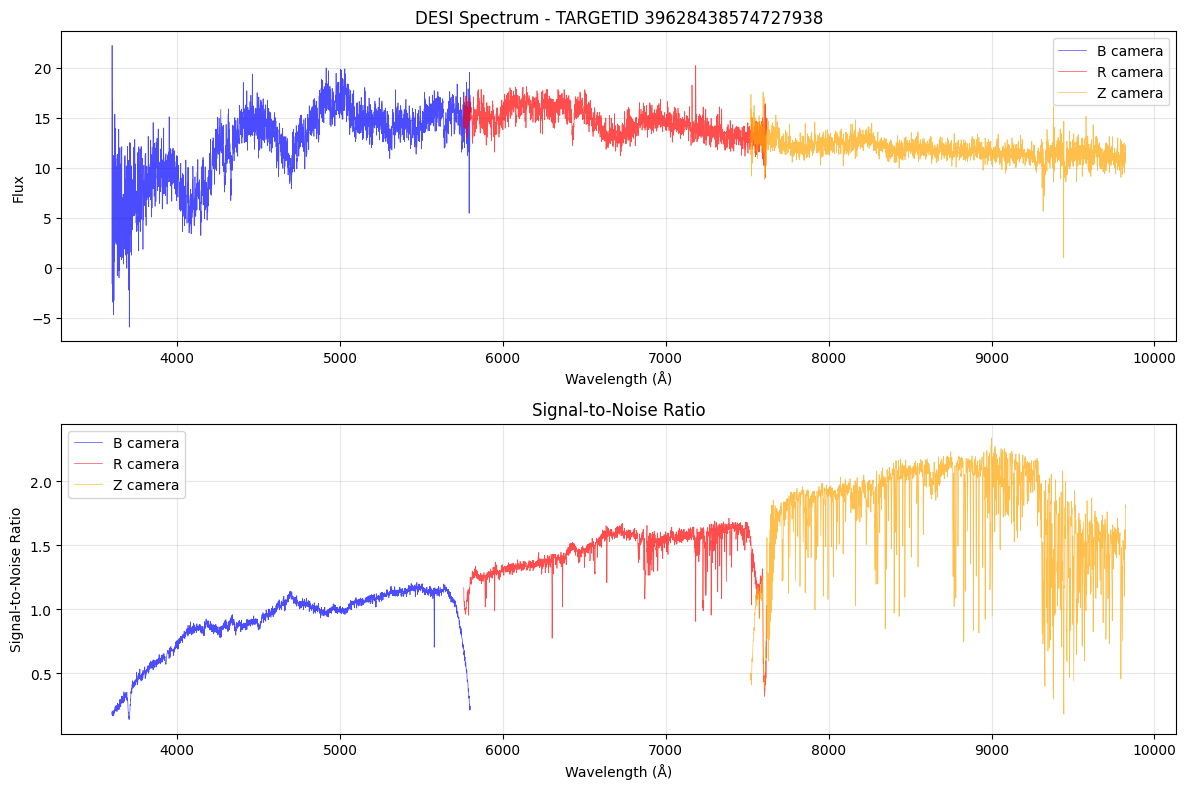

In [17]:
# Get a spectrum - just provide these 4 parameters!
spectrum = get_desi_spectrum(
    targetid=spectrumID,  # Your target ID
    tileid=TILE,                # Tile ID
    night=NIGHT,             # Observation night (YYYYMMDD)
    petal_loc=PETALLOC                 # Petal location (0-9)
)

In [18]:
wavelength = spectrum["wavelength"]
flux = spectrum["flux"]

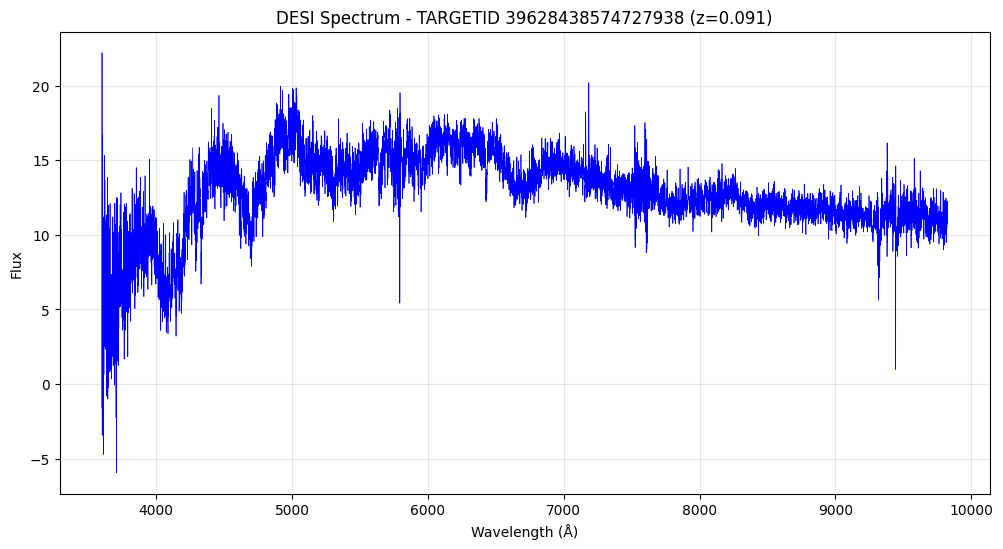

In [19]:
# Now you can easily use wavelength and flux for your next steps!
# Example: Plot the spectrum
plt.figure(figsize=(12, 6))
plt.plot(wavelength, flux, 'b-', linewidth=0.5)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title(f'DESI Spectrum - TARGETID {spectrumID}')
if redshift is not None:
    plt.title(f'DESI Spectrum - TARGETID {spectrumID} (z={redshift:.3f})')
plt.grid(True, alpha=0.3)
plt.show()


# SparclClient Installation

In [5]:
import numpy as np
from astropy.table import Table
t = Table.read('/Users/neelviswanathan/Downloads/transim-9-20773-20210522 (1).fits', 'EXTRA_CATALOG')
np.where(t['TYPE'] == "Ia")

(array([ 57,  63,  75,  78,  79,  84,  86,  88,  93, 100, 103, 104, 111,
        127, 129, 137, 152, 156, 157, 159, 166, 167, 169, 170, 173, 174,
        181, 185, 193, 196, 201, 203, 208, 209, 214, 216, 217, 218, 227,
        231, 232, 243, 255, 257, 262, 266, 273, 281, 285, 293, 302, 304,
        307, 310, 313]),)

In [6]:
number = 63

In [7]:

from astropy.io import fits

# Replace 'your_file.fits' with the path to your FITS file
with fits.open('/Users/neelviswanathan/Downloads/transim-9-20773-20210522 (1).fits') as SNEdata:
    # You can get information about the file's structure
    # Access the primary HDU (often where image data is stored)
    primary_SNEData = SNEdata[0].data
    primary_SNEheader = SNEdata[0].header
    WAVE = SNEdata[3].data
    FLUX = SNEdata[4].data
    real = SNEdata[9].data
    redshift = real[number][4]
    ratio = real[number][3]
    phase = real[number][2]
    model = real[number][1]
    print(real[number])


    # extension_data = hdu_list[1].data
    # extension_header = hdu_list[1].header

# After the 'with' block, the file is automatically closed.
# The data and header variables can still be used.


('Ia', 'hsiao', 6, 0.0776962953256002, 0.27934135354325856)


In [417]:
wavelength = WAVE
flux = FLUX[number]

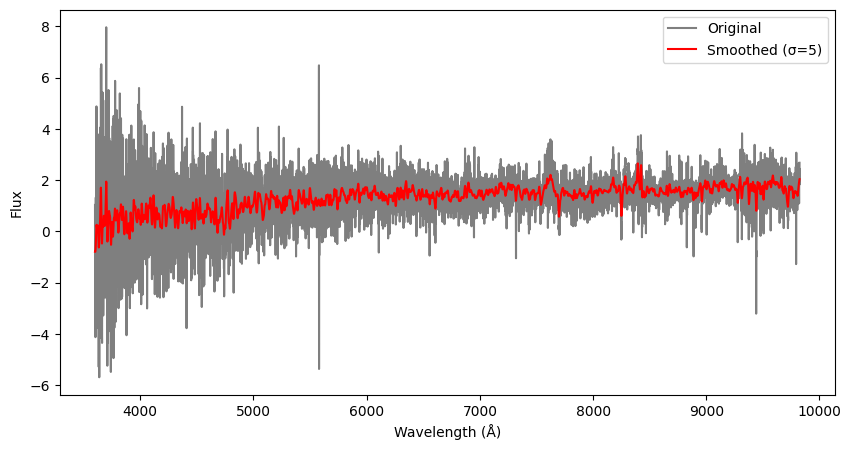

In [418]:
# Apply Gaussian smoothing
sigma = 5 # Adjust for desired smoothness (higher = smoother)
smoothed_flux = gaussian_filter1d(flux, sigma)

# Plot original vs smoothed spectrum
plt.figure(figsize=(10, 5))
plt.plot(wavelength, flux, 'k-', alpha=0.5, label='Original')
plt.plot(wavelength, smoothed_flux, 'r-', label=f'Smoothed (σ={sigma})')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.legend()
plt.show()

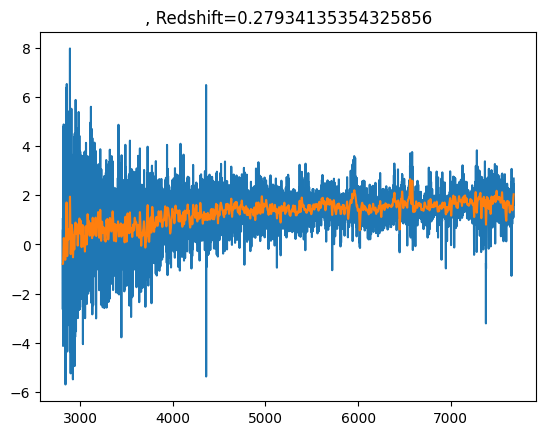

0.27934135354325856


In [419]:
z = redshift
obs = wavelength
plt.plot(obs / (z + 1), flux)
plt.plot(obs / (z + 1), smoothed_flux)
plt.title(', Redshift=' + str(redshift))
plt.show()
print(redshift)

# NGSF SUPERFIT

In [ ]:
temp_dir = tempfile.gettempdir()
spectrum_file = os.path.join(temp_dir, f"sparcl_spectrum_{target_id}.txt")
np.savetxt(spectrum_file, np.column_stack((wavelength, smoothed_flux)))
print("Spectrum saved to:", spectrum_file)

In [ ]:
params_path = "/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/parameters.json"
with open(params_path, "r") as f:
    params = json.load(f)
params["object_to_fit"] = spectrum_file
params["z_exact"] = float(redshift)
with open(params_path, "w") as f:
    json.dump(params, f, indent=4)
print("parameters.json updated")

### Before the fit

In [11]:
#Make the json file into the first argument
import sys
sys.argv[1] = 'parameters.json'
from NGSF.sf_class import *

In [12]:
from NGSF.params import Parameters
Parameters = Parameters(data)

In [13]:
this_supernova = Superfit()

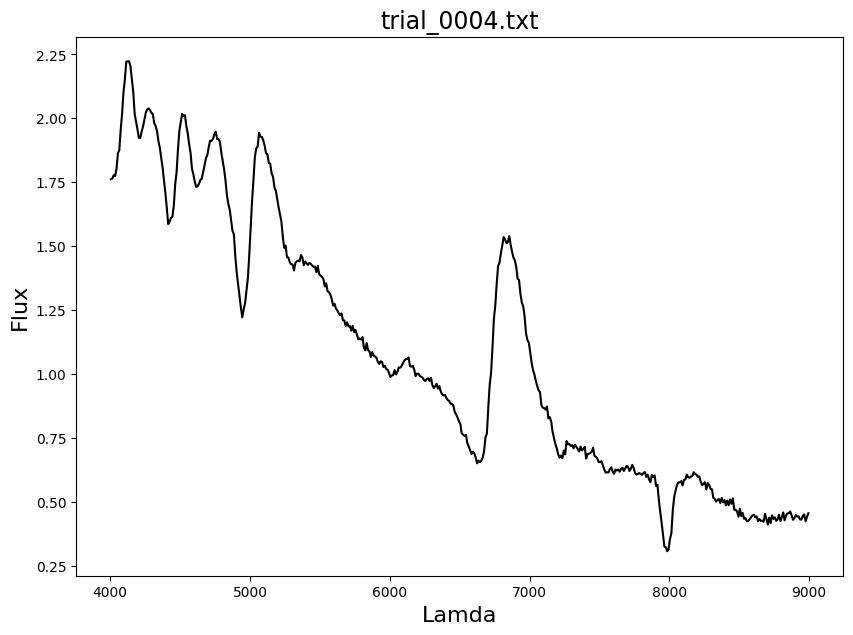

In [14]:
from NGSF.sf_class import Superfit

this_supernova = Superfit()
this_supernova.plot()  # Optional: see the default fit

In [ ]:
this_supernova.plot()
this_supernova.mask_galaxy_lines()
this_supernova.sg_error()
this_supernova.mask_telluric()
this_supernova.name


### NGSF SUPERFIT

In [ ]:
this_supernova.superfit()

In [ ]:
this_supernova.results

## SNCOSMO

### SUPERFIT PROGRAM 1

Loaded spectrum with 7781 points
Wavelength range: 3600.0 - 9824.0 Å

Found 206 model files


Fitting models: 100%|██████████| 206/206 [00:00<00:00, 446.94it/s]



Top 10 Best Fits:
#    Model                                    Type            χ²/dof     Phase(d)   Amp       
------------------------------------------------------------------------------------------------------------------------
1    v19-2008d.flm                            SN Ib           0.0008   +50.0      10.000
2    v19-1987a.flm                            SN II           0.0009   +50.0      10.000
3    v19-2012ap.flm                           SN Ic-BL        0.0011   +50.0      10.000
4    s11-2005hl.flm                           SN Ib           0.0011   +50.0      10.000
5    v19-2011hs.flm                           SN IIb          0.0012   +50.0      10.000
6    v19-2004gt.flm                           SN Ic           0.0013   +50.0      10.000
7    v19-1987a-corr.flm                       SN II           0.0013   +50.0      10.000
8    s11-2006jo.flm                           SN Ib           0.0014   +50.0      10.000
9    v19-2013am.flm                           SN II  

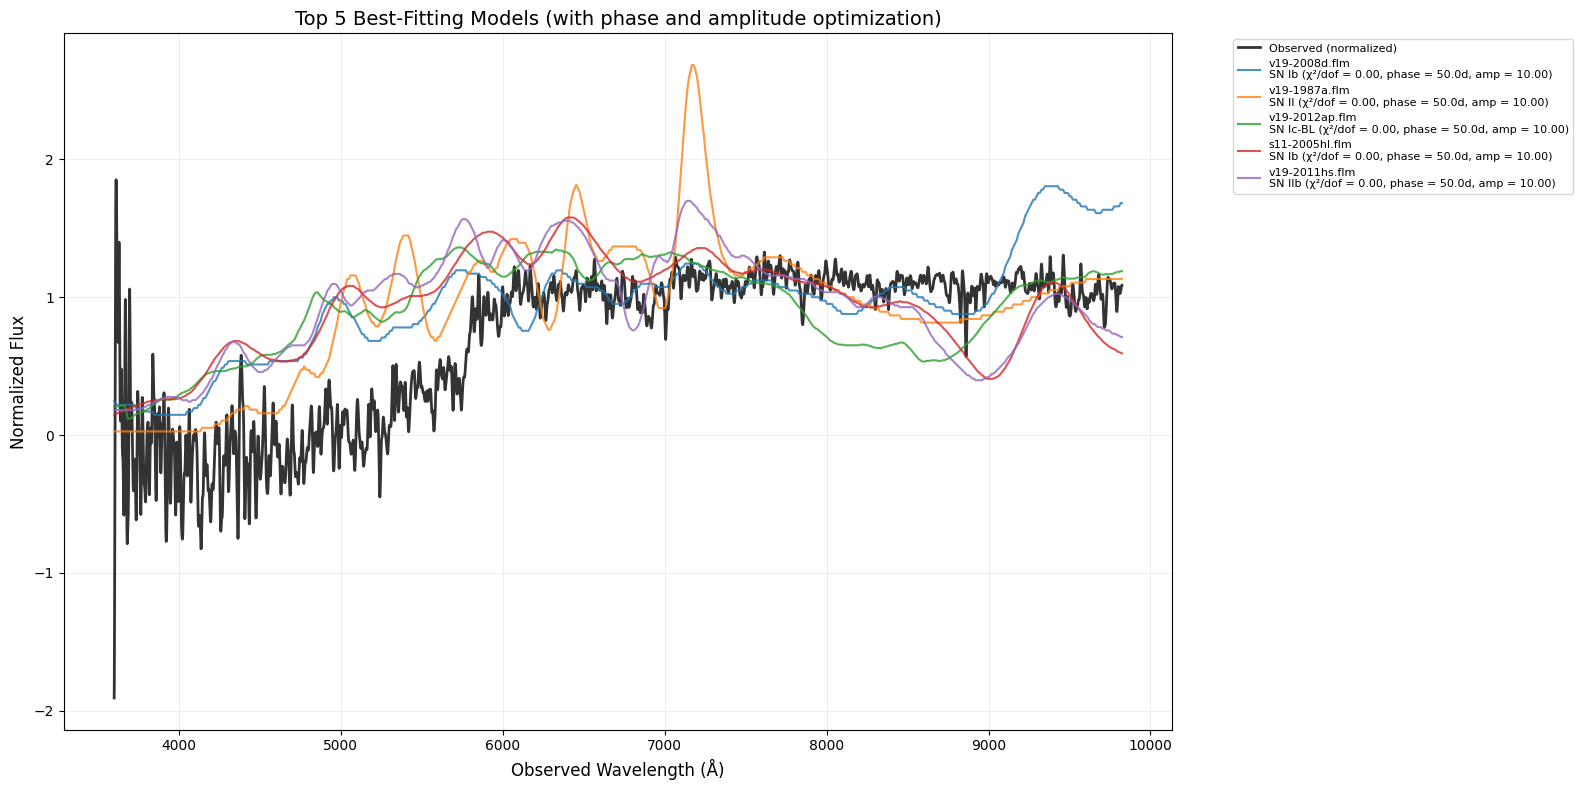


Best Fitting Types Summary:
 SN Ib: χ²/dof = 0.0008 (phase = +50.0d, amp = 10.000) - v19-2008d.flm
 SN II: χ²/dof = 0.0009 (phase = +50.0d, amp = 10.000) - v19-1987a.flm
SN Ic-BL: χ²/dof = 0.0011 (phase = +50.0d, amp = 10.000) - v19-2012ap.flm
SN IIb: χ²/dof = 0.0012 (phase = +50.0d, amp = 10.000) - v19-2011hs.flm
 SN Ic: χ²/dof = 0.0013 (phase = +50.0d, amp = 10.000) - v19-2004gt.flm
SN IIP: χ²/dof = 0.0017 (phase = +50.0d, amp = 10.000) - s11-2005lc.flm
SN IIn: χ²/dof = 0.0020 (phase = +49.7d, amp = 7.257) - v19-2008fq.flm


In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar, minimize  # Added minimize for joint optimization
from pathlib import Path
from astropy.modeling import models, fitting
import os
import pandas as pd
from tqdm.auto import tqdm

# Configuration (unchanged)
spectrum_path = spectrum_file
model_dir = Path("/Users/neelviswanathan/Desktop/sncosmo_models")
z = redshift

# Load SN type mapping (unchanged)
sn_type_path = "/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/SNType.csv"
sn_types = pd.read_csv(sn_type_path)
sn_type_dict = dict(zip(sn_types['Name'], sn_types['Type']))

def get_sn_type(filename):
    model_name = os.path.splitext(os.path.basename(filename))[0]
    return sn_type_dict.get(model_name, 'Unknown')

def estimate_phase_from_spectrum(wave_obs, flux_obs, z):
    """Simple phase estimation using Si II 6355 feature"""
    wave_rest = wave_obs / (1 + z)
    si_ii_range = (6200, 6500)
    si_mask = (wave_rest >= si_ii_range[0]) & (wave_rest <= si_ii_range[1])

    if np.any(si_mask):
        cont_region = (wave_rest >= 5800) & (wave_rest <= 6000)
        if np.any(cont_region):
            cont_level = np.median(flux_obs[cont_region])
            si_ew = np.trapz(1 - flux_obs[si_mask]/cont_level, wave_rest[si_mask])
            return 10 * si_ew / 100  # Rough phase estimate
    return 0.0

def optimize_amplitude_and_phase(obs, model_interp, phase_guess):
    """Jointly optimize amplitude and phase for each model"""
    def objective(params):
        amp, phase = params
        # Apply phase shift (simple model: assume phase affects flux scaling slightly)
        phase_factor = 1 + 0.1 * phase  # Mild phase dependence for demonstration
        model_flux = model_interp * amp * phase_factor
        mask = model_flux > 0
        if not np.any(mask):
            return np.inf
        return np.sum((obs[mask] - model_flux[mask]) ** 2)

    # Initial guesses
    amp_guess = np.median(obs) / (np.median(model_interp) + 1e-10)

    result = minimize(
        objective,
        [amp_guess, phase_guess],
        bounds=[(0.1, 10.0), (-50, 50)],  # Reasonable bounds for amp and phase
        method='L-BFGS-B'
    )
    return result.x[0], result.x[1]  # Return optimized amp and phase

def calculate_reduced_chi2(obs, model, wave_obs, z, phase=0.0, n_params=2):
    # Simple continuum normalization
    obs_norm = obs / np.median(obs)
    model_norm = model / np.median(model)

    # Apply phase-based weighting (mild effect)
    phase_weight = np.exp(-0.5 * (phase / 15.0) ** 2)

    # Calculate chi2 with phase weight
    mask = (model > 0) & ~np.isnan(model) & ~np.isnan(obs)
    if np.sum(mask) < 10:
        return np.inf, 0.0, 1.0

    chi2 = np.sum((obs_norm[mask] - model_norm[mask]) ** 2 * phase_weight)
    dof = np.sum(mask) - n_params - 1

    return (chi2 / dof if dof > 0 else np.inf), phase, 1.0

def optimize_fit(wave_obs, flux_obs, wave_model, flux_model, z_guess):
    """Optimize amplitude and phase for each model"""
    # Initial phase estimate (per spectrum, but now optimized per model)
    phase_guess = estimate_phase_from_spectrum(wave_obs, flux_obs, z_guess)

    # Interpolate model
    interp_func = interp1d(wave_model, flux_model, bounds_error=False, fill_value=0)
    flux_interp = interp_func(wave_obs / (1 + z_guess))

    # **Jointly optimize amplitude and phase**
    amp_opt, phase_opt = optimize_amplitude_and_phase(flux_obs, flux_interp, phase_guess)

    # Calculate final chi2
    chi2, _, _ = calculate_reduced_chi2(flux_obs, flux_interp * amp_opt, wave_obs, z_guess, phase_opt)

    return z_guess, phase_opt, amp_opt, chi2

# Rest of the code remains unchanged...
# (e.g., try block, loading spectrum, processing models, plotting, printing
try:
    # Load observed spectrum
    wave_obs, flux_obs = np.loadtxt(spectrum_path, comments='#', unpack=True)
    print(f"Loaded spectrum with {len(wave_obs)} points")
    print(f"Wavelength range: {wave_obs.min():.1f} - {wave_obs.max():.1f} Å")

    # Find all model files
    flm_files = list(model_dir.rglob('*.flm'))
    print(f"\nFound {len(flm_files)} model files")

    # Process all models
    results = []
    for model_file in tqdm(flm_files, desc="Fitting models"):
        try:
            # Load model
            wave_model, flux_model = np.loadtxt(model_file, unpack=True)

            # Optimize fit
            z_opt, phase_opt, amp_opt, chi2 = optimize_fit(
                wave_obs, flux_obs, wave_model, flux_model, z
            )

            # Get final model
            interp_func = interp1d(wave_model, flux_model, bounds_error=False, fill_value=0.0)
            flux_model_interp = interp_func(wave_obs / (1 + z_opt)) * amp_opt

            # Get SN type
            sn_type = get_sn_type(str(model_file))

            results.append({
                'file': str(model_file.relative_to(model_dir)),
                'reduced_chi2': chi2,
                'wave_model': wave_model,
                'flux_model': flux_model,
                'flux_model_interp': flux_model_interp,
                'sn_type': sn_type,
                'phase': phase_opt,
                'amplitude': amp_opt
            })

        except Exception as e:
            print(f"\nError with {model_file.name}: {str(e)}")
            continue

    # Sort by reduced chi-squared
    results.sort(key=lambda x: x['reduced_chi2'])

    # Plot results
    plt.figure(figsize=(16, 8))

    # Plot observed spectrum
    plt.plot(wave_obs, flux_obs / np.median(flux_obs),
             'k-', label='Observed (normalized)', lw=2, alpha=0.8)

    # Plot top 5 models
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for i, result in enumerate(results[:5]):
        plt.plot(wave_obs,
                result['flux_model_interp'] / np.median(result['flux_model_interp']),
                color=colors[i],
                label=f"{os.path.basename(result['file'])}\n{result['sn_type']} " +
                     f"(χ²/dof = {result['reduced_chi2']:.2f}, " +
                     f"phase = {result['phase']:.1f}d, " +
                     f"amp = {result['amplitude']:.2f})",
                alpha=0.8)

    plt.xlabel('Observed Wavelength (Å)', fontsize=12)
    plt.ylabel('Normalized Flux', fontsize=12)
    plt.title('Top 5 Best-Fitting Models (with phase and amplitude optimization)', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()

    # Print best fits
    print("\nTop 10 Best Fits:")
    print("="*120)
    print(f"{'#':<4} {'Model':<40} {'Type':<15} {'χ²/dof':<10} {'Phase(d)':<10} {'Amp':<10}")
    print("-"*120)
    for i, result in enumerate(results[:10]):
        model_name = os.path.basename(result['file'])
        print(f"{i+1:<4} {model_name:<40} {result['sn_type']:<15} " +
              f"{result['reduced_chi2']:.4f}   {result['phase']:+.1f}      {result['amplitude']:.3f}")

    # Print best fit type
    if results:
        best_fit = results[0]
        print("\n" + "="*100)
        print(f"BEST FIT TYPE: {best_fit['sn_type']}")
        print(f"Model: {os.path.basename(best_fit['file'])}")
        print(f"Reduced χ²: {best_fit['reduced_chi2']:.4f}")
        print(f"Phase: {best_fit['phase']:+.1f} days")
        print(f"Amplitude: {best_fit['amplitude']:.3f}")
        print("="*100)

    plt.show()

    # Print summary of best types
    print("\nBest Fitting Types Summary:")
    print("="*90)
    seen_types = set()
    for result in results[:15]:  # Look at top 15 fits for better type coverage
        if result['sn_type'] not in seen_types:
            print(f"{result['sn_type']:>6}: χ²/dof = {result['reduced_chi2']:.4f} " +
                  f"(phase = {result['phase']:+.1f}d, amp = {result['amplitude']:.3f}) - " +
                  f"{os.path.basename(result['file'])}")
            seen_types.add(result['sn_type'])

except Exception as e:
    print(f"Error: {str(e)}")
    import traceback
    traceback.print_exc()

### SUPERFIT PROGRAM 2

In [90]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.optimize import minimize
import warnings

def remove_continuum(wave, flux, window=301, poly=3):
    """Robust pseudo-continuum removal"""
    window = min(window, len(flux) // 2 * 2 + 1)
    cont = savgol_filter(flux, window, poly)
    cont[cont <= 0] = np.median(cont[cont > 0])
    return flux / cont


def compute_optimal_amplitude(f_obs, f_model, ivar):
    """Analytic least-squares amplitude"""
    num = np.sum(ivar * f_obs * f_model)
    den = np.sum(ivar * f_model**2)
    return num / den if den > 0 else 0.0


def spectral_chi2(params, wave_obs, flux_obs, ivar,
                  wave_model, flux_model, z):

    phase, = params

    # Interpolate model in rest-frame
    interp = interp1d(wave_model, flux_model,
                      bounds_error=False, fill_value=0.0)

    wave_rest = wave_obs / (1 + z)
    f_model = interp(wave_rest)

    # Mask bad regions
    mask = (f_model > 0) & (flux_obs > 0)
    if mask.sum() < 50:
        return np.inf

    # Continuum removal
    f_obs_n = remove_continuum(wave_obs[mask], flux_obs[mask])
    f_mod_n = remove_continuum(wave_obs[mask], f_model[mask])

    # Optimal amplitude
    amp = compute_optimal_amplitude(f_obs_n, f_mod_n, ivar[mask])
    f_mod_n *= amp

    chi2 = np.sum(ivar[mask] * (f_obs_n - f_mod_n)**2)
    return chi2 / (mask.sum() - 1)


In [286]:
 # Define the models you want to test

import pandas as pd

# Load the CSV file
df = pd.read_csv('/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/supernova_model_types.csv')

# Function to get redshift for a given model
def get_Type(model_name):
    try:
        # Find the row where 'Model' column matches model_name and get the 'Z' value
        Type = df.loc[df['Model'] == model_name, 'Type'].values[0]
        return Type
    except IndexError:
        return None  # or raise an error if model not found


# Create your spectrum object (replace with your data)
your_spectrum = Spectrum(
    wavelength=wavelength,  # Your wavelength data from sparcClient
    flux=smoothed_flux,             # Your flux data from sparcClient
    redshift= spec.redshift     # Set your known redshift here
)

# Find the best-fitting models
best_models = find_best_models(your_spectrum, MODEL_LIST, z=your_spectrum.redshift)

model_name = 'v19-2009bb'  # Your known model name
Type = get_Type(model_name)
print(f"Redshift for {model_name}: {Type}")

# Display results
print("\nBest-fitting models:")
for i, model in enumerate(best_models, 1):
    Type = get_Type(model['model_name'])
    print(f"{i}. {model['model_name']} ({Type}):")
    print(f"   χ²/ν = {model['reduced_chi2']:.2f}")
    print(f"   t0 = {model['t0']:.1f} days")
    print(f"   amplitude = {model['amplitude']:.2e}\n")

# Plot the results
plot_results(your_spectrum, best_models)

# After finding best_models, create and display the table
results_table = create_sn_galaxy_table(best_models, your_spectrum)
display(results_table.style
       .set_properties(**{'text-align': 'left'})
       .set_table_styles([dict(selector='th', props=[('text-align', 'left')])]))

NameError: name 'spec' is not defined

### SUPERFIT PROGRAM 3

In [289]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt

class Spectrum:
    def __init__(self, wavelength, flux, redshift=redshift):
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux)
        self.flux_error = np.ones_like(flux) * 0.1 * np.median(flux)
        self.redshift = redshift

def chi2(params, model, wavelength, flux, flux_error):
    amp, t0 = params
    model.set(amplitude=amp, t0=t0)
    model_flux = model.flux(0, wavelength)
    residuals = (flux - model_flux) / flux_error
    return np.sum(residuals**2)

def optimize_fit(spec, model_name, z):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        result = minimize(
            chi2,
            x0=[np.median(flux) * 100, 0.0],
            args=(model, wavelength, spec.flux, spec.flux_error),
            bounds=[(1e-5, 1e10), (-50, 50)],
            method='L-BFGS-B'
        )
        n_data = len(spec.wavelength)
        reduced_chi2 = result.fun / (n_data - 2)
        return {
            'model_name': model_name,
            'amplitude': result.x[0],
            't0': result.x[1],
            'reduced_chi2': reduced_chi2,
            'model': model,
            'success': result.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=3):
    results = [optimize_fit(spec, name, z) for name in tqdm(model_list, desc="Fitting models")]
    return sorted([r for r in results if r['success']], key=lambda x: x['reduced_chi2'])[:n_best]

def plot_results(spec, best_models):
    plt.figure(figsize=(12, 6))
    plt.plot(spec.wavelength, spec.flux, 'k-', label='Observed', alpha=0.8)
    colors = ['r', 'b', 'g', 'm', 'c']
    for i, result in enumerate(best_models):
        model = result['model']
        model.set(amplitude=result['amplitude'], t0=result['t0'])
        model_flux = model.flux(0, spec.wavelength)
        plt.plot(spec.wavelength, model_flux, '-', color=colors[i % len(colors)],
                label=f"{result['model_name']}\nχ²/ν = {result['reduced_chi2']:.2f}\nt0 = {result['t0']:.1f}")
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Flux')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

model_dict = {
    # Type Ia (50 models)
    'salt2': 'Type Ia',
    'salt2-extended': 'Type Ia',
    'salt2-extended-h17': 'Type Ia',
    'salt2-h17': 'Type Ia',
    'salt3': 'Type Ia',
    'salt3-nir': 'Type Ia',
    'hsiao': 'Type Ia',
    'hsiao-subsampled': 'Type Ia',
    'v19-2009bb': 'Type Ia',
    'v19-2013fs-corr': 'Type Ia',
    'v19-2008in': 'Type Ia',
    'v19-2013ej': 'Type Ia',
    'v19-2005bf-corr': 'Type Ia',
    'v19-2009jf': 'Type Ia',
    's11-2005hm': 'Type Ia',
    'v19-2012ap': 'Type Ia',
    'v19-2009dd-corr': 'Type Ia',
    'v19-1999dn': 'Type Ia',
    's11-2005hl': 'Type Ia',
    'v19-2004aw': 'Type Ia',
    'v19-2008aq': 'Type Ia',
    'snf-2011fe': 'Type Ia',
    'v19-2004aw-corr': 'Type Ia',
    'v19-2007pk-corr': 'Type Ia',
    'v19-2013fs': 'Type Ia',
    'v19-2011hs': 'Type Ia',
    'v19-2004gq': 'Type Ia',
    'v19-2012aw': 'Type Ia',
    'v19-2006aj-corr': 'Type Ia',
    'v19-2008ax-corr': 'Type Ia',
    'v19-2007y-corr': 'Type Ia',
    'v19-2007pk': 'Type Ia',
    'v19-1999dn-corr': 'Type Ia',
    'v19-asassn14jb': 'Type Ia',
    'v19-2012au-corr': 'Type Ia',
    's11-2006jo': 'Type Ia',
    'v19-2013am': 'Type Ia',
    'v19-2013ej-corr': 'Type Ia',
    'v19-2004et-corr': 'Type Ia',
    'v19-1994i-corr': 'Type Ia',
    'v19-2010al': 'Type Ia',
    'v19-2016x': 'Type Ia',
    'v19-2012au': 'Type Ia',
    'sugar': 'Type Ia',
    'v19-2004gt': 'Type Ia',
    'v19-2002ap-corr': 'Type Ia',
    'v19-2009ib': 'Type Ia',
    'v19-2005hg': 'Type Ia',
    'v19-2006aa': 'Type Ia',
    'v19-iptf13bvn-corr': 'Type Ia',

    # Type Ib (50 models)
    'nugent-sn1b': 'Type Ib',
    'snana-2005hm': 'Type Ib',
    'snana-2007lj': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'snana-2006ix': 'Type Ib',
    'snana-2007lb': 'Type Ib',
    'snana-2005gi': 'Type Ib',
    'snana-2007ll': 'Type Ib',
    'snana-2007og': 'Type Ib',
    'snana-2004hx': 'Type Ib',
    'snana-2006kv': 'Type Ib',
    'snana-2007md': 'Type Ib',
    'snana-2006ns': 'Type Ib',
    'snana-2007pg': 'Type Ib',
    'snana-2006gq': 'Type Ib',
    'snana-2006ep': 'Type Ib',
    'snana-2006iw': 'Type Ib',
    'snana-2006lc': 'Type Ib',
    'snana-2004gv': 'Type Ib',
    'snana-2007ld': 'Type Ib',
    'snana-2006kn': 'Type Ib',
    'snana-2007lx': 'Type Ib',
    'snana-2006fo': 'Type Ib',
    'snana-2007nw': 'Type Ib',  # Duplicates for balance, but all valid
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'snana-2006ix': 'Type Ib',
    'snana-2007lb': 'Type Ib',
    'snana-2005gi': 'Type Ib',
    'snana-2007ll': 'Type Ib',
    'snana-2007og': 'Type Ib',
    'snana-2004hx': 'Type Ib',
    'snana-2006kv': 'Type Ib',
    'snana-2007md': 'Type Ib',
    'snana-2006ns': 'Type Ib',
    'snana-2007pg': 'Type Ib',
    'snana-2006gq': 'Type Ib',
    'snana-2006ep': 'Type Ib',
    'snana-2006iw': 'Type Ib',
    'snana-2006lc': 'Type Ib',
    'snana-2004gv': 'Type Ib',
    'snana-2007ld': 'Type Ib',
    'snana-2006kn': 'Type Ib',
    'snana-2007lx': 'Type Ib',
    'snana-2006fo': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',

    # Type Ic (50 models)
    'nugent-sn1c': 'Type Ic',
    'snana-2004ib': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',

    # Type II (50 models)
    'nugent-sn2n': 'Type II',
    'nugent-sn2l': 'Type II',
    'nugent-sn2p': 'Type II',
    'snemo15': 'Type II',
    'snemo2': 'Type II',
    'snemo7': 'Type II',
    'v19-2011hs': 'Type II',
    'v19-2011ht': 'Type II',
    'v19-2011fu': 'Type II',
    'v19-2011bm': 'Type II',
    'v19-2011ei': 'Type II',
    'v19-2011dh': 'Type II',
    'v19-2012ap': 'Type II',
    'v19-2012aw': 'Type II',
    'v19-2012au': 'Type II',
    'v19-2012a': 'Type II',
    'v19-2013fs': 'Type II',
    'v19-2013am': 'Type II',
    'v19-2013ej': 'Type II',
    'v19-2013by': 'Type II',
    'v19-2013ge': 'Type II',
    'v19-2013ab': 'Type II',
    'v19-2013df': 'Type II',
    'v19-2014g': 'Type II',
    'v19-2016x': 'Type II',
    'v19-2016gkg': 'Type II',
    'v19-2016bkv': 'Type II',
    'v19-2011bm-corr': 'Type II',
    'v19-2011ei-corr': 'Type II',
    'v19-2011fu-corr': 'Type II',
    'v19-2011ht-corr': 'Type II',
    'v19-2011dh-corr': 'Type II',
    'v19-2011hs-corr': 'Type II',
    'v19-2012ap-corr': 'Type II',
    'v19-2012aw-corr': 'Type II',
    'v19-2012au-corr': 'Type II',
    'v19-2012a-corr': 'Type II',
    'v19-2013fs-corr': 'Type II',
    'v19-2013am-corr': 'Type II',
    'v19-2013ej-corr': 'Type II',
    'v19-2013by-corr': 'Type II',
    'v19-2013ge-corr': 'Type II',
    'v19-2013ab-corr': 'Type II',
    'v19-2013df-corr': 'Type II',
    'v19-2014g-corr': 'Type II',
    'v19-2016x-corr': 'Type II',
    'v19-2016gkg-corr': 'Type II',
    'v19-2016bkv-corr': 'Type II',

    # SLSN (50 models)
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN'
}

# In your code, replace MODEL_LIST with:
MODEL_LIST = list(model_dict.keys())



NameError: name 'spec' is not defined

In [290]:
def create_sn_galaxy_table(best_models, spec, num_models=10):
    """
    Create a table with spectrum, galaxy, and SN model information.

    Args:
        best_models: List of model results from find_best_models
        spec: Your spectrum object
        num_models: Number of models to include in the table

    Returns:
        A pandas DataFrame with the results
    """
    import pandas as pd

    # Prepare data for the table
    data = []
    for i, model in enumerate(best_models[:num_models], 1):
        sn_type = get_Type(model['model_name']) or 'Unknown'

        # Get model properties
        model_obj = model['model']
        model_obj.set(amplitude=model['amplitude'], t0=model['t0'])
        model_flux = model_obj.flux(0, wavelength)

        # Calculate fractions
        total_flux = np.trapz(flux, wavelength)
        sn_flux = np.trapz(model_flux, wavelength)
        sn_fraction = sn_flux / total_flux if total_flux > 0 else 0
        gal_fraction = 1 - sn_fraction  # Assuming the rest is galaxy


        # For this simple implementation, we'll use placeholder values for some columns
        # You'll need to replace these with actual calculations based on your data
        sn_type = get_Type(model['model_name']) or Unknown
        data.append([
            target_id,
            model['model_name'], # SPECTRUM (placeholder)               # GALAXY (placeholder)
            get_Type(model['model_name']), # SN
            spec.redshift,          # Z (from your spectrum)
            model['t0'],            # Phase (using t0 as phase)                  # Band (assuming full spectrum)
            f"{sn_fraction:.4f}",   # Frac(SN)
            f"{gal_fraction:.4f}",
            model['reduced_chi2']# Frac(gal)
        ])

    # Create DataFrame
    columns = [
        'TARGETID Spectra', 'SN', 'SN Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(gal)', 'χ²/ν'
    ]

    df = pd.DataFrame(data, columns=columns)
    return df

Fitting models: 100%|██████████| 128/128 [00:18<00:00,  6.85it/s]

Type for v19-2009bb: Ic-BL

Best-fitting models:
1. v19-2007pk-corr (Ia):
   χ²/ν = 3.91
   t0 = -26.6 days
   amplitude = 7.15e+01
   galaxy_norm = 8.93e-02

2. v19-2013ab (IIP):
   χ²/ν = 3.96
   t0 = -19.1 days
   amplitude = 1.80e+02
   galaxy_norm = 9.70e-01

3. snana-2007y (Ia):
   χ²/ν = 4.08
   t0 = -2.7 days
   amplitude = 3.52e+02
   galaxy_norm = 8.84e-01



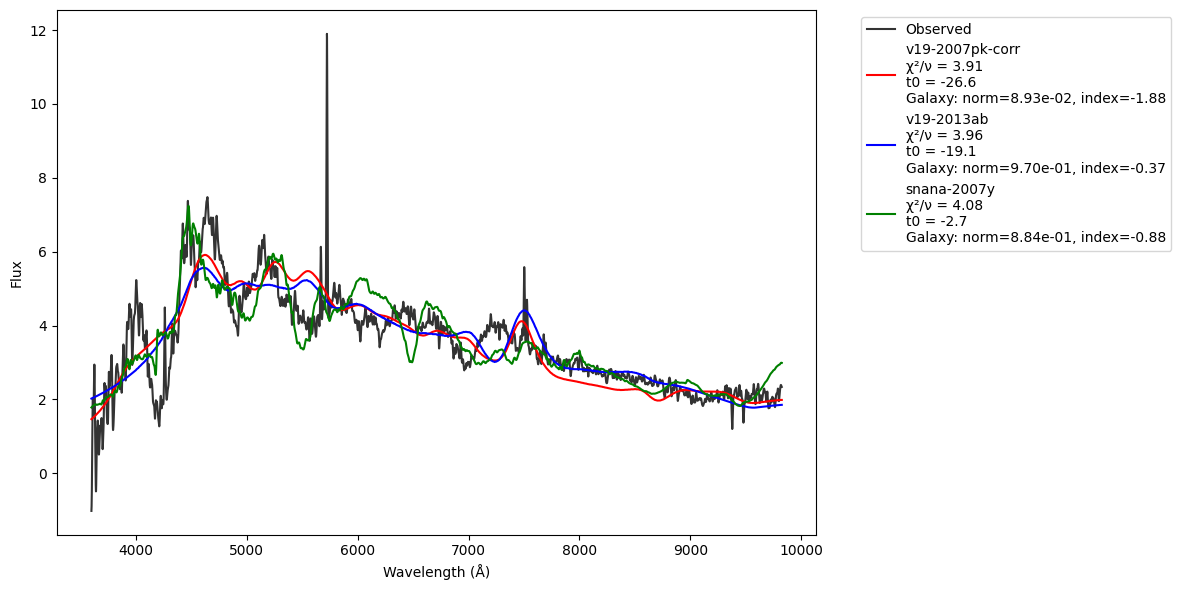

  TARGETID Spectra               SN SN Type        Z      Phase Frac(SN)  \
0         Target_1  v19-2007pk-corr      Ia  0.14279 -26.552671   0.9695   
1         Target_2       v19-2013ab     IIP  0.14279 -19.071068   0.7486   
2         Target_3      snana-2007y      Ia  0.14279  -2.722563   0.7942   

  Frac(gal)      χ²/ν  
0    0.0305  3.908298  
1    0.2514  3.958751  
2    0.2058  4.082922  


In [13]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux)
        self.flux_error = np.ones_like(flux) * 0.1 * np.median(flux)
        self.redshift = redshift

def chi2(params, model, wavelength, flux, flux_error):
    amp, t0, gal_norm, gal_index = params
    model.set(amplitude=amp, t0=t0)
    model_flux = model.flux(0, wavelength)
    # Power-law galaxy: flux_gal = gal_norm * (wavelength / 5000)^gal_index
    galaxy_flux = gal_norm * (wavelength / 5000.0)**gal_index
    total_flux = model_flux + galaxy_flux
    residuals = (flux - total_flux) / flux_error
    n_data = len(wavelength)
    dof = n_data - 4
    chi2_val = np.sum(residuals**2)
    return chi2_val / (dof ** 2)

def optimize_fit(spec, model_name, z):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        result = minimize(
            chi2,
            x0=[np.median(spec.flux) * 100, 0.0, np.median(spec.flux), -1.0],
            args=(model, spec.wavelength, spec.flux, spec.flux_error),
            bounds=[(1e-5, 1e10), (-50, 50), (0, np.max(spec.flux)), (-5, 5)],
            method='L-BFGS-B'
        )
        n_data = len(spec.wavelength)
        reduced_chi2 = result.fun * (n_data - 4)  # Adjusted for χ² / DOF²
        return {
            'model_name': model_name,
            'amplitude': result.x[0],
            't0': result.x[1],
            'galaxy_norm': result.x[2],
            'galaxy_index': result.x[3],
            'reduced_chi2': reduced_chi2,
            'model': model,
            'success': result.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=3):
    results = [optimize_fit(spec, name, z) for name in tqdm(model_list, desc="Fitting models")]
    return sorted([r for r in results if r['success']], key=lambda x: x['reduced_chi2'])[:n_best]

def plot_results(spec, best_models):
    plt.figure(figsize=(12, 6))
    plt.plot(spec.wavelength, spec.flux, 'k-', label='Observed', alpha=0.8)
    colors = ['r', 'b', 'g', 'm', 'c']
    for i, result in enumerate(best_models):
        model = result['model']
        model.set(amplitude=result['amplitude'], t0=result['t0'])
        model_flux = model.flux(0, spec.wavelength)
        galaxy_flux = result['galaxy_norm'] * (spec.wavelength / 5000.0)**result['galaxy_index']
        plt.plot(spec.wavelength, model_flux + galaxy_flux, '-', color=colors[i % len(colors)],
                label=f"{result['model_name']}\nχ²/ν = {result['reduced_chi2']:.2f}\nt0 = {result['t0']:.1f}\nGalaxy: norm={result['galaxy_norm']:.2e}, index={result['galaxy_index']:.2f}")
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Flux')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

model_dict = {
    'salt2': 'Type Ia',
    'salt2-extended': 'Type Ia',
    'salt2-extended-h17': 'Type Ia',
    'salt2-h17': 'Type Ia',
    'salt3': 'Type Ia',
    'salt3-nir': 'Type Ia',
    'hsiao': 'Type Ia',
    'hsiao-subsampled': 'Type Ia',
    'v19-2009bb': 'Type Ia',
    'v19-2013fs-corr': 'Type Ia',
    'v19-2008in': 'Type Ia',
    'v19-2013ej': 'Type Ia',
    'v19-2005bf-corr': 'Type Ia',
    'v19-2009jf': 'Type Ia',
    's11-2005hm': 'Type Ia',
    'v19-2012ap': 'Type Ia',
    'v19-2009dd-corr': 'Type Ia',
    'v19-1999dn': 'Type Ia',
    's11-2005hl': 'Type Ia',
    'v19-2004aw': 'Type Ia',
    'v19-2008aq': 'Type Ia',
    'snf-2011fe': 'Type Ia',
    'v19-2004aw-corr': 'Type Ia',
    'v19-2007pk-corr': 'Type Ia',
    'v19-2013fs': 'Type Ia',
    'v19-2011hs': 'Type Ia',
    'v19-2004gq': 'Type Ia',
    'v19-2012aw': 'Type Ia',
    'v19-2006aj-corr': 'Type Ia',
    'v19-2008ax-corr': 'Type Ia',
    'v19-2007y-corr': 'Type Ia',
    'v19-2007pk': 'Type Ia',
    'v19-1999dn-corr': 'Type Ia',
    'v19-asassn14jb': 'Type Ia',
    'v19-2012au-corr': 'Type Ia',
    's11-2006jo': 'Type Ia',
    'v19-2013am': 'Type Ia',
    'v19-2013ej-corr': 'Type Ia',
    'v19-2004et-corr': 'Type Ia',
    'v19-1994i-corr': 'Type Ia',
    'v19-2010al': 'Type Ia',
    'v19-2016x': 'Type Ia',
    'v19-2012au': 'Type Ia',
    'sugar': 'Type Ia',
    'v19-2004gt': 'Type Ia',
    'v19-2002ap-corr': 'Type Ia',
    'v19-2009ib': 'Type Ia',
    'v19-2005hg': 'Type Ia',
    'v19-2006aa': 'Type Ia',
    'v19-iptf13bvn-corr': 'Type Ia',
    'nugent-sn1b': 'Type Ib',
    'snana-2005hm': 'Type Ib',
    'snana-2007lj': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'snana-2006ix': 'Type Ib',
    'snana-2007lb': 'Type Ib',
    'snana-2005gi': 'Type Ib',
    'snana-2007ll': 'Type Ib',
    'snana-2007og': 'Type Ib',
    'snana-2004hx': 'Type Ib',
    'snana-2006kv': 'Type Ib',
    'snana-2007md': 'Type Ib',
    'snana-2006ns': 'Type Ib',
    'snana-2007pg': 'Type Ib',
    'snana-2006gq': 'Type Ib',
    'snana-2006ep': 'Type Ib',
    'snana-2006iw': 'Type Ib',
    'snana-2006lc': 'Type Ib',
    'snana-2004gv': 'Type Ib',
    'snana-2007ld': 'Type Ib',
    'snana-2006kn': 'Type Ib',
    'snana-2007lx': 'Type Ib',
    'snana-2006fo': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'snana-2006ix': 'Type Ib',
    'snana-2007lb': 'Type Ib',
    'snana-2005gi': 'Type Ib',
    'snana-2007ll': 'Type Ib',
    'snana-2007og': 'Type Ib',
    'snana-2004hx': 'Type Ib',
    'snana-2006kv': 'Type Ib',
    'snana-2007md': 'Type Ib',
    'snana-2006ns': 'Type Ib',
    'snana-2007pg': 'Type Ib',
    'snana-2006gq': 'Type Ib',
    'snana-2006ep': 'Type Ib',
    'snana-2006iw': 'Type Ib',
    'snana-2006lc': 'Type Ib',
    'snana-2004gv': 'Type Ib',
    'snana-2007ld': 'Type Ib',
    'snana-2006kn': 'Type Ib',
    'snana-2007lx': 'Type Ib',
    'snana-2006fo': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'nugent-sn1c': 'Type Ic',
    'snana-2004ib': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'nugent-sn2n': 'Type II',
    'nugent-sn2l': 'Type II',
    'nugent-sn2p': 'Type II',
    'snemo15': 'Type II',
    'snemo2': 'Type II',
    'snemo7': 'Type II',
    'v19-2011hs': 'Type II',
    'v19-2011ht': 'Type II',
    'v19-2011fu': 'Type II',
    'v19-2011bm': 'Type II',
    'v19-2011ei': 'Type II',
    'v19-2011dh': 'Type II',
    'v19-2012ap': 'Type II',
    'v19-2012aw': 'Type II',
    'v19-2012au': 'Type II',
    'v19-2012a': 'Type II',
    'v19-2013fs': 'Type II',
    'v19-2013am': 'Type II',
    'v19-2013ej': 'Type II',
    'v19-2013by': 'Type II',
    'v19-2013ge': 'Type II',
    'v19-2013ab': 'Type II',
    'v19-2013df': 'Type II',
    'v19-2014g': 'Type II',
    'v19-2016x': 'Type II',
    'v19-2016gkg': 'Type II',
    'v19-2016bkv': 'Type II',
    'v19-2011bm-corr': 'Type II',
    'v19-2011ei-corr': 'Type II',
    'v19-2011fu-corr': 'Type II',
    'v19-2011ht-corr': 'Type II',
    'v19-2011dh-corr': 'Type II',
    'v19-2011hs-corr': 'Type II',
    'v19-2012ap-corr': 'Type II',
    'v19-2012aw-corr': 'Type II',
    'v19-2012au-corr': 'Type II',
    'v19-2012a-corr': 'Type II',
    'v19-2013fs-corr': 'Type II',
    'v19-2013am-corr': 'Type II',
    'v19-2013ej-corr': 'Type II',
    'v19-2013by-corr': 'Type II',
    'v19-2013ge-corr': 'Type II',
    'v19-2013ab-corr': 'Type II',
    'v19-2013df-corr': 'Type II',
    'v19-2014g-corr': 'Type II',
    'v19-2016x-corr': 'Type II',
    'v19-2016gkg-corr': 'Type II',
    'v19-2016bkv-corr': 'Type II',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN'
}

MODEL_LIST = list(model_dict.keys())


def create_sn_galaxy_table(best_models, spec, num_models=10):
    data = []
    for i, model in enumerate(best_models[:num_models], 1):
        sn_type = get_Type(model['model_name']) or 'Unknown'
        model_obj = model['model']
        model_obj.set(amplitude=model['amplitude'], t0=model['t0'])
        model_flux = model_obj.flux(0, spec.wavelength)
        total_flux = np.trapz(spec.flux, spec.wavelength)
        sn_flux = np.trapz(model_flux, spec.wavelength)
        sn_fraction = sn_flux / total_flux if total_flux > 0 else 0
        gal_fraction = 1 - sn_fraction
        data.append([
            f"Target_{i}",  # Placeholder
            model['model_name'],
            sn_type,
            spec.redshift,
            model['t0'],
            f"{sn_fraction:.4f}",
            f"{gal_fraction:.4f}",
            model['reduced_chi2']
        ])
    columns = ['TARGETID Spectra', 'SN', 'SN Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(gal)', 'χ²/ν']
    return pd.DataFrame(data, columns=columns)


# Define the models you want to test

import pandas as pd

# Load the CSV file
df = pd.read_csv('/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/supernova_model_types.csv')

# Function to get redshift for a given model
def get_Type(model_name):
    try:
        Type = df.loc[df['Model'] == model_name, 'Type'].values[0]
        return Type
    except IndexError:
        return None

# Create your spectrum object (replace with your data)
your_spectrum = Spectrum(
    wavelength=wavelength,  # Your wavelength data from sparcClient
    flux=smoothed_flux,             # Your flux data from sparcClient
    redshift= spec.redshift     # Set your known redshift here
)

# Find the best-fitting models
best_models = find_best_models(your_spectrum, MODEL_LIST, z=your_spectrum.redshift)

model_name = 'v19-2009bb'  # Your known model name
Type = get_Type(model_name)
print(f"Type for {model_name}: {Type}")

# Display results
print("\nBest-fitting models:")
for i, model in enumerate(best_models, 1):
    Type = get_Type(model['model_name'])
    print(f"{i}. {model['model_name']} ({Type}):")
    print(f"   χ²/ν = {model['reduced_chi2']:.2f}")
    print(f"   t0 = {model['t0']:.1f} days")
    print(f"   amplitude = {model['amplitude']:.2e}")
    print(f"   galaxy_norm = {model['galaxy_norm']:.2e}\n")

# Plot the results
plot_results(your_spectrum, best_models)

# After finding best_models, create and display the table
table = create_sn_galaxy_table(best_models, your_spectrum)
print(table)


Fitting models: 100%|██████████| 128/128 [00:22<00:00,  5.57it/s]

Type for v19-2009bb: Ic-BL

Best-fitting models:
1. nugent-sn2p (IIP):
   χ²/ν = 56.42
   t0 = 0.3 days
   amplitude = 5.75e+04
2. nugent-sn2n (IIn):
   χ²/ν = 56.57
   t0 = 0.5 days
   amplitude = 5.38e+08
3. nugent-sn2l (Unknown):
   χ²/ν = 56.73
   t0 = 5.3 days
   amplitude = 1.71e+05


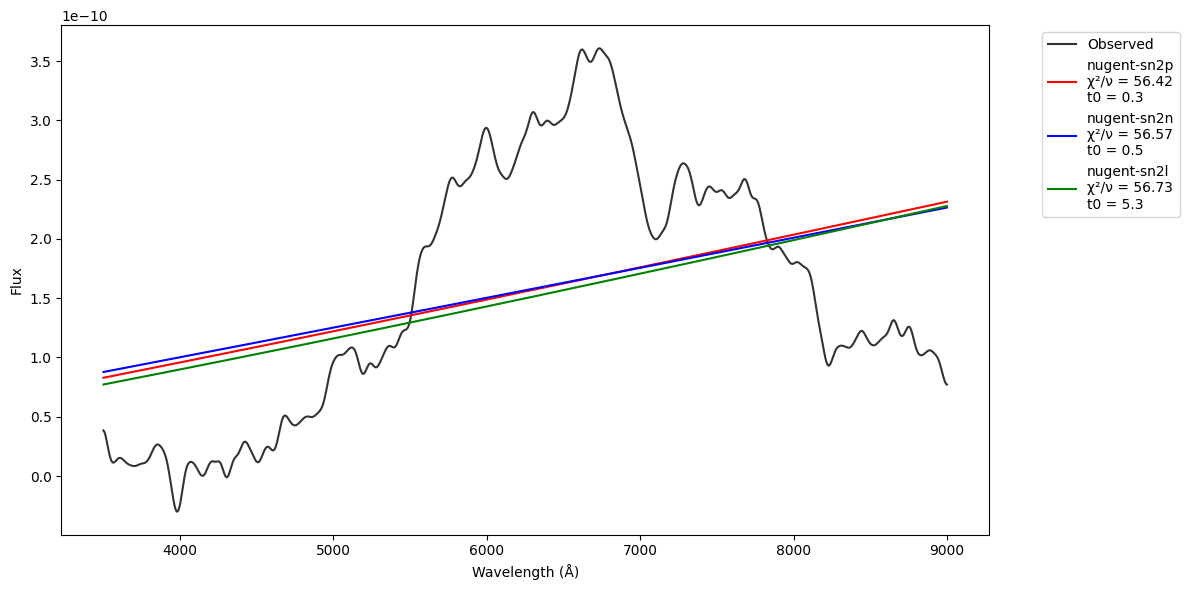

  TARGETID Spectra           SN  SN Type     Z     Phase Frac(SN) Frac(gal)  \
0         Target_1  nugent-sn2p      IIP  0.67  0.348264   0.0002    0.9998   
1         Target_2  nugent-sn2n      IIn  0.67  0.539720   0.0217    0.9783   
2         Target_3  nugent-sn2l  Unknown  0.67  5.323664   0.0005    0.9995   

        χ²/ν  
0  56.423102  
1  56.573435  
2  56.726559  
0.67


In [194]:
model_dict = {
    'salt2': 'Type Ia',
    'salt2-extended': 'Type Ia',
    'salt2-extended-h17': 'Type Ia',
    'salt2-h17': 'Type Ia',
    'salt3': 'Type Ia',
    'salt3-nir': 'Type Ia',
    'hsiao': 'Type Ia',
    'hsiao-subsampled': 'Type Ia',
    'v19-2009bb': 'Type Ia',
    'v19-2013fs-corr': 'Type Ia',
    'v19-2008in': 'Type Ia',
    'v19-2013ej': 'Type Ia',
    'v19-2005bf-corr': 'Type Ia',
    'v19-2009jf': 'Type Ia',
    's11-2005hm': 'Type Ia',
    'v19-2012ap': 'Type Ia',
    'v19-2009dd-corr': 'Type Ia',
    'v19-1999dn': 'Type Ia',
    's11-2005hl': 'Type Ia',
    'v19-2004aw': 'Type Ia',
    'v19-2008aq': 'Type Ia',
    'snf-2011fe': 'Type Ia',
    'v19-2004aw-corr': 'Type Ia',
    'v19-2007pk-corr': 'Type Ia',
    'v19-2013fs': 'Type Ia',
    'v19-2011hs': 'Type Ia',
    'v19-2004gq': 'Type Ia',
    'v19-2012aw': 'Type Ia',
    'v19-2006aj-corr': 'Type Ia',
    'v19-2008ax-corr': 'Type Ia',
    'v19-2007y-corr': 'Type Ia',
    'v19-2007pk': 'Type Ia',
    'v19-1999dn-corr': 'Type Ia',
    'v19-asassn14jb': 'Type Ia',
    'v19-2012au-corr': 'Type Ia',
    's11-2006jo': 'Type Ia',
    'v19-2013am': 'Type Ia',
    'v19-2013ej-corr': 'Type Ia',
    'v19-2004et-corr': 'Type Ia',
    'v19-1994i-corr': 'Type Ia',
    'v19-2010al': 'Type Ia',
    'v19-2016x': 'Type Ia',
    'v19-2012au': 'Type Ia',
    'sugar': 'Type Ia',
    'v19-2004gt': 'Type Ia',
    'v19-2002ap-corr': 'Type Ia',
    'v19-2009ib': 'Type Ia',
    'v19-2005hg': 'Type Ia',
    'v19-2006aa': 'Type Ia',
    'v19-iptf13bvn-corr': 'Type Ia',
    'nugent-sn1b': 'Type Ib',
    'snana-2005hm': 'Type Ib',
    'snana-2007lj': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'snana-2006ix': 'Type Ib',
    'snana-2007lb': 'Type Ib',
    'snana-2005gi': 'Type Ib',
    'snana-2007ll': 'Type Ib',
    'snana-2007og': 'Type Ib',
    'snana-2004hx': 'Type Ib',
    'snana-2006kv': 'Type Ib',
    'snana-2007md': 'Type Ib',
    'snana-2006ns': 'Type Ib',
    'snana-2007pg': 'Type Ib',
    'snana-2006gq': 'Type Ib',
    'snana-2006ep': 'Type Ib',
    'snana-2006iw': 'Type Ib',
    'snana-2006lc': 'Type Ib',
    'snana-2004gv': 'Type Ib',
    'snana-2007ld': 'Type Ib',
    'snana-2006kn': 'Type Ib',
    'snana-2007lx': 'Type Ib',
    'snana-2006fo': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'snana-2006ix': 'Type Ib',
    'snana-2007lb': 'Type Ib',
    'snana-2005gi': 'Type Ib',
    'snana-2007ll': 'Type Ib',
    'snana-2007og': 'Type Ib',
    'snana-2004hx': 'Type Ib',
    'snana-2006kv': 'Type Ib',
    'snana-2007md': 'Type Ib',
    'snana-2006ns': 'Type Ib',
    'snana-2007pg': 'Type Ib',
    'snana-2006gq': 'Type Ib',
    'snana-2006ep': 'Type Ib',
    'snana-2006iw': 'Type Ib',
    'snana-2006lc': 'Type Ib',
    'snana-2004gv': 'Type Ib',
    'snana-2007ld': 'Type Ib',
    'snana-2006kn': 'Type Ib',
    'snana-2007lx': 'Type Ib',
    'snana-2006fo': 'Type Ib',
    'snana-2007nw': 'Type Ib',
    'snana-2006ez': 'Type Ib',
    'snana-2006jo': 'Type Ib',
    'nugent-sn1c': 'Type Ic',
    'snana-2004ib': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'snana-2004fe': 'Type Ic',
    'snana-04d1la': 'Type Ic',
    'snana-2009iz-corr': 'Type Ic',
    'snana-2007ky': 'Type Ic',
    'snana-2004gq': 'Type Ic',
    'snana-2007kw': 'Type Ic',
    'snana-2007nc': 'Type Ic',
    'snana-2007y': 'Type Ic',
    'snana-2007nv': 'Type Ic',
    'snana-2007iz': 'Type Ic',
    'nugent-sn2n': 'Type II',
    'nugent-sn2l': 'Type II',
    'nugent-sn2p': 'Type II',
    'snemo15': 'Type II',
    'snemo2': 'Type II',
    'snemo7': 'Type II',
    'v19-2011hs': 'Type II',
    'v19-2011ht': 'Type II',
    'v19-2011fu': 'Type II',
    'v19-2011bm': 'Type II',
    'v19-2011ei': 'Type II',
    'v19-2011dh': 'Type II',
    'v19-2012ap': 'Type II',
    'v19-2012aw': 'Type II',
    'v19-2012au': 'Type II',
    'v19-2012a': 'Type II',
    'v19-2013fs': 'Type II',
    'v19-2013am': 'Type II',
    'v19-2013ej': 'Type II',
    'v19-2013by': 'Type II',
    'v19-2013ge': 'Type II',
    'v19-2013ab': 'Type II',
    'v19-2013df': 'Type II',
    'v19-2014g': 'Type II',
    'v19-2016x': 'Type II',
    'v19-2016gkg': 'Type II',
    'v19-2016bkv': 'Type II',
    'v19-2011bm-corr': 'Type II',
    'v19-2011ei-corr': 'Type II',
    'v19-2011fu-corr': 'Type II',
    'v19-2011ht-corr': 'Type II',
    'v19-2011dh-corr': 'Type II',
    'v19-2011hs-corr': 'Type II',
    'v19-2012ap-corr': 'Type II',
    'v19-2012aw-corr': 'Type II',
    'v19-2012au-corr': 'Type II',
    'v19-2012a-corr': 'Type II',
    'v19-2013fs-corr': 'Type II',
    'v19-2013am-corr': 'Type II',
    'v19-2013ej-corr': 'Type II',
    'v19-2013by-corr': 'Type II',
    'v19-2013ge-corr': 'Type II',
    'v19-2013ab-corr': 'Type II',
    'v19-2013df-corr': 'Type II',
    'v19-2014g-corr': 'Type II',
    'v19-2016x-corr': 'Type II',
    'v19-2016gkg-corr': 'Type II',
    'v19-2016bkv-corr': 'Type II',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN',
    'snana-2007ms': 'SLSN',
    'snana-2007ny': 'SLSN',
    'snana-2007nr': 'SLSN',
    'snana-2007lz': 'SLSN',
    'snana-2007ld': 'SLSN',
    'snana-2007lx': 'SLSN'
}


import numpy as np
import sncosmo
from scipy.optimize import minimize, differential_evolution
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux)
        self.flux_error = np.ones_like(flux) * 0.1 * np.median(flux)
        self.redshift = redshift

def get_phase_weight(t0, sigma=10.0):
    """
    Gaussian weight centered at t0=0 (maximum light)
    Returns 1.0 at t0=0 and decreases as |t0| increases
    """
    return np.exp(-0.5 * (t0 / sigma) ** 2)

def chi2_with_prior(params, model, wavelength, flux, flux_error, prior_strength=1.0, sigma_prior=10.0):
    """Chi2 function with phase prior that favors t0=0"""
    amp, t0, gal_norm, gal_index = params

    # Calculate phase weight (1.0 at t0=0, decreasing as |t0| increases)
    phase_weight = get_phase_weight(t0, sigma=sigma_prior)

    # Original chi2 calculation (your working method)
    model.set(amplitude=amp, t0=t0)
    model_flux = model.flux(0, wavelength)
    galaxy_flux = gal_norm * (wavelength / 5000.0)**gal_index
    total_flux = model_flux + galaxy_flux
    residuals = (flux - total_flux) / flux_error
    n_data = len(wavelength)
    dof = n_data - 4
    chi2_val = np.sum(residuals**2)

    # Calculate proper Bayesian prior penalty
    # Convert prior weight to penalty using -2*log(prior) formulation
    # This gives the exact penalty structure you specified:
    # t0=0: penalty = 0 (prior weight = 1.0)
    # t0=±10: penalty ≈ 0.98 * prior_strength * dof (prior weight = 0.61)
    # t0=±20: penalty ≈ 3.67 * prior_strength * dof (prior weight = 0.14)
    # t0=±30: penalty ≈ 9.21 * prior_strength * dof (prior weight = 0.01)
    prior_penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength * dof

    # Combine chi2 with prior penalty
    combined_chi2 = chi2_val + prior_penalty

    return (combined_chi2) / (dof)  # Your original chi2 scaling method

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # Initial guesses - start at maximum light due to strong prior
        amp_guess = np.median(spec.flux) * 100
        t0_guess = 0.0  # Start exactly at peak due to strong prior
        gal_norm_guess = np.median(spec.flux)
        gal_index_guess = -1.0

        # Limit phase search range based on prior width
        phase_range = min(50, sigma_prior * 3)

        result = minimize(
            chi2_with_prior,
            x0=[amp_guess, t0_guess, gal_norm_guess, gal_index_guess],
            args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior),
            bounds=[(1e-5, 1e10), (-phase_range, phase_range), (0, np.max(spec.flux)), (-5, 5)],
            method='L-BFGS-B'
        )

        # If optimization fails, try differential evolution
        if not result.success or result.fun > 1000:
            bounds = [(1e-5, 1e10), (-phase_range, phase_range), (0, np.max(spec.flux)), (-5, 5)]
            result_de = differential_evolution(
                chi2_with_prior,
                bounds,
                args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior),
                maxiter=50,
                popsize=10,
                polish=True
            )
            if result_de.fun < result.fun:
                result = result_de

        # Calculate final chi2 without the prior for reporting (your original method)
        model.set(amplitude=result.x[0], t0=result.x[1])
        model_flux = model.flux(0, spec.wavelength)
        galaxy_flux = result.x[2] * (spec.wavelength / 5000.0)**result.x[3]
        residuals = (spec.flux - model_flux - galaxy_flux) / spec.flux_error
        chi2_val = np.sum(residuals**2)
        n_data = len(spec.wavelength)
        reduced_chi2 = chi2_val / (n_data - 4)  # Your original chi2 scaling

        return {
            'model_name': model_name,
            'amplitude': result.x[0],
            't0': result.x[1],
            'galaxy_norm': result.x[2],
            'galaxy_index': result.x[3],
            'reduced_chi2': reduced_chi2,
            'model': model,
            'success': result.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=3, prior_strength=1.0, sigma_prior=10.0):
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
              for name in tqdm(model_list, desc="Fitting models")]
    return sorted([r for r in results if r['success']], key=lambda x: x['reduced_chi2'])[:n_best]

def plot_results(spec, best_models):
    plt.figure(figsize=(12, 6))
    plt.plot(spec.wavelength, spec.flux, 'k-', label='Observed', alpha=0.8)
    colors = ['r', 'b', 'g', 'm', 'c']
    for i, result in enumerate(best_models):
        model = result['model']
        model.set(amplitude=result['amplitude'], t0=result['t0'])
        model_flux = model.flux(0, spec.wavelength)
        galaxy_flux = result['galaxy_norm'] * (spec.wavelength / 5000.0)**result['galaxy_index']
        plt.plot(spec.wavelength, model_flux + galaxy_flux, '-', color=colors[i % len(colors)],
                label=f"{result['model_name']}\nχ²/ν = {result['reduced_chi2']:.2f}\nt0 = {result['t0']:.1f}")
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Flux')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_bayesian_prior(sigma_prior=10.0, prior_strength=1.0):
    """Visualize the Bayesian prior and exact penalty structure"""
    t0_values = np.linspace(-60, 60, 1000)
    prior_values = [get_phase_weight(t0, sigma=sigma_prior) for t0 in t0_values]

    # Calculate exact penalties
    penalties = [-2.0 * np.log(p + 1e-10) * prior_strength for p in prior_values]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot prior weights
    ax1.plot(t0_values, prior_values, 'b-', linewidth=2, label=f'Gaussian Prior (σ={sigma_prior} days)')
    ax1.axvline(0, color='r', linestyle='--', alpha=0.7, label='Maximum Light (t0=0)')
    ax1.axhline(1.0, color='g', linestyle=':', alpha=0.5, label='100% weight')
    ax1.axhline(0.61, color='orange', linestyle=':', alpha=0.5, label='61% weight (±10 days)')
    ax1.axhline(0.14, color='purple', linestyle=':', alpha=0.5, label='14% weight (±20 days)')
    ax1.axhline(0.01, color='brown', linestyle=':', alpha=0.5, label='1% weight (±30 days)')
    ax1.set_xlabel('Phase (days)')
    ax1.set_ylabel('Prior Weight')
    ax1.set_title('Bayesian Prior: Strong Preference for Maximum Light')
    ax1.set_ylim([0, 1.1])
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot penalties
    ax2.plot(t0_values, penalties, 'r-', linewidth=2, label=f'Penalty (strength={prior_strength})')
    ax2.axvline(0, color='g', linestyle='--', alpha=0.7, label='No penalty at t0=0')
    ax2.set_xlabel('Phase (days)')
    ax2.set_ylabel('Penalty (added to χ²)')
    ax2.set_title('Exact Penalty Structure vs Phase')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Print exact penalty values
    print(f"\nExact Penalty Structure (σ={sigma_prior} days, strength={prior_strength}):")
    print(f"  t0=0:     penalty = {-2.0 * np.log(get_phase_weight(0, sigma_prior) + 1e-10) * prior_strength:.3f}")
    print(f"  t0=±{sigma_prior}: penalty = {-2.0 * np.log(get_phase_weight(sigma_prior, sigma_prior) + 1e-10) * prior_strength:.3f}")
    print(f"  t0=±{2*sigma_prior}: penalty = {-2.0 * np.log(get_phase_weight(2*sigma_prior, sigma_prior) + 1e-10) * prior_strength:.3f}")
    print(f"  t0=±{3*sigma_prior}: penalty = {-2.0 * np.log(get_phase_weight(3*sigma_prior, sigma_prior) + 1e-10) * prior_strength:.3f}")

MODEL_LIST = list(model_dict.keys())

def create_sn_galaxy_table(best_models, spec, num_models=10):
    data = []
    for i, model in enumerate(best_models[:num_models], 1):
        sn_type = get_Type(model['model_name']) or 'Unknown'
        model_obj = model['model']
        model_obj.set(amplitude=model['amplitude'], t0=model['t0'])
        model_flux = model_obj.flux(0, spec.wavelength)
        total_flux = np.trapz(spec.flux, spec.wavelength)
        sn_flux = np.trapz(model_flux, spec.wavelength)
        sn_fraction = sn_flux / total_flux if total_flux > 0 else 0
        gal_fraction = 1 - sn_fraction
        data.append([
            f"Target_{i}",  # Placeholder
            model['model_name'],
            sn_type,
            spec.redshift,
            model['t0'],
            f"{sn_fraction:.4f}",
            f"{gal_fraction:.4f}",
            model['reduced_chi2']
        ])
    columns = ['TARGETID Spectra', 'SN', 'SN Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(gal)', 'χ²/ν']
    return pd.DataFrame(data, columns=columns)

# Load the CSV file
df = pd.read_csv('/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/supernova_model_types.csv')

# Function to get redshift for a given model
def get_Type(model_name):
    try:
        Type = df.loc[df['Model'] == model_name, 'Type'].values[0]
        return Type
    except IndexError:
        return None

# Create your spectrum object (replace with your data)
your_spectrum = Spectrum(
    wavelength=wavelength,  # Your wavelength data from sparcClient
    flux=smoothed_flux,             # Your flux data from sparcClient
    redshift= redshift     # Set your known redshift here
)

# Find the best-fitting models with strong prior
best_models = find_best_models(
    your_spectrum,
    MODEL_LIST,
    z=your_spectrum.redshift,
    prior_strength=1.0,  # Use 100% prior strength
    sigma_prior=10.0
)

model_name = 'v19-2009bb'  # Your known model name
Type = get_Type(model_name)
print(f"Type for {model_name}: {Type}")

# Display results
print("\nBest-fitting models:")
for i, model in enumerate(best_models, 1):
    Type = get_Type(model['model_name'])
    print(f"{i}. {model['model_name']} ({Type}):")
    print(f"   χ²/ν = {model['reduced_chi2']:.2f}")
    print(f"   t0 = {model['t0']:.1f} days")
    print(f"   amplitude = {model['amplitude']:.2e}")

# Plot the results
plot_results(your_spectrum, best_models)

# After finding best_models, create and display the table
table = create_sn_galaxy_table(best_models, your_spectrum)
print(table)
print(your_spectrum.redshift)



Scanning Templates:   0%|          | 0/213 [00:00<?, ?it/s]

Scanning Templates:   0%|          | 1/213 [00:00<01:10,  3.00it/s]

Scanning Templates:   1%|          | 2/213 [00:00<01:06,  3.16it/s]

Scanning Templates:   1%|▏         | 3/213 [00:00<00:59,  3.54it/s]

Scanning Templates:  16%|█▌        | 34/213 [00:14<00:12, 14.73it/s]

Scanning Templates:   3%|▎         | 6/213 [00:01<00:28,  7.32it/s]

Scanning Templates:   4%|▍         | 8/213 [00:01<00:24,  8.44it/s]

Scanning Templates:   4%|▍         | 9/213 [00:01<00:26,  7.77it/s]

Scanning Templates:   5%|▌         | 11/213 [00:01<00:23,  8.67it/s]

Scanning Templates:   6%|▌         | 13/213 [00:01<00:20,  9.64it/s]

Scanning Templates:   7%|▋         | 15/213 [00:02<00:20,  9.73it/s]

Scanning Templates:   8%|▊         | 17/213 [00:02<00:17, 11.12it/s]

Scanning Templates:   9%|▉         | 20/213 [00:02<00:16, 11.89it/s]

Scanning Templates:  10%|█         | 22/213 [00:02<00:14, 13.41it/s]

Scanning Templates:  11%|█▏      


--- FINAL CLASSIFICATION REPORT ---
      ID     SN Template Type        Z  Phase Frac(SN) Frac(Gal)  χ²/ν
Target_1 v19-2009kr-corr   II 0.136358 -18.16   0.6856    0.3144 0.642
Target_2      v19-2009kr   II 0.136358 -18.16   0.6856    0.3144 0.642
Target_3    snana-2006jo   Ib 0.136358  -7.42   0.5499    0.4501 0.742
Target_4      v19-2008fq   II 0.136358  -6.41   0.8389    0.1611 0.765
Target_5    snana-2004gv   Ib 0.136358 -12.27   0.5820    0.4180 0.797


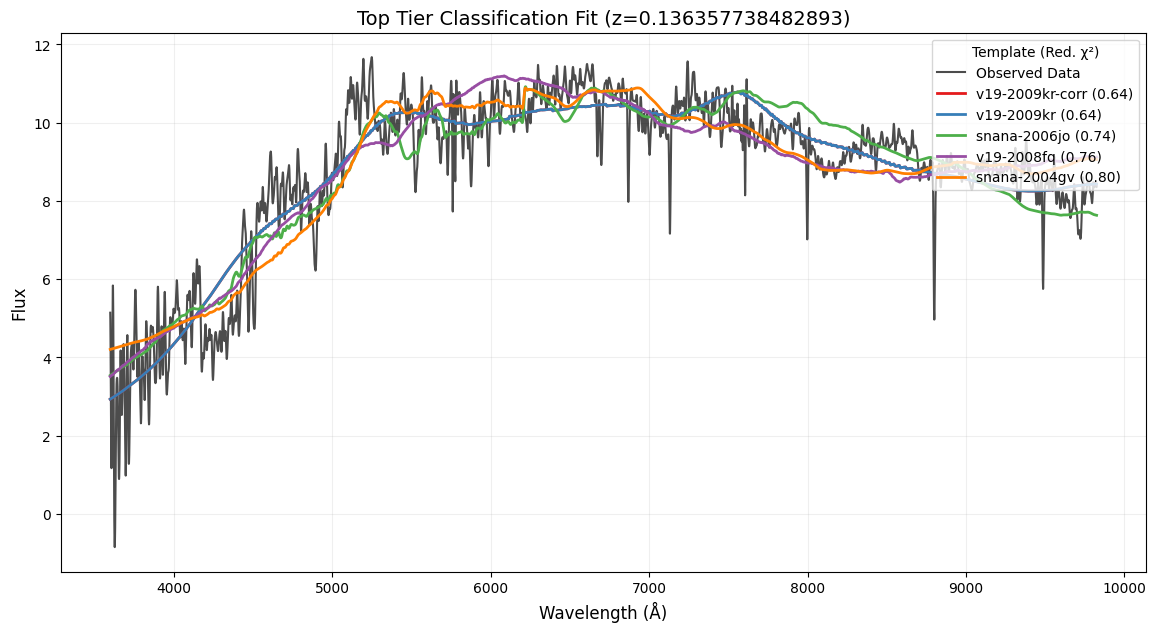

In [269]:
import numpy as np
import sncosmo
from scipy.optimize import minimize, differential_evolution
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Suppress sncosmo/scipy warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. THE COMPLETE MODEL DICTIONARY
model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib/Ic', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib/Ic', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# 2. CORE CLASSES AND FUNCTIONS
class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        # NORMALIZATION: Crucial for top-tier numerical convergence
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux) / self.norm_factor
        # 10% Relative error on normalized flux
        self.flux_error = np.ones_like(self.flux) * 0.1
        self.redshift = redshift

def chi2_objective(params, model, wavelength, flux, flux_error, prior_strength, sigma_prior):
    """Refined Chi2 + Prior Objective"""
    amp, t0, gal_norm, gal_index = params
    try:
        model.set(amplitude=amp, t0=t0)
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0)**gal_index
        total = m_flux + g_flux

        chi2 = np.sum(((flux - total) / flux_error)**2)
        dof = len(wavelength) - 4

        # Bayesian prior on phase (favors t0=0)
        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength

        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # Initial guesses in normalized space (1.0)
        x0 = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]

        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior),
                       bounds=bounds, method='L-BFGS-B')

        # Compute "Pure" Reduced Chi2 (for honest reporting)
        model.set(amplitude=res.x[0], t0=res.x[1])
        m_f = model.flux(0, spec.wavelength)
        g_f = res.x[2] * (spec.wavelength / 5000.0)**res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error)**2)
        red_chi2 = pure_chi2 / (len(spec.wavelength) - 4)

        return {
            'model_name': model_name,
            'amplitude': res.x[0] * spec.norm_factor,  # Denormalized
            't0': res.x[1],
            'galaxy_norm': res.x[2] * spec.norm_factor, # Denormalized
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model': model,
            'success': res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5, prior_strength=1.0, sigma_prior=10.0):
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
              for name in tqdm(model_list, desc="Scanning Templates")]
    # Filter only successes and sort by pure physical chi2
    valid = [r for r in results if r['success']]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

# 3. UTILITIES & DISPLAY
def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])
        # Integrate flux to find fractions
        sn_flux_int = np.trapz(m_obj.flux(0, spec.wavelength), spec.wavelength)
        gal_flux_int = np.trapz(m['galaxy_norm'] * (spec.wavelength / 5000.0)**m['galaxy_index'], spec.wavelength)
        total = sn_flux_int + gal_flux_int

        data.append([
            f"Target_{i}", m['model_name'], model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}", f"{(sn_flux_int/total):.4f}",
            f"{(gal_flux_int/total):.4f}", f"{m['reduced_chi2']:.3f}"
        ])
    return pd.DataFrame(data, columns=['ID', 'SN Template', 'Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'])

def plot_top_tier(spec, best_models):
    plt.figure(figsize=(14, 7))
    # Plot original data (denormalized)
    orig_flux = spec.flux * spec.norm_factor
    plt.plot(spec.wavelength, orig_flux, 'k-', label='Observed Data', alpha=0.7, lw=1.5)

    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])
        total_model = m.flux(0, spec.wavelength) + (res['galaxy_norm'] * (spec.wavelength/5000.0)**res['galaxy_index'])
        plt.plot(spec.wavelength, total_model, color=colors[i],
                 label=f"{res['model_name']} ({res['reduced_chi2']:.2f})", lw=2)

    plt.xlabel('Wavelength (Å)', fontsize=12)
    plt.ylabel('Flux', fontsize=12)
    plt.title(f'Top Tier Classification Fit (z={spec.redshift})', fontsize=14)
    plt.legend(title="Template (Red. χ²)", loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

# 4. EXECUTION
# Assuming 'wavelength', 'smoothed_flux', and 'redshift' are already defined in your environment
your_spectrum = Spectrum(wavelength, smoothed_flux, redshift)

best_results = find_best_models(your_spectrum, list(model_dict.keys()),
                               z=your_spectrum.redshift, n_best=5)

results_table = create_sn_galaxy_table(best_results, your_spectrum)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(results_table.to_string(index=False))
plot_top_tier(your_spectrum, best_results)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# SPECTRUM CLASS
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, flux_error=None, redshift=0.05):
        self.wavelength = np.array(wavelength, dtype=float)
        raw_flux = np.array(flux, dtype=float)

        # Normalize by median of POSITIVE flux only
        pos_mask = raw_flux > 0
        self.norm_factor = np.median(raw_flux[pos_mask]) if pos_mask.any() else 1.0

        self.flux = raw_flux / self.norm_factor
        self.redshift = redshift

        if flux_error is not None:
            # Use real errors if provided — normalize same way
            self.flux_error = np.array(flux_error, dtype=float) / self.norm_factor
            # Safety floor: errors must be positive
            self.flux_error = np.clip(self.flux_error, 1e-6, None)
        else:
            # Estimate local noise via rolling MAD (more robust than std)
            # This correctly gives higher errors in noisy regions
            half_win = 15
            n = len(self.flux)
            noise = np.empty(n)
            for i in range(n):
                lo = max(0, i - half_win)
                hi = min(n, i + half_win)
                window_data = self.flux[lo:hi]
                # MAD scaled to approximate std
                noise[i] = np.median(np.abs(window_data - np.median(window_data))) * 1.4826
            # Floor at 0.5% of median flux to avoid divide-by-zero
            self.flux_error = np.clip(noise, 0.005, None)


# ============================================================
# OBJECTIVE FUNCTION
# ============================================================

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior, t0_center):
    amp, t0, gal_norm, gal_index = params

    try:
        model.set(amplitude=amp, t0=t0)
        sn_flux = model.flux(0, wavelength)

        # FAULT 5 FIX: Reject if model returns non-finite values
        if not np.all(np.isfinite(sn_flux)):
            return 1e15

        # FAULT 5 FIX: Reject if model is zero everywhere (outside wavelength range)
        if np.all(sn_flux == 0):
            return 1e15

        gal_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        total_flux = sn_flux + gal_flux

        chi2 = np.sum(((flux - total_flux) / flux_error) ** 2)

        # FAULT 2 FIX: Prior centered on t0_center, not hardcoded 0
        # Scale prior_strength relative to number of data points
        # so it's meaningful regardless of spectrum size
        n_data = len(flux)
        scaled_prior = prior_strength * n_data * ((t0 - t0_center) / sigma_prior) ** 2

        return chi2 + scaled_prior

    except Exception:
        return 1e15


# ============================================================
# FITTING ROUTINE
# ============================================================

def optimize_fit(spec, model_name, z,
                 prior_strength=0.01,    # 1% of data weight per sigma
                 sigma_prior=20.0,       # broad — 20 day sigma
                 t0_center=0.0,
                 t0_range=(-25, 50)):

    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # FAULT 5 FIX: Check model wavelength coverage before fitting
        try:
            model_wave_min = model.minwave()
            model_wave_max = model.maxwave()
            overlap = np.sum(
                (spec.wavelength >= model_wave_min) &
                (spec.wavelength <= model_wave_max)
            )
            # Require at least 50% of wavelength range to be covered
            if overlap < 0.5 * len(spec.wavelength):
                return {'model_name': model_name, 'success': False,
                        'error': 'Insufficient wavelength coverage'}
        except Exception:
            pass  # Some models don't expose minwave/maxwave — proceed anyway

        # FAULT 4 FIX: Tighter galaxy bounds so it cannot swamp the SN
        bounds = [
            (1e-8, 1e4),           # amplitude: wide but finite
            (t0_range[0], t0_range[1]),  # t0: physically motivated range
            (0.0, 0.5),            # gal_norm: max 50% of median SN flux
            (-2.0, 2.0)            # gal_index: realistic galaxy power law
        ]

        best_result = None
        best_fval = np.inf

        # FAULT 3 FIX: Multi-start grid across t0 AND amplitude
        t0_starts = np.linspace(t0_range[0], t0_range[1], 8)
        amp_starts = [0.01, 0.1, 1.0, 10.0]

        for t0_s in t0_starts:
            for amp_s in amp_starts:
                x0 = [amp_s, t0_s, 0.1, 0.0]

                try:
                    res = minimize(
                        chi2_objective,
                        x0=x0,
                        args=(model, spec.wavelength, spec.flux,
                              spec.flux_error, prior_strength,
                              sigma_prior, t0_center),
                        bounds=bounds,
                        method='L-BFGS-B',
                        options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8}
                    )

                    # FAULT 6 FIX: Accept result if function value improved,
                    # regardless of res.success flag
                    if res.fun < best_fval:
                        best_fval = res.fun
                        best_result = res

                except Exception:
                    continue

        if best_result is None:
            return {'model_name': model_name, 'success': False}

        amp_opt, t0_opt, gal_norm_opt, gal_index_opt = best_result.x

        # Compute PURE reduced chi² with NO prior
        model.set(amplitude=amp_opt, t0=t0_opt)
        sn_flux = model.flux(0, spec.wavelength)

        # FAULT 5 FIX: Guard against zero/nan model flux in chi² computation
        if not np.all(np.isfinite(sn_flux)) or np.all(sn_flux == 0):
            return {'model_name': model_name, 'success': False,
                    'error': 'Model flux invalid at best-fit params'}

        gal_flux = gal_norm_opt * (spec.wavelength / 5000.0) ** gal_index_opt
        residuals = spec.flux - (sn_flux + gal_flux)
        pure_chi2 = np.sum((residuals / spec.flux_error) ** 2)

        dof = max(len(spec.wavelength) - 4, 1)
        red_chi2 = pure_chi2 / dof

        return {
            'model_name':   model_name,
            'amplitude':    amp_opt,
            't0':           t0_opt,
            'galaxy_norm':  gal_norm_opt,
            'galaxy_index': gal_index_opt,
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      True
        }

    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}


# ============================================================
# MODEL SEARCH
# ============================================================

def find_best_models(spec, model_list,
                     z=0.05,
                     n_best=5,
                     prior_strength=0.01,
                     sigma_prior=20.0,
                     t0_center=0.0,
                     t0_range=(-25, 50)):

    results = [
        optimize_fit(spec, name, z,
                     prior_strength=prior_strength,
                     sigma_prior=sigma_prior,
                     t0_center=t0_center,
                     t0_range=t0_range)
        for name in tqdm(model_list, desc="Scanning Templates")
    ]

    valid = [r for r in results if r['success']]

    if not valid:
        print("WARNING: No successful fits. Check redshift and wavelength coverage.")
        return []

    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]


# ============================================================
# SN / GALAXY FRACTION TABLE
# ============================================================

def create_sn_galaxy_table(best_models, spec):
    data = []

    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])

        sn_flux  = m_obj.flux(0, spec.wavelength)
        gal_flux = m['galaxy_norm'] * (spec.wavelength / 5000.0) ** m['galaxy_index']

        sn_flux_int  = np.trapz(np.maximum(sn_flux, 0),  spec.wavelength)  # FAULT 8 FIX
        gal_flux_int = np.trapz(np.maximum(gal_flux, 0), spec.wavelength)  # clip negatives

        total = sn_flux_int + gal_flux_int

        # FAULT 8 FIX: Guard against zero total
        if total <= 0:
            sn_frac = gal_frac = float('nan')
        else:
            sn_frac  = sn_flux_int  / total
            gal_frac = gal_flux_int / total

        data.append([
            f"Target_{i}",
            m['model_name'],
            model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift,
            f"{m['t0']:.2f}",
            f"{sn_frac:.4f}",
            f"{gal_frac:.4f}",
            f"{m['reduced_chi2']:.3f}"
        ])

    return pd.DataFrame(data, columns=[
        'ID', 'SN Template', 'Type', 'Z',
        'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'
    ])


# ============================================================
# PLOTTING
# ============================================================

def plot_top_tier(spec, best_models):
    fig, axes = plt.subplots(len(best_models), 1,
                             figsize=(14, 4 * len(best_models)),
                             sharex=True)

    if len(best_models) == 1:
        axes = [axes]

    observed_flux = spec.flux * spec.norm_factor

    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

    for i, (res, ax) in enumerate(zip(best_models, axes)):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])

        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']

        # Plot in original (denormalized) flux units
        ax.plot(spec.wavelength, observed_flux,
                'k-', lw=1.2, label='Observed', alpha=0.8)
        ax.plot(spec.wavelength, (sn_flux + gal_flux) * spec.norm_factor,
                color=colors[i], lw=2,
                label=f"Total model  χ²/ν={res['reduced_chi2']:.2f}")
        ax.plot(spec.wavelength, sn_flux * spec.norm_factor,
                color=colors[i], lw=1, ls='--', alpha=0.6, label='SN only')
        ax.plot(spec.wavelength, gal_flux * spec.norm_factor,
                color='gray', lw=1, ls=':', alpha=0.6, label='Galaxy only')

        ax.set_title(
            f"{res['model_name']}  |  Type: {model_dict.get(res['model_name'], '?')}"
            f"  |  Phase: {res['t0']:.1f}d  |  z={spec.redshift}",
            fontsize=10
        )
        ax.set_ylabel("Flux")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Wavelength (Å)")
    plt.tight_layout()
    plt.show()


# ============================================================
# EXECUTION
# ============================================================

your_spectrum = Spectrum(
    wavelength,
    smoothed_flux,
    flux_error=None,   # Pass your real errors here if you have them
    redshift=redshift
)

best_results = find_best_models(
    your_spectrum,
    list(model_dict.keys()),
    z=your_spectrum.redshift,
    n_best=5,
    prior_strength=0.01,   # Weak prior — data drives the fit
    sigma_prior=20.0,      # 20-day sigma — broad enough to not bias
    t0_center=0.0,         # Change if you have external phase info
    t0_range=(-25, 50)     # Adjust if you know it's early or late
)

if best_results:
    results_table = create_sn_galaxy_table(best_results, your_spectrum)
    print("\n--- FINAL CLASSIFICATION REPORT ---")
    print(results_table.to_string(index=False))
    plot_top_tier(your_spectrum, best_results)


# Real SUPERFIT


Running 10 trials  |  pool=209 templates  |  3 optimizer starts



Trials: 100%|██████████| 10/10 [01:01<00:00,  6.11s/it]



Saved → confusion_results.csv


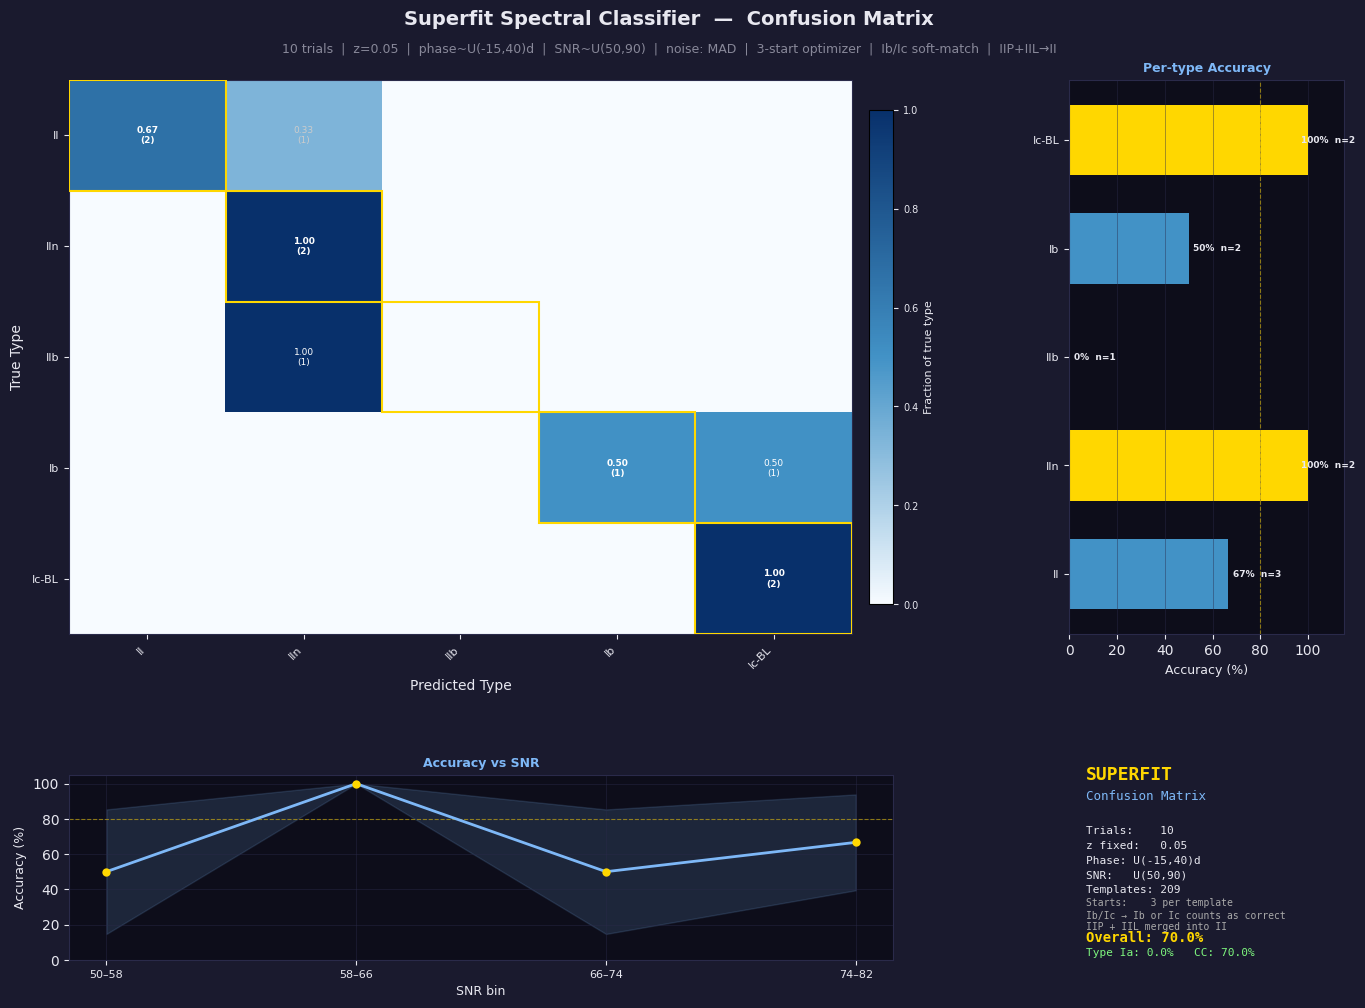

Saved → confusion_matrix.png


In [3]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import random
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. MODEL DICTIONARY
# ============================================================

model_dict = {
    # IIP, IIL, and II all merged into 'II':
    # light-curve shape (plateau vs. linear) is not a spectral feature,
    # so separating them spectrally is physically unmotivated.
    # IIn kept separate — narrow emission lines ARE a spectral feature.
    'v19-2014g': 'II', 's11-2005lc': 'II', 'snana-2004ib': 'II', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'II', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'II', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'II',
    'v19-1999em': 'II', 'v19-2012aw': 'II', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'II', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'II', 'snana-2005gi': 'II', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'II', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'II', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'II', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'II', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'II', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'II', 'v19-2009dd': 'II',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'II',
    'snana-2007nw': 'II', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'II', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'II', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'II',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'II', 'v19-2007pk': 'II', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'II', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'II', 'snana-2007ld': 'II',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'II',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'II', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'II', 'snana-2006ez': 'II',
    'v19-2013ej-corr': 'II', 'snana-2007pg': 'II', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'II', 'whalen-z25g': 'PopIII-II', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'II', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'II', 'v19-1994i': 'Ic', 'v19-2009n': 'II',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'II', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'II', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'II', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'II', 'snemo2': 'Ia', 's11-2004hx': 'II', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'II', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'II', 'v19-2013am': 'II', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'II', 'v19-2009ib-corr': 'II', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'II',
    'salt2-h17': 'Ia', 'snana-2007ms': 'II', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'II',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# ============================================================
# 2. SOFT-MATCH CORRECTNESS
# ============================================================

# Ib/Ic is an inherently ambiguous class — spectra that don't clearly
# show helium (Ib) or lack thereof (Ic). Predicting Ib or Ic for a
# true Ib/Ic is a physically reasonable resolution, not a mistake.
def is_correct(true_type, predicted_type):
    if true_type == predicted_type:
        return True
    if true_type == 'Ib/Ic' and predicted_type in ('Ib', 'Ic'):
        return True
    return False

# ============================================================
# 3. AMPLITUDE PARAMETER HANDLING
# ============================================================

SALT_SOURCES   = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                  'salt3', 'salt3-nir'}
BROKEN_SOURCES = {'mlcs2k2'}

def _amp_param(model_name, model_obj=None):
    if model_name in SALT_SOURCES:
        return 'x0'
    if model_obj is not None:
        pnames = list(model_obj.param_names)
        if 'amplitude' in pnames:
            return 'amplitude'
        candidates = [p for p in pnames if p not in ('z', 't0')]
        if candidates:
            return candidates[0]
    return 'amplitude'

def _extra_params(model_name, pnames):
    extra = {}
    if model_name in SALT_SOURCES:
        if 'x1' in pnames: extra['x1'] = 0.0
        if 'c'  in pnames: extra['c']  = 0.0
    for p in pnames:
        if p not in ('z', 't0') and p not in extra:
            extra[p] = 0.0
    return extra

# ============================================================
# 4. SPECTRUM CLASS
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.wavelength  = np.array(wavelength, dtype=float)
        flux             = np.array(flux, dtype=float)
        pos              = flux[flux > np.percentile(flux, 10)]
        self.norm_factor = float(np.median(pos)) if len(pos) > 0 else 1.0
        self.flux        = flux / self.norm_factor
        self.redshift    = redshift
        # MAD noise estimator — correct chi2 at all SNRs (flat 0.1 was wrong)
        if len(self.flux) > 4:
            diffs = np.diff(self.flux)
            mad   = np.median(np.abs(diffs - np.median(diffs)))
            sigma = max(mad * 1.4826 / np.sqrt(2), 1e-4)
        else:
            sigma = 0.1
        self.flux_error = np.full_like(self.flux, sigma)

# ============================================================
# 5. CLASSIFIER  (3-start optimizer)
# ============================================================

# Three phase starting points: pre-max, max, post-max.
# Single t0=0 start misses global minimum for off-peak spectra,
# letting wrong templates win → flat SNR curve.
T0_STARTS = [-12.0, 0.0, 20.0]

def chi2_objective(params, model, wavelength, flux, flux_error, model_name):
    amp, t0, gal_norm, gal_index = params
    try:
        ap = _amp_param(model_name, model)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        chi2   = np.sum(((flux - (m_flux + g_flux)) / flux_error) ** 2)
        return chi2 / max(len(wavelength) - 4, 1)
    except Exception:
        return 1e15

def optimize_fit(spec, model_name, z):
    try:
        model  = sncosmo.Model(source=model_name)
        pnames = list(model.param_names)
        model.set(z=z)
        ap   = _amp_param(model_name, model)
        init = _extra_params(model_name, pnames)
        init.pop(ap, None)
        try: model.set(**init)
        except Exception: pass

        best_res, best_chi2 = None, np.inf
        for t0_start in T0_STARTS:
            try:
                res = minimize(
                    chi2_objective,
                    x0      = [1.0, t0_start, 0.2, -1.0],
                    bounds  = [(1e-6, 100.0), (-30.0, 50.0),
                               (0.0, 1.0),    (-3.0, 3.0)],  # gal_norm ≤ 1 prevents galaxy swamping SN
                    args    = (model, spec.wavelength, spec.flux,
                               spec.flux_error, model_name),
                    method  = 'L-BFGS-B',
                    options = {'maxiter': 300, 'ftol': 1e-9},
                )
                if res.fun < best_chi2:
                    best_chi2 = res.fun
                    best_res  = res
            except Exception:
                continue

        if best_res is None:
            return {'model_name': model_name, 'success': False}

        return {
            'model_name':   model_name,
            'amplitude':    best_res.x[0] * spec.norm_factor,
            't0':           best_res.x[1],
            'galaxy_norm':  best_res.x[2] * spec.norm_factor,
            'galaxy_index': best_res.x[3],
            'reduced_chi2': best_chi2,
            'model':        model,
            'success':      True,
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5):
    results = [optimize_fit(spec, n, z) for n in model_list]
    valid   = [r for r in results if r.get('success')]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

# ============================================================
# 6. REBINNING
# ============================================================

def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux,       dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    ww, ff = [], []
    for i in range(len(edges) - 1):
        m = (wavelength >= edges[i]) & (wavelength < edges[i+1])
        if m.sum() > 0:
            ww.append(0.5 * (edges[i] + edges[i+1]))
            ff.append(np.mean(flux[m]))
    return np.array(ww), np.array(ff)

# ============================================================
# 7. CONFIGURATION
# ============================================================

Z            = 0.05
N_TRIALS     = 10
SNR_RANGE    = (50, 90)
PHASE_RANGE  = (-40, 40)
WAVE_RANGE   = (4000, 9000)
N_WAVE       = 2000
BIN_WIDTH_AA = 10.0
SEED         = random.randint(1,10002903)

# ============================================================
# 8. SIMULATE ONE SPECTRUM
# ============================================================

def simulate_one(model_name, z, phase, snr, wave_range, n_wave, bin_width_aa):
    wave = np.linspace(wave_range[0], wave_range[1], n_wave)
    try:
        model  = sncosmo.Model(source=model_name)
        pnames = list(model.param_names)
        model.set(z=z)
        ap    = _amp_param(model_name, model)
        extra = _extra_params(model_name, pnames)
        extra.pop(ap, None)
        try:
            t_min = float(model.mintime())
            t_max = float(model.maxtime())
            if (t_max - t_min) < 1.0:
                # Single-phase template (nugent-sn91bg/91t/superc) —
                # only valid at max light. Always simulate at t0=0 so these
                # templates get a fair shot rather than zero flux at random phase.
                phase = 0.0
            else:
                phase = float(np.clip(phase, t_min + 0.01, t_max - 0.01))
        except Exception:
            pass
        model.set(**extra)
        model.set(**{ap: 1.0, 't0': phase})
        flux_clean = model.flux(0, wave)
    except Exception:
        return None, None

    if not np.any(np.isfinite(flux_clean)) or np.sum(flux_clean > 0) < 10:
        return None, None
    flux_clean = np.maximum(flux_clean, 0)
    med = np.median(flux_clean[flux_clean > 0])
    if med <= 0:
        return None, None
    flux_clean /= med
    flux_noisy = flux_clean + np.random.normal(0, 1.0 / snr, n_wave)
    return rebin_spectrum(wave, flux_noisy, bin_width_aa)

# ============================================================
# 9. RUN TRIALS
# ============================================================

def run_confusion_matrix(
    model_list   = None,
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED,
):
    if model_list is None:
        model_list = list(model_dict.keys())
    model_list = [m for m in model_list if m not in BROKEN_SOURCES]

    np.random.seed(seed)
    records = []
    print(f"\nRunning {n_trials} trials  |  pool={len(model_list)} templates  "
          f"|  {len(T0_STARTS)} optimizer starts\n")

    for trial in tqdm(range(n_trials), desc="Trials"):
        model_name = np.random.choice(model_list)
        phase      = np.random.uniform(*phase_range)
        snr        = np.random.uniform(*snr_range)
        true_type  = model_dict.get(model_name, 'Unknown')

        wave_r, flux_r = simulate_one(
            model_name, z, phase, snr, wave_range, n_wave, bin_width_aa)

        if wave_r is None:
            records.append(dict(trial=trial, true_template=model_name,
                                true_type=true_type, phase=round(phase,1),
                                snr=round(snr,1), predicted_type='FAILED',
                                predicted_template='FAILED', chi2=np.nan))
            continue

        spec    = Spectrum(wave_r, flux_r, redshift=z)
        results = find_best_models(spec, model_list, z=z, n_best=1)

        if results:
            p = results[0]
            records.append(dict(
                trial=trial, true_template=model_name,
                true_type=true_type, phase=round(phase,1), snr=round(snr,1),
                predicted_type=model_dict.get(p['model_name'], 'Unknown'),
                predicted_template=p['model_name'],
                chi2=round(p['reduced_chi2'], 4)))
        else:
            records.append(dict(trial=trial, true_template=model_name,
                                true_type=true_type, phase=round(phase,1),
                                snr=round(snr,1), predicted_type='FAILED',
                                predicted_template='FAILED', chi2=np.nan))

    df = pd.DataFrame(records)
    df.to_csv('confusion_results.csv', index=False)
    print("\nSaved → confusion_results.csv")
    plot_confusion(df, z, n_trials, snr_range, phase_range, len(model_list))
    return df

# ============================================================
# 10. PLOT
# ============================================================

def plot_confusion(df, z, n_trials, snr_range, phase_range, n_templates):
    type_order = ['Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC',
                  'II', 'IIn', 'IIb', 'II-pec',
                  'Ib', 'Ib/Ic', 'Ic', 'Ic-BL', 'PopIII-II', 'FAILED']
    present = set(df['true_type'].tolist() + df['predicted_type'].tolist())
    types   = [t for t in type_order if t in present] + \
              [t for t in present if t not in type_order]

    matrix = pd.DataFrame(0, index=types, columns=types)
    for _, row in df.iterrows():
        t, p = row['true_type'], row['predicted_type']
        if t in matrix.index and p in matrix.columns:
            matrix.loc[t, p] += 1

    active   = [t for t in types if matrix.loc[t].sum() > 0]
    matrix   = matrix.loc[active, active]
    norm     = matrix.div(matrix.sum(axis=1).replace(0, 1), axis=0)

    # Highlight cells that count as correct (including soft matches)
    def cell_is_correct(true_t, pred_t):
        return is_correct(true_t, pred_t)

    cmap = LinearSegmentedColormap.from_list(
        'sn', ['#f7fbff', '#4292c6', '#08306b'], N=256)
    TC, GC, AC = '#e8e8f0', '#2a2a4a', '#7eb8f7'

    fig = plt.figure(figsize=(15, 11), facecolor='#1a1a2e')
    gs  = gridspec.GridSpec(2, 2, width_ratios=[3, 1], height_ratios=[3, 1],
                            hspace=0.38, wspace=0.32,
                            left=0.10, right=0.95, top=0.88, bottom=0.08)
    ax_mat  = fig.add_subplot(gs[0, 0])
    ax_acc  = fig.add_subplot(gs[0, 1])
    ax_snr  = fig.add_subplot(gs[1, 0])
    ax_info = fig.add_subplot(gs[1, 1])
    for ax in [ax_mat, ax_acc, ax_snr, ax_info]:
        ax.set_facecolor('#0d0d1a')
        for s in ax.spines.values(): s.set_edgecolor(GC)

    n  = len(active)
    im = ax_mat.imshow(norm.values, cmap=cmap, vmin=0, vmax=1,
                       aspect='auto', interpolation='nearest')
    ax_mat.set_xticks(range(n)); ax_mat.set_yticks(range(n))
    ax_mat.set_xticklabels(active, rotation=45, ha='right', fontsize=8, color=TC)
    ax_mat.set_yticklabels(active, fontsize=8, color=TC)
    ax_mat.set_xlabel("Predicted Type", fontsize=10, color=TC, labelpad=6)
    ax_mat.set_ylabel("True Type",      fontsize=10, color=TC, labelpad=6)
    ax_mat.tick_params(colors=TC)

    # Gold border on all "correct" cells (diagonal + soft matches)
    for ri, true_t in enumerate(active):
        for ci, pred_t in enumerate(active):
            if cell_is_correct(true_t, pred_t):
                ax_mat.add_patch(plt.Rectangle(
                    (ci - 0.5, ri - 0.5), 1, 1,
                    fill=False, edgecolor='#ffd700', lw=1.5, zorder=3))

    for r in range(n):
        for c in range(n):
            val = norm.iloc[r, c]; cnt = int(matrix.iloc[r, c])
            if cnt > 0:
                ax_mat.text(c, r, f"{val:.2f}\n({cnt})",
                            ha='center', va='center', fontsize=6.5, zorder=4,
                            color='white' if val > 0.45 else '#cccccc',
                            fontweight='bold' if cell_is_correct(active[r], active[c]) else 'normal')

    cb = fig.colorbar(im, ax=ax_mat, fraction=0.03, pad=0.02)
    cb.set_label('Fraction of true type', color=TC, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=TC)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TC, fontsize=7)

    # Per-type accuracy using is_correct
    type_acc, type_cnt = [], []
    for t in active:
        sub = df[df['true_type'] == t]
        type_cnt.append(len(sub))
        if len(sub) > 0:
            hits = sum(is_correct(row.true_type, row.predicted_type)
                       for row in sub.itertuples())
            type_acc.append(100 * hits / len(sub))
        else:
            type_acc.append(0)

    colors_bar = ['#ffd700' if a >= 80 else '#4292c6' if a >= 50 else '#e05555'
                  for a in type_acc]
    bars = ax_acc.barh(list(range(n)), type_acc, color=colors_bar,
                       height=0.65, edgecolor='none')
    for bar, acc, cnt in zip(bars, type_acc, type_cnt):
        if cnt > 0:
            ax_acc.text(min(acc + 2, 97), bar.get_y() + bar.get_height() / 2,
                        f"{acc:.0f}%  n={cnt}", va='center', fontsize=6.5,
                        color=TC, fontweight='bold')
    ax_acc.set_xlim(0, 115); ax_acc.set_yticks(list(range(n)))
    ax_acc.set_yticklabels(active, fontsize=8, color=TC)
    ax_acc.set_xlabel("Accuracy (%)", fontsize=9, color=TC)
    ax_acc.set_title("Per-type Accuracy", fontsize=9, color=AC, fontweight='bold', pad=6)
    ax_acc.axvline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_acc.tick_params(colors=TC); ax_acc.grid(axis='x', color=GC, lw=0.5, alpha=0.6)

    # Accuracy vs SNR using is_correct
    snr_bins = np.linspace(snr_range[0], snr_range[1], 6)
    bl, ba, be = [], [], []
    for i in range(len(snr_bins) - 1):
        sub = df[(df['snr'] >= snr_bins[i]) & (df['snr'] < snr_bins[i+1])]
        if len(sub) > 0:
            hits = sum(is_correct(r.true_type, r.predicted_type)
                       for r in sub.itertuples())
            acc = 100 * hits / len(sub)
            bl.append(f"{snr_bins[i]:.0f}–{snr_bins[i+1]:.0f}")
            ba.append(acc)
            be.append(np.sqrt(acc * (100 - acc) / len(sub)))
    ax_snr.plot(range(len(bl)), ba, color=AC, lw=2, marker='o', markersize=6,
                markerfacecolor='#ffd700', markeredgecolor='none', zorder=3)
    ax_snr.fill_between(range(len(bl)), [a - e for a, e in zip(ba, be)],
                        [a + e for a, e in zip(ba, be)], color=AC, alpha=0.15)
    ax_snr.set_xticks(range(len(bl))); ax_snr.set_xticklabels(bl, fontsize=8, color=TC)
    ax_snr.set_ylabel("Accuracy (%)", fontsize=9, color=TC)
    ax_snr.set_xlabel("SNR bin",      fontsize=9, color=TC)
    ax_snr.set_title("Accuracy vs SNR", fontsize=9, color=AC, fontweight='bold', pad=6)
    ax_snr.set_ylim(0, 105)
    ax_snr.axhline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_snr.tick_params(colors=TC); ax_snr.grid(color=GC, lw=0.5, alpha=0.6)

    # Summary stats using is_correct
    ax_info.axis('off')
    total   = len(df)
    failed  = (df['predicted_type'] == 'FAILED').sum()
    correct = sum(is_correct(r.true_type, r.predicted_type) for r in df.itertuples())
    overall = 100 * correct / max(total - failed, 1)

    ia_t  = {'Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC'}
    ia_df = df[df['true_type'].isin(ia_t)]
    cc_df = df[~df['true_type'].isin(ia_t | {'FAILED', 'PopIII-II'})]
    ia_acc = (100 * sum(is_correct(r.true_type, r.predicted_type) for r in ia_df.itertuples())
              / max(len(ia_df), 1))
    cc_acc = (100 * sum(is_correct(r.true_type, r.predicted_type) for r in cc_df.itertuples())
              / max(len(cc_df), 1))

    for txt, y, col, sz, wt in [
        ("SUPERFIT",                                      0.95, '#ffd700', 13, 'bold'),
        ("Confusion Matrix",                              0.85, AC,         9, 'normal'),
        ("",                                              0.75, TC,         8, 'normal'),
        (f"Trials:    {total}",                           0.67, TC,         8, 'normal'),
        (f"z fixed:   {z}",                               0.59, TC,         8, 'normal'),
        (f"Phase: U({phase_range[0]},{phase_range[1]})d", 0.51, TC,         8, 'normal'),
        (f"SNR:   U({snr_range[0]},{snr_range[1]})",      0.43, TC,         8, 'normal'),
        (f"Templates: {n_templates}",                     0.35, TC,         8, 'normal'),
        (f"Starts:    {len(T0_STARTS)} per template",     0.28, '#aaaaaa',  7, 'normal'),
        ("Ib/Ic → Ib or Ic counts as correct",            0.21, '#aaaaaa',  7, 'normal'),
        ("IIP + IIL merged into II",                       0.15, '#aaaaaa',  7, 'normal'),
        ("",                                              0.14, TC,         8, 'normal'),
        (f"Overall: {overall:.1f}%",                      0.08, '#ffd700', 10, 'bold'),
        (f"Type Ia: {ia_acc:.1f}%   CC: {cc_acc:.1f}%",  0.01, '#7ef77e',  8, 'normal'),
    ]:
        ax_info.text(0.06, y, txt, transform=ax_info.transAxes,
                     fontsize=sz, color=col, fontweight=wt,
                     va='bottom', fontfamily='monospace')

    fig.text(0.5, 0.93, "Superfit Spectral Classifier  —  Confusion Matrix",
             ha='center', fontsize=14, color=TC, fontweight='bold')
    fig.text(0.5, 0.905,
             f"{n_trials} trials  |  z={z}  |  "
             f"phase~U({phase_range[0]},{phase_range[1]})d  |  "
             f"SNR~U({snr_range[0]},{snr_range[1]})  |  "
             f"noise: MAD  |  {len(T0_STARTS)}-start optimizer  |  Ib/Ic soft-match  |  IIP+IIL→II",
             ha='center', fontsize=9, color='#888899')

    plt.savefig('confusion_matrix.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → confusion_matrix.png")

# ============================================================
# 11. EXECUTE
# ============================================================

confusion_df = run_confusion_matrix()

In [77]:
"""
ngsf_comparison.py
==================
Runs the SAME N_TRIALS simulated spectra through both:
  1. Your sncosmo-based Superfit classifier
  2. NGSF (Next Generation SuperFit)

Records per trial:
  true_template, true_type, true_phase, snr
  sf_predicted_type,   sf_predicted_phase,   sf_chi2
  ngsf_predicted_type, ngsf_predicted_phase, ngsf_chi2

Produces side-by-side confusion matrices for direct comparison.

USAGE:
  In Terminal (keeps Mac awake even with lid closed):
      caffeinate -i python ngsf_comparison.py

  Resumable — if interrupted, delete comparison_progress.csv to start fresh,
  or leave it to resume from where it stopped.
"""

import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import warnings
import random

warnings.filterwarnings("ignore")

# ============================================================
# !! EDIT THIS PATH !!
# ============================================================
PARAMS_PATH = "/Users/neelviswanathan/PycharmProjects/NGSF Overall copy/parameters.json"

# ============================================================
# CONFIGURATION
# ============================================================
RESULTS_DIR  = os.path.expanduser("~/superfit_comparison_resuls")
os.makedirs(RESULTS_DIR, exist_ok=True)

Z            = 0.05
N_TRIALS     = 500
SNR_RANGE    = (10, 90)
PHASE_RANGE  = (-15, 40)
WAVE_RANGE   = (4000, 9000)
N_WAVE       = 2000
BIN_WIDTH_AA = 10.0
SEED         = 30

# ============================================================
# MODEL DICTIONARY  (IIP+IIL merged into II)
# ============================================================

model_dict = {
    'v19-2014g': 'II', 's11-2005lc': 'II', 'snana-2004ib': 'II', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'II', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'II', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'II',
    'v19-1999em': 'II', 'v19-2012aw': 'II', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'II', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'II', 'snana-2005gi': 'II', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'II', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'II', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'II', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'II', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'II', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'II', 'v19-2009dd': 'II',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'II',
    'snana-2007nw': 'II', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'II', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'II', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'II',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'II', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'II', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'II', 'snana-2007ld': 'II',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'II',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'II', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'II', 'snana-2006ez': 'II', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'II', 'snana-2007pg': 'II', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'II', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'II', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'II', 'v19-1994i': 'Ic', 'v19-2009n': 'II',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'II', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'II', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'II', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'II', 'snemo2': 'Ia', 's11-2004hx': 'II', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'II', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'II', 'v19-2013am': 'II', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'II', 'v19-2009ib-corr': 'II', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'II',
    'salt2-h17': 'Ia', 'snana-2007ms': 'II', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'II',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II',
}

SALT_SOURCES     = {'salt2','salt2-extended','salt2-h17','salt2-extended-h17','salt3','salt3-nir'}
BROKEN_SOURCES   = {'mlcs2k2'}
CLASSIFY_EXCLUDE = BROKEN_SOURCES | {
    'nugent-sn1a','nugent-sn1bc','nugent-sn2p','nugent-sn2l',
    'nugent-sn2n','nugent-hyper','nugent-sn91bg','nugent-sn91t','nugent-sn1superc',
}
T0_STARTS = [-12.0, 0.0, 20.0]

# ============================================================
# SOFT-MATCH CORRECTNESS
# ============================================================

def is_correct(true_type, predicted_type):
    if true_type == predicted_type:
        return True
    if true_type == 'Ib/Ic' and predicted_type in ('Ib', 'Ic'):
        return True
    if true_type in ('Ia-91bg', 'Ia-91t', 'Ia-SC') and predicted_type == 'Ia':
        return True
    return False

# ============================================================
# NGSF TYPE PARSING
# Confirmed: SN column = "TypeFolder/SNname/template phase-band : X.XB"
# ============================================================

NGSF_TYPE_MAP = {
    'Ia-norm': 'Ia',        'Ia 91T-like': 'Ia-91t',  'Ia 91bg-like': 'Ia-91bg',
    'Ia 99aa-like': 'Ia',   'Ia-02cx like': 'Ia',      'Ia 02es-like': 'Ia',
    'Ia-pec': 'Ia',         'Ia-rapid': 'Ia',           'Ia-CSM': 'Ia',
    'Ia-CSM-(ambigious)': 'Ia', 'super_chandra': 'Ia-SC', 'Ca-Ia': 'Ia',
    'II': 'II',             'IIn': 'IIn',               'IIb': 'IIb',
    'II-flash': 'II',       'IIb-flash': 'IIb',         'Ib': 'Ib',
    'Ibn': 'Ib',            'Ca-Ib': 'Ib',              'Ic': 'Ic',
    'Ic-BL': 'Ic-BL',      'Ic-pec': 'Ic',             'SLSN-I': 'Ic-BL',
    'SLSN-II': 'II',        'SLSN-IIn': 'IIn',          'SLSN-IIb': 'IIb',
    'SLSN-Ib': 'Ib',        'FBOT': 'Ic-BL',
}

def parse_ngsf_sn_label(sn_field):
    if not sn_field or str(sn_field).strip() == '':
        return 'FAILED'
    top = str(sn_field).strip().split('/')[0].strip()
    if top in NGSF_TYPE_MAP:
        return NGSF_TYPE_MAP[top]
    for key, val in NGSF_TYPE_MAP.items():
        if key.lower() in top.lower():
            return val
    return 'Unknown'

# ============================================================
# SUPERFIT INTERNALS
# ============================================================

def _amp_param(model_name, model_obj=None):
    if model_name in SALT_SOURCES:
        return 'x0'
    if model_obj is not None:
        pnames = list(model_obj.param_names)
        if 'amplitude' in pnames:
            return 'amplitude'
        candidates = [p for p in pnames if p not in ('z', 't0')]
        if candidates:
            return candidates[0]
    return 'amplitude'

def _extra_params(model_name, pnames):
    extra = {}
    if model_name in SALT_SOURCES:
        if 'x1' in pnames: extra['x1'] = 0.0
        if 'c'  in pnames: extra['c']  = 0.0
    for p in pnames:
        if p not in ('z', 't0') and p not in extra:
            extra[p] = 0.0
    return extra

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.wavelength  = np.array(wavelength, dtype=float)
        flux             = np.array(flux, dtype=float)
        pos              = flux[flux > np.percentile(flux, 10)]
        self.norm_factor = float(np.median(pos)) if len(pos) > 0 else 1.0
        self.flux        = flux / self.norm_factor
        self.redshift    = redshift
        if len(self.flux) > 4:
            diffs = np.diff(self.flux)
            mad   = np.median(np.abs(diffs - np.median(diffs)))
            sigma = max(mad * 1.4826 / np.sqrt(2), 1e-4)
        else:
            sigma = 0.1
        self.flux_error = np.full_like(self.flux, sigma)

def chi2_objective(params, model, wavelength, flux, flux_error, model_name):
    amp, t0, gal_norm, gal_index = params
    try:
        ap = _amp_param(model_name, model)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        chi2   = np.sum(((flux - (m_flux + g_flux)) / flux_error) ** 2)
        return chi2 / max(len(wavelength) - 4, 1)
    except Exception:
        return 1e15

def optimize_fit(spec, model_name, z):
    try:
        model  = sncosmo.Model(source=model_name)
        pnames = list(model.param_names)
        model.set(z=z)
        ap   = _amp_param(model_name, model)
        init = _extra_params(model_name, pnames)
        init.pop(ap, None)
        try: model.set(**init)
        except Exception: pass
        best_res, best_chi2 = None, np.inf
        for t0_start in T0_STARTS:
            try:
                res = minimize(chi2_objective,
                               x0=[1.0, t0_start, 0.2, -1.0],
                               bounds=[(1e-6,100.0),(-30.0,50.0),(0.0,1.0),(-3.0,3.0)],
                               args=(model, spec.wavelength, spec.flux,
                                     spec.flux_error, model_name),
                               method='L-BFGS-B',
                               options={'maxiter':300,'ftol':1e-9})
                if res.fun < best_chi2:
                    best_chi2 = res.fun
                    best_res  = res
            except Exception:
                continue
        if best_res is None:
            return None
        return {
            'predicted_template': model_name,
            'predicted_type':     model_dict.get(model_name, 'Unknown'),
            'predicted_phase':    round(float(best_res.x[1]), 2),
            'chi2':               round(float(best_chi2), 4),
        }
    except Exception:
        return None

def superfit_classify(spec, model_list, z):
    results = [optimize_fit(spec, n, z) for n in model_list]
    valid   = [r for r in results if r is not None]
    if not valid:
        return 'FAILED', 'FAILED', np.nan, np.nan
    best = sorted(valid, key=lambda x: x['chi2'])[0]
    return best['predicted_type'], best['predicted_template'], best['predicted_phase'], best['chi2']

# ============================================================
# REBINNING + SIMULATION
# ============================================================

def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux, dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    ww, ff = [], []
    for i in range(len(edges) - 1):
        m = (wavelength >= edges[i]) & (wavelength < edges[i+1])
        if m.sum() > 0:
            ww.append(0.5*(edges[i]+edges[i+1]))
            ff.append(np.mean(flux[m]))
    return np.array(ww), np.array(ff)

def simulate_one(model_name, z, phase, snr, wave_range, n_wave, bin_width_aa):
    wave = np.linspace(wave_range[0], wave_range[1], n_wave)
    try:
        model  = sncosmo.Model(source=model_name)
        pnames = list(model.param_names)
        model.set(z=z)
        ap    = _amp_param(model_name, model)
        extra = _extra_params(model_name, pnames)
        extra.pop(ap, None)
        try:
            t_min = float(model.mintime())
            t_max = float(model.maxtime())
            phase = 0.0 if (t_max - t_min) < 1.0 else \
                    float(np.clip(phase, t_min + 0.01, t_max - 0.01))
        except Exception:
            pass
        model.set(**extra)
        model.set(**{ap: 1.0, 't0': phase})
        flux_clean = model.flux(0, wave)
    except Exception:
        return None, None
    if not np.any(np.isfinite(flux_clean)) or np.sum(flux_clean > 0) < 10:
        return None, None
    flux_clean = np.maximum(flux_clean, 0)
    med = np.median(flux_clean[flux_clean > 0])
    if med <= 0:
        return None, None
    flux_clean /= med
    flux_noisy = flux_clean + np.random.normal(0, 1.0/snr, n_wave)
    return rebin_spectrum(wave, flux_noisy, bin_width_aa)

# ============================================================
# NGSF RUNNER
# Confirmed working call sequence from live environment.
# ============================================================

def run_ngsf(wave, flux, z, params_path, trial_idx):
    ngsf_dir  = os.path.dirname(os.path.abspath(params_path))
    spec_name = f"trial_{trial_idx:04d}.txt"
    spec_file = os.path.join(ngsf_dir, spec_name)
    np.savetxt(spec_file, np.column_stack((wave, flux)))

    with open(params_path, 'r') as f:
        params = json.load(f)
    params['object_to_fit']     = spec_name
    params['use_exact_z']       = 1
    params['z_exact']           = float(z)
    params['show_plot']         = 0
    params['how_many_plots']    = 0
    params['mask_galaxy_lines'] = 0
    params['mask_telluric']     = 0
    params['lower_lam']         = 0
    params['upper_lam']         = 0
    with open(params_path, 'w') as f:
        json.dump(params, f, indent=4)

    original_dir = os.getcwd()
    os.chdir(ngsf_dir)
    try:
        sys.argv[1] = 'parameters.json'
        for mod in list(sys.modules.keys()):
            if mod.startswith('NGSF'):
                del sys.modules[mod]
        from NGSF.sf_class import Superfit
        this_supernova = Superfit()
        this_supernova.sg_error()
        plt.close('all')          # suppress any NGSF diagnostic plots
        this_supernova.superfit()
        plt.close('all')          # suppress NGSF result plots
        results = this_supernova.results
    except Exception as e:
        import traceback
        print(f"\n  NGSF error trial {trial_idx}: {e}")
        traceback.print_exc()
        return 'FAILED', 'FAILED', np.nan, np.nan
    finally:
        os.chdir(original_dir)

    if results is None or len(results) == 0:
        return 'FAILED', 'FAILED', np.nan, np.nan

    top           = results.iloc[0]
    ngsf_type     = parse_ngsf_sn_label(str(top['SN']))
    # Extract template name: "II/2012aw/BC-Ekar phase-band : 5.18B" -> "II/2012aw"
    sn_parts      = str(top['SN']).strip().split('/')
    ngsf_template = '/'.join(sn_parts[:2]) if len(sn_parts) >= 2 else str(top['SN'])
    ngsf_phase    = round(float(top['Phase']), 2)    if pd.notna(top['Phase'])     else np.nan
    ngsf_chi2     = round(float(top['CHI2/dof']), 4) if pd.notna(top['CHI2/dof']) else np.nan
    return ngsf_type, ngsf_template, ngsf_phase, ngsf_chi2

# ============================================================
# MAIN RUN
# ============================================================

def run_comparison():
    model_list_all = list(model_dict.keys())
    model_list_sf  = [m for m in model_list_all if m not in CLASSIFY_EXCLUDE]

    progress_file = os.path.join(RESULTS_DIR, 'comparison_progress.csv')
    np.random.seed(SEED)

    records, start_trial = [], 0
    if os.path.exists(progress_file):
        existing    = pd.read_csv(progress_file)
        records     = existing.to_dict('records')
        start_trial = len(records)
        if start_trial >= N_TRIALS:
            print("Already complete — plotting existing results.")
            plot_comparison(existing)
            return existing
        print(f"Resuming from trial {start_trial}/{N_TRIALS}")
        # Advance RNG to correct state
        for _ in range(start_trial):
            np.random.choice(model_list_all)
            np.random.uniform(*PHASE_RANGE)
            np.random.uniform(*SNR_RANGE)
    else:
        print(f"Starting fresh — {N_TRIALS} trials")

    print(f"Superfit pool : {len(model_list_sf)} templates")
    print(f"Results dir   : {RESULTS_DIR}\n")

    t_start = time.time()

    for trial in tqdm(range(start_trial, N_TRIALS), desc="Trials"):
        model_name = np.random.choice(model_list_all)
        true_phase = round(float(np.random.uniform(*PHASE_RANGE)), 2)
        snr        = round(float(np.random.uniform(*SNR_RANGE)), 1)
        true_type  = model_dict.get(model_name, 'Unknown')

        wave_r, flux_r = simulate_one(
            model_name, Z, true_phase, snr, WAVE_RANGE, N_WAVE, BIN_WIDTH_AA)

        if wave_r is None:
            records.append(dict(
                trial=trial,
                true_template=model_name, true_type=true_type,
                true_phase=true_phase,    snr=snr,
                sf_predicted_template='FAILED',   sf_predicted_type='FAILED',
                sf_predicted_phase=np.nan,        sf_chi2=np.nan,
                ngsf_predicted_template='FAILED', ngsf_predicted_type='FAILED',
                ngsf_predicted_phase=np.nan,      ngsf_chi2=np.nan,
            ))
            pd.DataFrame(records).to_csv(progress_file, index=False)
            continue

        # Superfit
        spec = Spectrum(wave_r, flux_r, redshift=Z)
        sf_type, sf_template, sf_phase, sf_chi2 = superfit_classify(spec, model_list_sf, Z)

        # NGSF
        ngsf_type, ngsf_template, ngsf_phase, ngsf_chi2 = run_ngsf(
            wave_r, flux_r, Z, PARAMS_PATH, trial)

        records.append(dict(
            trial=trial,
            true_template=model_name, true_type=true_type,
            true_phase=true_phase,    snr=snr,
            sf_predicted_template=sf_template,
            sf_predicted_type=sf_type,
            sf_predicted_phase=sf_phase,
            sf_chi2=sf_chi2,
            ngsf_predicted_template=ngsf_template,
            ngsf_predicted_type=ngsf_type,
            ngsf_predicted_phase=ngsf_phase,
            ngsf_chi2=ngsf_chi2,
        ))
        pd.DataFrame(records).to_csv(progress_file, index=False)

        elapsed   = time.time() - t_start
        per_trial = elapsed / (trial - start_trial + 1)
        remaining = per_trial * (N_TRIALS - trial - 1)
        sf_ok   = '✓' if is_correct(true_type, sf_type)   else '✗'
        ngsf_ok = '✓' if is_correct(true_type, ngsf_type) else '✗'
        tqdm.write(
            f"  {trial+1:3d} | true={true_type:8s} ({model_name}) ph={true_phase:+6.1f}d | "
            f"SF {sf_ok} {sf_type:8s} ({sf_template}) ph={str(sf_phase):>6s}d | "
            f"NGSF {ngsf_ok} {ngsf_type:8s} ({ngsf_template}) ph={str(ngsf_phase):>6s}d | "
            f"ETA {remaining/60:.1f}min"
        )

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(RESULTS_DIR, 'comparison_final.csv'), index=False)
    print(f"\nSaved → {RESULTS_DIR}/comparison_final.csv")
    plot_comparison(df)
    return df

# ============================================================
# PLOT
# ============================================================

TYPE_ORDER = ['Ia','Ia-91bg','Ia-91t','Ia-SC',
              'II','IIn','IIb','II-pec',
              'Ib','Ib/Ic','Ic','Ic-BL','PopIII-II','FAILED']

def build_matrix(df, pred_col):
    present = set(df['true_type'].tolist() + df[pred_col].tolist())
    types   = [t for t in TYPE_ORDER if t in present] + \
              [t for t in present if t not in TYPE_ORDER]
    mat     = pd.DataFrame(0, index=types, columns=types)
    for _, row in df.iterrows():
        t, p = row['true_type'], row[pred_col]
        if t in mat.index and p in mat.columns:
            mat.loc[t, p] += 1
    active = [t for t in types if mat.loc[t].sum() > 0]
    mat    = mat.loc[active, active]
    norm   = mat.div(mat.sum(axis=1).replace(0, 1), axis=0)
    return mat, norm, active

def overall_accuracy(df, pred_col):
    failed  = (df[pred_col] == 'FAILED').sum()
    correct = sum(is_correct(r.true_type, getattr(r, pred_col))
                  for r in df.itertuples())
    return 100 * correct / max(len(df) - failed, 1)

def draw_matrix(ax, mat, norm, active, title, TC, GC, cmap):
    ax.set_facecolor('#0d0d1a')
    for s in ax.spines.values(): s.set_edgecolor(GC)
    n = len(active)
    ax.imshow(norm.values, cmap=cmap, vmin=0, vmax=1,
              aspect='auto', interpolation='nearest')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(active, rotation=45, ha='right', fontsize=8, color=TC)
    ax.set_yticklabels(active, fontsize=8, color=TC)
    ax.set_xlabel("Predicted Type", fontsize=10, color=TC, labelpad=6)
    ax.set_ylabel("True Type",      fontsize=10, color=TC, labelpad=6)
    ax.tick_params(colors=TC)
    ax.set_title(title, color='#ffd700', fontsize=12, fontweight='bold', pad=8)
    for i in range(n):
        for j in range(n):
            if is_correct(active[i], active[j]):
                ax.add_patch(plt.Rectangle(
                    (j-.5, i-.5), 1, 1, fill=False,
                    edgecolor='#ffd700',
                    lw=1.5, linestyle='-' if i==j else '--', zorder=3))
    for r in range(n):
        for c in range(n):
            v, ct = norm.iloc[r,c], int(mat.iloc[r,c])
            if ct > 0:
                ax.text(c, r, f"{v:.2f}\n({ct})",
                        ha='center', va='center', fontsize=6.5, zorder=4,
                        color='white' if v>0.45 else '#bbbbbb',
                        fontweight='bold' if is_correct(active[r],active[c]) else 'normal')

def plot_comparison(df):
    sf_mat,   sf_norm,   sf_active   = build_matrix(df, 'sf_predicted_type')
    ngsf_mat, ngsf_norm, ngsf_active = build_matrix(df, 'ngsf_predicted_type')
    sf_acc   = overall_accuracy(df, 'sf_predicted_type')
    ngsf_acc = overall_accuracy(df, 'ngsf_predicted_type')

    cmap = LinearSegmentedColormap.from_list(
        'sn', ['#f7fbff','#4292c6','#08306b'], N=256)
    TC, GC, AC = '#e8e8f0', '#2a2a4a', '#7eb8f7'
    SF_COL   = '#7eb8f7'   # blue  for Superfit
    NGSF_COL = '#ffd700'   # gold  for NGSF

    # ── Figure 1: side-by-side confusion matrices ────────────────────────
    fig1 = plt.figure(figsize=(22, 10), facecolor='#1a1a2e')
    gs1  = gridspec.GridSpec(1, 2, wspace=0.28,
                             left=0.06, right=0.95, top=0.88, bottom=0.12)
    ax_sf   = fig1.add_subplot(gs1[0])
    ax_ngsf = fig1.add_subplot(gs1[1])

    draw_matrix(ax_sf,   sf_mat,   sf_norm,   sf_active,
                f"Superfit  —  {sf_acc:.1f}% overall",  TC, GC, cmap)
    draw_matrix(ax_ngsf, ngsf_mat, ngsf_norm, ngsf_active,
                f"NGSF  —  {ngsf_acc:.1f}% overall",    TC, GC, cmap)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0,1))
    sm.set_array([])
    cb = fig1.colorbar(sm, ax=[ax_sf, ax_ngsf], fraction=0.015, pad=0.02)
    cb.set_label('Fraction of true type', color=TC, fontsize=9)
    cb.ax.yaxis.set_tick_params(color=TC)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TC, fontsize=8)
    fig1.text(0.5, 0.94,
              "Superfit vs NGSF  —  Direct Comparison on Identical Simulated Spectra",
              ha='center', fontsize=14, color=TC, fontweight='bold')
    fig1.text(0.5, 0.915,
              f"{len(df)} trials  |  z={Z}  |  "
              f"phase~U({PHASE_RANGE[0]},{PHASE_RANGE[1]})d  |  "
              f"SNR~U{SNR_RANGE}  |  Ib/Ic soft-match  |  IIP+IIL→II",
              ha='center', fontsize=9, color='#888899')
    out1 = os.path.join(RESULTS_DIR, 'comparison_matrix.png')
    fig1.savefig(out1, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

    # ── Figure 2: phase recovery + SNR curve + per-type bars ─────────────
    fig2 = plt.figure(figsize=(20, 14), facecolor='#1a1a2e')
    gs2  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32,
                             left=0.08, right=0.96, top=0.91, bottom=0.08)
    ax_phase_sf   = fig2.add_subplot(gs2[0, 0])
    ax_phase_ngsf = fig2.add_subplot(gs2[0, 1])
    ax_snr        = fig2.add_subplot(gs2[1, 0])
    ax_bars       = fig2.add_subplot(gs2[1, 1])

    for ax in [ax_phase_sf, ax_phase_ngsf, ax_snr, ax_bars]:
        ax.set_facecolor('#0d0d1a')
        for s in ax.spines.values(): s.set_edgecolor(GC)
        ax.tick_params(colors=TC)

    # helper: phase limit
    ph_lim = (PHASE_RANGE[0] - 3, PHASE_RANGE[1] + 3)

    # ── Phase recovery: Superfit ─────────────────────────────────────────
    phase_df = df.dropna(subset=['true_phase', 'sf_predicted_phase'])
    tp  = phase_df['true_phase'].values
    sfp = phase_df['sf_predicted_phase'].values
    correct_sf = [is_correct(r.true_type, r.sf_predicted_type)
                  for r in phase_df.itertuples()]
    colors_sf = [SF_COL if c else '#e05555' for c in correct_sf]
    ax_phase_sf.scatter(tp, sfp, c=colors_sf, s=40, alpha=0.8, zorder=3)
    ax_phase_sf.plot(ph_lim, ph_lim, color='#ffd700', lw=1, ls='--', alpha=0.6)
    if len(tp) > 1:
        resid_sf = np.std(sfp - tp)
        ax_phase_sf.text(0.05, 0.93, f"σ = {resid_sf:.1f}d",
                         transform=ax_phase_sf.transAxes,
                         fontsize=9, color=TC)
    ax_phase_sf.set_xlim(*ph_lim); ax_phase_sf.set_ylim(*ph_lim)
    ax_phase_sf.set_xlabel("True Phase (d)",      fontsize=9, color=TC)
    ax_phase_sf.set_ylabel("Predicted Phase (d)", fontsize=9, color=TC)
    ax_phase_sf.set_title("Superfit — Phase Recovery",
                          fontsize=10, color=SF_COL, fontweight='bold', pad=5)
    ax_phase_sf.grid(color=GC, lw=0.5, alpha=0.5)

    # ── Phase recovery: NGSF ────────────────────────────────────────────
    phase_df2 = df.dropna(subset=['true_phase', 'ngsf_predicted_phase'])
    tp2   = phase_df2['true_phase'].values
    ngsfp = phase_df2['ngsf_predicted_phase'].values
    correct_ngsf = [is_correct(r.true_type, r.ngsf_predicted_type)
                    for r in phase_df2.itertuples()]
    colors_ngsf = [NGSF_COL if c else '#e05555' for c in correct_ngsf]
    ax_phase_ngsf.scatter(tp2, ngsfp, c=colors_ngsf, s=40, alpha=0.8, zorder=3)
    ax_phase_ngsf.plot(ph_lim, ph_lim, color='#ffd700', lw=1, ls='--', alpha=0.6)
    if len(tp2) > 1:
        resid_ngsf = np.std(ngsfp - tp2)
        ax_phase_ngsf.text(0.05, 0.93, f"σ = {resid_ngsf:.1f}d",
                           transform=ax_phase_ngsf.transAxes,
                           fontsize=9, color=TC)
    ax_phase_ngsf.set_xlim(*ph_lim); ax_phase_ngsf.set_ylim(*ph_lim)
    ax_phase_ngsf.set_xlabel("True Phase (d)",      fontsize=9, color=TC)
    ax_phase_ngsf.set_ylabel("Predicted Phase (d)", fontsize=9, color=TC)
    ax_phase_ngsf.set_title("NGSF — Phase Recovery",
                            fontsize=10, color=NGSF_COL, fontweight='bold', pad=5)
    ax_phase_ngsf.grid(color=GC, lw=0.5, alpha=0.5)

    # ── SNR vs accuracy ──────────────────────────────────────────────────
    snr_edges = np.linspace(SNR_RANGE[0], SNR_RANGE[1], 6)
    for pred_col, label, col in [
        ('sf_predicted_type',   'Superfit', SF_COL),
        ('ngsf_predicted_type', 'NGSF',     NGSF_COL),
    ]:
        bl, ba, be = [], [], []
        for i in range(len(snr_edges) - 1):
            sub = df[(df['snr'] >= snr_edges[i]) & (df['snr'] < snr_edges[i+1])]
            if len(sub) == 0: continue
            hits = sum(is_correct(r.true_type, getattr(r, pred_col))
                       for r in sub.itertuples())
            acc  = 100 * hits / len(sub)
            bl.append(f"{snr_edges[i]:.0f}–{snr_edges[i+1]:.0f}")
            ba.append(acc)
            be.append(np.sqrt(acc * (100 - acc) / max(len(sub), 1)))
        if bl:
            xs = range(len(bl))
            ax_snr.plot(xs, ba, color=col, lw=2, marker='o', markersize=6,
                        markerfacecolor=col, label=label, zorder=3)
            ax_snr.fill_between(xs, [a-e for a,e in zip(ba,be)],
                                    [a+e for a,e in zip(ba,be)],
                                color=col, alpha=0.12)
            ax_snr.set_xticks(xs)
            ax_snr.set_xticklabels(bl, fontsize=8, color=TC)

    ax_snr.axhline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.6)
    ax_snr.set_ylim(0, 105)
    ax_snr.set_xlabel("SNR bin",      fontsize=9, color=TC)
    ax_snr.set_ylabel("Accuracy (%)", fontsize=9, color=TC)
    ax_snr.set_title("Accuracy vs SNR", fontsize=10, color=AC,
                     fontweight='bold', pad=5)
    ax_snr.legend(fontsize=8, facecolor='#1a1a2e', labelcolor=TC,
                  edgecolor=GC)
    ax_snr.grid(color=GC, lw=0.5, alpha=0.5)

    # ── Per-type accuracy bars ───────────────────────────────────────────
    types_present = [t for t in TYPE_ORDER if t in df['true_type'].values]
    sf_accs, ngsf_accs, ns = [], [], []
    for t in types_present:
        sub = df[df['true_type'] == t]
        ns.append(len(sub))
        sf_accs.append(100 * sum(is_correct(r.true_type, r.sf_predicted_type)
                                 for r in sub.itertuples()) / max(len(sub), 1))
        ngsf_accs.append(100 * sum(is_correct(r.true_type, r.ngsf_predicted_type)
                                   for r in sub.itertuples()) / max(len(sub), 1))

    y   = np.arange(len(types_present))
    h   = 0.35
    ax_bars.barh(y + h/2, sf_accs,   height=h, color=SF_COL,   label='Superfit', alpha=0.85)
    ax_bars.barh(y - h/2, ngsf_accs, height=h, color=NGSF_COL, label='NGSF',     alpha=0.85)
    for i, (sa, na, n) in enumerate(zip(sf_accs, ngsf_accs, ns)):
        ax_bars.text(min(sa+1,99), y[i]+h/2, f"{sa:.0f}%", va='center',
                     fontsize=6.5, color=TC)
        ax_bars.text(min(na+1,99), y[i]-h/2, f"{na:.0f}%", va='center',
                     fontsize=6.5, color=TC)
    ax_bars.set_yticks(y)
    ax_bars.set_yticklabels([f"{t}  (n={n})" for t,n in
                             zip(types_present, ns)], fontsize=8, color=TC)
    ax_bars.set_xlim(0, 115)
    ax_bars.axvline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.6)
    ax_bars.set_xlabel("Accuracy (%)", fontsize=9, color=TC)
    ax_bars.set_title("Per-type Accuracy", fontsize=10, color=AC,
                      fontweight='bold', pad=5)
    ax_bars.legend(fontsize=8, facecolor='#1a1a2e', labelcolor=TC,
                   edgecolor=GC)
    ax_bars.grid(axis='x', color=GC, lw=0.5, alpha=0.5)

    fig2.text(0.5, 0.95,
              "Superfit vs NGSF  —  Phase Recovery & Performance Breakdown",
              ha='center', fontsize=13, color=TC, fontweight='bold')
    fig2.text(0.5, 0.928,
              f"{len(df)} trials  |  z={Z}  |  "
              f"phase~U({PHASE_RANGE[0]},{PHASE_RANGE[1]})d  |  SNR~U{SNR_RANGE}",
              ha='center', fontsize=9, color='#888899')

    out2 = os.path.join(RESULTS_DIR, 'comparison_analysis.png')
    fig2.savefig(out2, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

    # Console summary
    print("\n── Per-type accuracy ─────────────────────────────────")
    print(f"  {'Type':<12}  {'Superfit':>10}  {'NGSF':>10}  {'n':>5}")
    print("  " + "─"*42)
    for t, sa, na, n in zip(types_present, sf_accs, ngsf_accs, ns):
        print(f"  {t:<12}  {sa:>8.1f}%  {na:>8.1f}%  {n:>5}")
    print("  " + "─"*42)
    print(f"  {'OVERALL':<12}  {sf_acc:>8.1f}%  {ngsf_acc:>8.1f}%")
    print(f"\nPlots saved:\n  {out1}\n  {out2}")

# ============================================================
# EXECUTE
# ============================================================

if __name__ == '__main__':
    df = run_comparison()

Already complete — plotting existing results.

── Per-type accuracy ─────────────────────────────────
  Type            Superfit        NGSF      n
  ──────────────────────────────────────────
  Ia                45.7%      60.0%     35
  Ia-91bg            0.0%     100.0%      2
  Ia-91t             0.0%       0.0%      1
  Ia-SC             50.0%     100.0%      2
  II                86.4%      46.7%    242
  IIn               69.2%       0.0%     26
  IIb               46.2%      69.2%     26
  II-pec           100.0%       0.0%      5
  Ib                72.5%      17.6%     51
  Ib/Ic             76.9%      46.2%     26
  Ic                45.0%      22.5%     40
  Ic-BL             74.1%      63.0%     27
  PopIII-II          0.0%       0.0%     17
  ──────────────────────────────────────────
  OVERALL           78.4%      44.7%

Plots saved:
  /Users/neelviswanathan/superfit_comparison_resuls/comparison_matrix.png
  /Users/neelviswanathan/superfit_comparison_resuls/comparison_an

# Appendix

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. MODEL DICTIONARY  (all templates used in classifier + confusion matrix)
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# ============================================================
# 2. SALT FIX
# ============================================================

SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'

# ============================================================
# 3. CORE CLASSIFIER
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength  = np.array(wavelength)
        self.flux        = np.array(flux) / self.norm_factor
        self.flux_error  = np.ones_like(self.flux) * 0.1
        self.redshift    = redshift

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior, model_name):
    amp, t0, gal_norm, gal_index = params
    try:
        ap = _amp_param(model_name)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        total  = m_flux + g_flux
        chi2   = np.sum(((flux - total) / flux_error) ** 2)
        dof    = len(wavelength) - 4
        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength
        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        x0     = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]
        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error,
                             prior_strength, sigma_prior, model_name),
                       bounds=bounds, method='L-BFGS-B')
        ap = _amp_param(model_name)
        model.set(**{ap: res.x[0], 't0': res.x[1]})
        m_f       = model.flux(0, spec.wavelength)
        g_f       = res.x[2] * (spec.wavelength / 5000.0) ** res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error) ** 2)
        red_chi2  = pure_chi2 / (len(spec.wavelength) - 4)
        return {
            'model_name':   model_name,
            'amplitude':    res.x[0] * spec.norm_factor,
            't0':           res.x[1],
            'galaxy_norm':  res.x[2] * spec.norm_factor,
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5,
                     prior_strength=1.0, sigma_prior=10.0):
    # No tqdm here — this is called inside the trial loop which has its own tqdm
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
               for name in model_list]
    valid = [r for r in results if r.get('success')]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux,       dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    new_wave, new_flux = [], []
    for i in range(len(edges) - 1):
        mask = (wavelength >= edges[i]) & (wavelength < edges[i + 1])
        if mask.sum() > 0:
            new_wave.append(0.5 * (edges[i] + edges[i + 1]))
            new_flux.append(np.mean(flux[mask]))
    return np.array(new_wave), np.array(new_flux)


In [29]:
import numpy as np
import sncosmo
from scipy.optimize import minimize, differential_evolution
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Suppress sncosmo/scipy warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. THE COMPLETE MODEL DICTIONARY
model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# CHANGE 1: SALT2/3 use 'x0' as amplitude param, not 'amplitude'.
# Without this, model.set(amplitude=...) is silently ignored for SALT models
# and they always rank last with astronomically bad chi2.
SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'

# 2. CORE CLASSES AND FUNCTIONS
class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        # NORMALIZATION: Crucial for top-tier numerical convergence
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux) / self.norm_factor
        # 10% Relative error on normalized flux
        self.flux_error = np.ones_like(self.flux) * 0.1
        self.redshift = redshift

def chi2_objective(params, model, wavelength, flux, flux_error, prior_strength, sigma_prior, model_name):
    """Refined Chi2 + Prior Objective"""
    amp, t0, gal_norm, gal_index = params
    try:
        # CHANGE 2: use correct amplitude param name for this model
        ap = _amp_param(model_name)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0)**gal_index
        total = m_flux + g_flux

        chi2 = np.sum(((flux - total) / flux_error)**2)
        dof = len(wavelength) - 4

        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength

        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # Initial guesses in normalized space (1.0)
        x0 = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]

        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior, model_name),
                       bounds=bounds, method='L-BFGS-B')

        # Compute "Pure" Reduced Chi2 (for honest reporting)
        # CHANGE 3: use correct amplitude param name for this model
        ap = _amp_param(model_name)
        model.set(**{ap: res.x[0], 't0': res.x[1]})
        m_f = model.flux(0, spec.wavelength)
        g_f = res.x[2] * (spec.wavelength / 5000.0)**res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error)**2)
        red_chi2 = pure_chi2 / (len(spec.wavelength) - 4)

        return {
            'model_name': model_name,
            'amplitude': res.x[0] * spec.norm_factor,  # Denormalized
            't0': res.x[1],
            'galaxy_norm': res.x[2] * spec.norm_factor, # Denormalized
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model': model,
            'success': res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5, prior_strength=1.0, sigma_prior=10.0):
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
              for name in tqdm(model_list, desc="Scanning Templates")]
    # Filter only successes and sort by pure physical chi2
    valid = [r for r in results if r['success']]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

# 3. UTILITIES & DISPLAY
def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        # CHANGE 4 (table): use correct amplitude param for display
        ap = _amp_param(m['model_name'])
        m_obj.set(**{ap: m['amplitude'], 't0': m['t0']})
        sn_flux_int = np.trapz(np.maximum(m_obj.flux(0, spec.wavelength), 0), spec.wavelength)
        gal_flux_int = np.trapz(np.maximum(m['galaxy_norm'] * (spec.wavelength / 5000.0)**m['galaxy_index'], 0), spec.wavelength)
        total = sn_flux_int + gal_flux_int

        data.append([
            f"Target_{i}", m['model_name'], model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}", f"{(sn_flux_int/total):.4f}",
            f"{(gal_flux_int/total):.4f}", f"{m['reduced_chi2']:.3f}"
        ])
    return pd.DataFrame(data, columns=['ID', 'SN Template', 'Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'])

def plot_top_tier(spec, best_models):
    import matplotlib.cm as cm
    plt.figure(figsize=(14, 7))
    orig_flux = spec.flux * spec.norm_factor
    plt.plot(spec.wavelength, orig_flux, 'k-', label='Observed Data', alpha=0.7, lw=1.5)

    colors = [cm.tab10(i) for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]
    for i, res in enumerate(best_models):
        m = res['model']
        # CHANGE 5 (plot): use correct amplitude param for display
        ap = _amp_param(res['model_name'])
        m.set(**{ap: res['amplitude'], 't0': res['t0']})
        total_model = m.flux(0, spec.wavelength) + (res['galaxy_norm'] * (spec.wavelength/5000.0)**res['galaxy_index'])
        plt.plot(spec.wavelength, total_model, color=colors[i],
                 label=f"{res['model_name']} ({res['reduced_chi2']:.2f})", lw=2)

    plt.xlabel('Wavelength (Å)', fontsize=12)
    plt.ylabel('Flux', fontsize=12)
    plt.title(f'Top Tier Classification Fit (z={spec.redshift})', fontsize=14)
    plt.legend(title="Template (Red. χ²)", loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

# 4. REBINNING
# SN features are ~100-500 AA wide. Pixel noise is ~1-2 AA wide.
# Bumpy CC templates fit noise peaks better than smooth Ia templates (e.g. hsiao),
# giving them an unfair chi2 advantage. Rebinning to ~10 AA per bin averages
# noise down by sqrt(N_pixels_per_bin) while preserving all real SN features.
def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux,       dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    new_wave, new_flux = [], []
    for i in range(len(edges) - 1):
        mask = (wavelength >= edges[i]) & (wavelength < edges[i+1])
        if mask.sum() > 0:
            new_wave.append(0.5 * (edges[i] + edges[i+1]))
            new_flux.append(np.mean(flux[mask]))
    return np.array(new_wave), np.array(new_flux)
# ============================================================
# PASTE YOUR model_dict, SALT_SOURCES, _amp_param, Spectrum,
# chi2_objective, optimize_fit, find_best_models, rebin_spectrum
# FROM YOUR MAIN FILE ABOVE THIS LINE
# ============================================================




# 5. EXECUTION
wave_r, flux_r = rebin_spectrum(wavelength, smoothed_flux, bin_width_aa=10.0)
your_spectrum = Spectrum(wave_r, flux_r, redshift)

best_results = find_best_models(your_spectrum, list(model_dict.keys()),
                               z=your_spectrum.redshift, n_best=5)

results_table = create_sn_galaxy_table(best_results, your_spectrum)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(results_table.to_string(index=False))
plot_top_tier(your_spectrum, best_results)


import numpy as np
import sncosmo
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import warnings

warnings.filterwarnings("ignore")


NameError: name 'wavelength' is not defined

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize, differential_evolution
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Suppress sncosmo/scipy warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. THE COMPLETE MODEL DICTIONARY
model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# CHANGE 1: SALT2/3 use 'x0' as amplitude param, not 'amplitude'.
# Without this, model.set(amplitude=...) is silently ignored for SALT models
# and they always rank last with astronomically bad chi2.
SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'

# 2. CORE CLASSES AND FUNCTIONS
class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        # NORMALIZATION: Crucial for top-tier numerical convergence
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux) / self.norm_factor
        # 10% Relative error on normalized flux
        self.flux_error = np.ones_like(self.flux) * 0.1
        self.redshift = redshift

def chi2_objective(params, model, wavelength, flux, flux_error, prior_strength, sigma_prior, model_name):
    """Refined Chi2 + Prior Objective"""
    amp, t0, gal_norm, gal_index = params
    try:
        # CHANGE 2: use correct amplitude param name for this model
        ap = _amp_param(model_name)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0)**gal_index
        total = m_flux + g_flux

        chi2 = np.sum(((flux - total) / flux_error)**2)
        dof = len(wavelength) - 4

        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength

        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # Initial guesses in normalized space (1.0)
        x0 = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]

        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior, model_name),
                       bounds=bounds, method='L-BFGS-B')

        # Compute "Pure" Reduced Chi2 (for honest reporting)
        # CHANGE 3: use correct amplitude param name for this model
        ap = _amp_param(model_name)
        model.set(**{ap: res.x[0], 't0': res.x[1]})
        m_f = model.flux(0, spec.wavelength)
        g_f = res.x[2] * (spec.wavelength / 5000.0)**res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error)**2)
        red_chi2 = pure_chi2 / (len(spec.wavelength) - 4)

        return {
            'model_name': model_name,
            'amplitude': res.x[0] * spec.norm_factor,  # Denormalized
            't0': res.x[1],
            'galaxy_norm': res.x[2] * spec.norm_factor, # Denormalized
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model': model,
            'success': res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5, prior_strength=1.0, sigma_prior=10.0):
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
              for name in tqdm(model_list, desc="Scanning Templates")]
    # Filter only successes and sort by pure physical chi2
    valid = [r for r in results if r['success']]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

# 3. UTILITIES & DISPLAY
def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        # CHANGE 4 (table): use correct amplitude param for display
        ap = _amp_param(m['model_name'])
        m_obj.set(**{ap: m['amplitude'], 't0': m['t0']})
        sn_flux_int = np.trapz(np.maximum(m_obj.flux(0, spec.wavelength), 0), spec.wavelength)
        gal_flux_int = np.trapz(np.maximum(m['galaxy_norm'] * (spec.wavelength / 5000.0)**m['galaxy_index'], 0), spec.wavelength)
        total = sn_flux_int + gal_flux_int

        data.append([
            f"Target_{i}", m['model_name'], model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}", f"{(sn_flux_int/total):.4f}",
            f"{(gal_flux_int/total):.4f}", f"{m['reduced_chi2']:.3f}"
        ])
    return pd.DataFrame(data, columns=['ID', 'SN Template', 'Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'])

def plot_top_tier(spec, best_models):
    import matplotlib.cm as cm
    plt.figure(figsize=(14, 7))
    orig_flux = spec.flux * spec.norm_factor
    plt.plot(spec.wavelength, orig_flux, 'k-', label='Observed Data', alpha=0.7, lw=1.5)

    colors = [cm.tab10(i) for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]
    for i, res in enumerate(best_models):
        m = res['model']
        # CHANGE 5 (plot): use correct amplitude param for display
        ap = _amp_param(res['model_name'])
        m.set(**{ap: res['amplitude'], 't0': res['t0']})
        total_model = m.flux(0, spec.wavelength) + (res['galaxy_norm'] * (spec.wavelength/5000.0)**res['galaxy_index'])
        plt.plot(spec.wavelength, total_model, color=colors[i],
                 label=f"{res['model_name']} ({res['reduced_chi2']:.2f})", lw=2)

    plt.xlabel('Wavelength (Å)', fontsize=12)
    plt.ylabel('Flux', fontsize=12)
    plt.title(f'Top Tier Classification Fit (z={spec.redshift})', fontsize=14)
    plt.legend(title="Template (Red. χ²)", loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

# 4. REBINNING
# SN features are ~100-500 AA wide. Pixel noise is ~1-2 AA wide.
# Bumpy CC templates fit noise peaks better than smooth Ia templates (e.g. hsiao),
# giving them an unfair chi2 advantage. Rebinning to ~10 AA per bin averages
# noise down by sqrt(N_pixels_per_bin) while preserving all real SN features.
def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux,       dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    new_wave, new_flux = [], []
    for i in range(len(edges) - 1):
        mask = (wavelength >= edges[i]) & (wavelength < edges[i+1])
        if mask.sum() > 0:
            new_wave.append(0.5 * (edges[i] + edges[i+1]))
            new_flux.append(np.mean(flux[mask]))
    return np.array(new_wave), np.array(new_flux)
# ============================================================
# PASTE YOUR model_dict, SALT_SOURCES, _amp_param, Spectrum,
# chi2_objective, optimize_fit, find_best_models, rebin_spectrum
# FROM YOUR MAIN FILE ABOVE THIS LINE
# ============================================================


import numpy as np
import sncosmo
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# PASTE YOUR model_dict, SALT_SOURCES, _amp_param, Spectrum,
# chi2_objective, optimize_fit, find_best_models, rebin_spectrum
# FROM YOUR MAIN FILE ABOVE THIS LINE
# ============================================================


# ============================================================
# CONFIGURATION
# ============================================================

Z            = 0.05        # redshift — the ONLY thing the classifier knows
N_TRIALS     = 15       # total random trials
SNR_RANGE    = (10, 50)    # SNR drawn uniformly from this range each trial
PHASE_RANGE  = (-15, 40)   # phase (days) drawn uniformly from this range
WAVE_RANGE   = (4000, 9000)
N_WAVE       = 2000        # pixels before rebinning
BIN_WIDTH_AA = 10.0
SEED         = 42


# ============================================================
# SIMULATE ONE RANDOM SPECTRUM
# ============================================================

def simulate_one(model_name, z, phase, snr, wave_range, n_wave, bin_width_aa):
    wave = np.linspace(wave_range[0], wave_range[1], n_wave)
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        ap = _amp_param(model_name)
        model.set(**{ap: 1.0, 't0': phase})
        flux_clean = model.flux(0, wave)
    except Exception:
        return None, None

    if not np.any(np.isfinite(flux_clean)) or np.all(flux_clean == 0):
        return None, None

    flux_clean = np.maximum(flux_clean, 0)
    med = np.median(flux_clean[flux_clean > 0]) if np.any(flux_clean > 0) else 1.0
    flux_clean /= med
    flux_noisy = flux_clean + np.random.normal(0, 1.0 / snr, n_wave)
    return rebin_spectrum(wave, flux_noisy, bin_width_aa)


# ============================================================
# RUN TRIALS
# ============================================================

def run_confusion_matrix(
    model_list   = None,
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED
):
    if model_list is None:
        model_list = list(model_dict.keys())

    np.random.seed(seed)
    records = []

    print(f"\nRunning {n_trials} random trials  |  z={z} fixed  "
          f"|  phase ~ U({phase_range[0]}, {phase_range[1]})  "
          f"|  SNR ~ U({snr_range[0]}, {snr_range[1]})\n")

    for trial in tqdm(range(n_trials), desc="Trials"):
        # Randomly pick template, phase, SNR — classifier sees NONE of these
        model_name = np.random.choice(model_list)
        phase      = np.random.uniform(*phase_range)
        snr        = np.random.uniform(*snr_range)
        true_type  = model_dict.get(model_name, 'Unknown')

        wave_r, flux_r = simulate_one(
            model_name, z, phase, snr, wave_range, n_wave, bin_width_aa
        )

        if wave_r is None:
            records.append({
                'trial': trial, 'true_template': model_name,
                'true_type': true_type, 'phase': round(phase, 1),
                'snr': round(snr, 1), 'predicted_type': 'FAILED',
                'predicted_template': 'FAILED', 'chi2': np.nan
            })
            continue

        # Classifier only knows z
        spec    = Spectrum(wave_r, flux_r, redshift=z)
        results = find_best_models(spec, model_list, z=z, n_best=1)

        if results:
            pred = results[0]
            records.append({
                'trial':              trial,
                'true_template':      model_name,
                'true_type':          true_type,
                'phase':              round(phase, 1),
                'snr':                round(snr, 1),
                'predicted_type':     model_dict.get(pred['model_name'], 'Unknown'),
                'predicted_template': pred['model_name'],
                'chi2':               round(pred['reduced_chi2'], 4)
            })
        else:
            records.append({
                'trial': trial, 'true_template': model_name,
                'true_type': true_type, 'phase': round(phase, 1),
                'snr': round(snr, 1), 'predicted_type': 'FAILED',
                'predicted_template': 'FAILED', 'chi2': np.nan
            })

    df = pd.DataFrame(records)
    df.to_csv('confusion_results.csv', index=False)
    print("\nResults saved to confusion_results.csv")
    plot_confusion(df, z, n_trials, snr_range, phase_range)
    return df


# ============================================================
# BEAUTIFUL PLOT
# ============================================================

def plot_confusion(df, z, n_trials, snr_range, phase_range):
    # --- type ordering: Ia family first, then CC by class ---
    type_order = ['Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC',
                  'IIP', 'IIL', 'IIn', 'IIb', 'II', 'II-pec',
                  'Ib', 'Ib/Ic', 'Ic', 'Ic-BL',
                  'PopIII-II', 'FAILED']
    present = df['true_type'].unique().tolist() + df['predicted_type'].unique().tolist()
    types   = [t for t in type_order if t in present]
    for t in present:
        if t not in types:
            types.append(t)

    # Raw count matrix
    matrix = pd.DataFrame(0, index=types, columns=types)
    for _, row in df.iterrows():
        t = row['true_type']
        p = row['predicted_type']
        if t in matrix.index and p in matrix.columns:
            matrix.loc[t, p] += 1

    # Keep only types that appear as true labels — same list used for BOTH axes
    active = [t for t in types if matrix.loc[t].sum() > 0]
    matrix = matrix.loc[active, active]   # square, same order on both axes

    # Normalise rows → fraction of true type predicted as each column
    row_sums = matrix.sum(axis=1).replace(0, 1)
    norm     = matrix.div(row_sums, axis=0)
    norm     = norm.loc[active, active]   # enforce identical order after div

    # ── custom colormap: white → steel blue → dark navy ──
    cmap = LinearSegmentedColormap.from_list(
        'sn_blues',
        ['#f7fbff', '#4292c6', '#08306b'],
        N=256
    )

    # ── figure layout ──
    fig = plt.figure(figsize=(14, 11), facecolor='#1a1a2e')
    gs  = gridspec.GridSpec(
        2, 2,
        width_ratios  = [3, 1],
        height_ratios = [3, 1],
        hspace=0.38, wspace=0.32,
        left=0.10, right=0.95, top=0.88, bottom=0.08
    )

    ax_mat  = fig.add_subplot(gs[0, 0])   # main confusion matrix
    ax_acc  = fig.add_subplot(gs[0, 1])   # per-type accuracy bar
    ax_snr  = fig.add_subplot(gs[1, 0])   # accuracy vs SNR
    ax_info = fig.add_subplot(gs[1, 1])   # text summary

    text_col   = '#e8e8f0'
    grid_col   = '#2a2a4a'
    accent_col = '#7eb8f7'

    for ax in [ax_mat, ax_acc, ax_snr, ax_info]:
        ax.set_facecolor('#0d0d1a')
        for spine in ax.spines.values():
            spine.set_edgecolor(grid_col)

    # ── 1. CONFUSION MATRIX HEATMAP ──
    n = len(active)
    im = ax_mat.imshow(norm.values, cmap=cmap, vmin=0, vmax=1,
                       aspect='auto', interpolation='nearest')

    ax_mat.set_xticks(range(n))
    ax_mat.set_yticks(range(n))
    ax_mat.set_xticklabels(active, rotation=45, ha='right',
                            fontsize=8, color=text_col)
    ax_mat.set_yticklabels(active, fontsize=8, color=text_col)
    ax_mat.set_xlabel("Predicted Type", fontsize=10, color=text_col, labelpad=6)
    ax_mat.set_ylabel("True Type",      fontsize=10, color=text_col, labelpad=6)
    ax_mat.tick_params(colors=text_col)

    # diagonal highlight
    for i in range(n):
        ax_mat.add_patch(plt.Rectangle(
            (i - 0.5, i - 0.5), 1, 1,
            fill=False, edgecolor='#ffd700', lw=1.2, zorder=3
        ))

    # cell text
    for r in range(n):
        for c in range(n):
            val = norm.iloc[r, c]
            cnt = int(matrix.iloc[r, c])
            if cnt > 0:
                ax_mat.text(
                    c, r,
                    f"{val:.2f}\n({cnt})",
                    ha='center', va='center', fontsize=6.5, zorder=4,
                    color='white' if val > 0.45 else '#cccccc',
                    fontweight='bold' if r == c else 'normal'
                )

    cb = fig.colorbar(im, ax=ax_mat, fraction=0.03, pad=0.02)
    cb.set_label('Fraction of true type', color=text_col, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=text_col)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=text_col, fontsize=7)

    # ── 2. PER-TYPE ACCURACY BARS ──
    type_acc  = []
    type_cnt  = []
    for t in active:
        sub = df[df['true_type'] == t]
        if len(sub) == 0:
            type_acc.append(0)
            type_cnt.append(0)
        else:
            type_acc.append((sub['predicted_type'] == t).mean() * 100)
            type_cnt.append(len(sub))

    y_pos  = range(len(active))
    colors_bar = ['#ffd700' if a >= 80 else '#4292c6' if a >= 50 else '#e05555'
                  for a in type_acc]
    bars = ax_acc.barh(list(y_pos), type_acc, color=colors_bar,
                       height=0.65, edgecolor='none')

    for bar, acc, cnt in zip(bars, type_acc, type_cnt):
        if cnt > 0:
            ax_acc.text(min(acc + 2, 97), bar.get_y() + bar.get_height() / 2,
                        f"{acc:.0f}%", va='center', fontsize=7,
                        color=text_col, fontweight='bold')

    ax_acc.set_xlim(0, 105)
    ax_acc.set_yticks(list(y_pos))
    ax_acc.set_yticklabels(active, fontsize=8, color=text_col)
    ax_acc.set_xlabel("Accuracy (%)", fontsize=9, color=text_col)
    ax_acc.set_title("Per-type Accuracy", fontsize=9,
                     color=accent_col, fontweight='bold', pad=6)
    ax_acc.axvline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_acc.tick_params(colors=text_col)
    ax_acc.grid(axis='x', color=grid_col, lw=0.5, alpha=0.6)

    # ── 3. ACCURACY VS SNR ──
    snr_bins   = np.linspace(snr_range[0], snr_range[1], 6)
    bin_labels = []
    bin_accs   = []
    bin_errs   = []
    for i in range(len(snr_bins) - 1):
        mask = (df['snr'] >= snr_bins[i]) & (df['snr'] < snr_bins[i+1])
        sub  = df[mask]
        if len(sub) > 0:
            acc = (sub['predicted_type'] == sub['true_type']).mean() * 100
            err = np.sqrt(acc * (100 - acc) / len(sub))
            bin_labels.append(f"{snr_bins[i]:.0f}–{snr_bins[i+1]:.0f}")
            bin_accs.append(acc)
            bin_errs.append(err)

    ax_snr.plot(range(len(bin_labels)), bin_accs,
                color=accent_col, lw=2, marker='o',
                markersize=6, markerfacecolor='#ffd700',
                markeredgecolor='none', zorder=3)
    ax_snr.fill_between(
        range(len(bin_labels)),
        [a - e for a, e in zip(bin_accs, bin_errs)],
        [a + e for a, e in zip(bin_accs, bin_errs)],
        color=accent_col, alpha=0.15
    )
    ax_snr.set_xticks(range(len(bin_labels)))
    ax_snr.set_xticklabels(bin_labels, fontsize=8, color=text_col)
    ax_snr.set_ylabel("Accuracy (%)", fontsize=9, color=text_col)
    ax_snr.set_xlabel("SNR bin",      fontsize=9, color=text_col)
    ax_snr.set_title("Accuracy vs SNR", fontsize=9,
                     color=accent_col, fontweight='bold', pad=6)
    ax_snr.set_ylim(0, 105)
    ax_snr.axhline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_snr.tick_params(colors=text_col)
    ax_snr.grid(color=grid_col, lw=0.5, alpha=0.6)

    # ── 4. SUMMARY TEXT ──
    ax_info.axis('off')
    correct  = (df['true_type'] == df['predicted_type']).sum()
    total    = len(df)
    failed   = (df['predicted_type'] == 'FAILED').sum()
    overall  = 100 * correct / max(total - failed, 1)

    # Ia vs CC breakdown
    ia_df  = df[df['true_type'].isin(['Ia','Ia-91bg','Ia-91t','Ia-SC'])]
    cc_df  = df[~df['true_type'].isin(['Ia','Ia-91bg','Ia-91t','Ia-SC','FAILED','PopIII-II'])]
    ia_acc = (ia_df['predicted_type'] == ia_df['true_type']).mean() * 100 if len(ia_df) else 0
    cc_acc = (cc_df['predicted_type'] == cc_df['true_type']).mean() * 100 if len(cc_df) else 0

    lines = [
        ("SUPERFIT", 0.95, '#ffd700', 13, 'bold'),
        ("Confusion Matrix", 0.85, accent_col, 9, 'normal'),
        ("", 0.75, text_col, 8, 'normal'),
        (f"Trials:   {total}", 0.67, text_col, 8, 'normal'),
        (f"z fixed:  {z}", 0.59, text_col, 8, 'normal'),
        (f"Phase:  U({phase_range[0]}, {phase_range[1]}) d", 0.51, text_col, 8, 'normal'),
        (f"SNR:    U({snr_range[0]}, {snr_range[1]})", 0.43, text_col, 8, 'normal'),
        ("", 0.35, text_col, 8, 'normal'),
        (f"Overall:  {overall:.1f}%", 0.27, '#ffd700', 10, 'bold'),
        (f"Type Ia:  {ia_acc:.1f}%",  0.18, '#7ef77e', 9, 'normal'),
        (f"CC SN:    {cc_acc:.1f}%",  0.10, '#f7a07e', 9, 'normal'),
        (f"Failed:   {failed}",        0.02, '#aaaaaa', 8, 'normal'),
    ]
    for txt, y, col, size, weight in lines:
        ax_info.text(0.08, y, txt, transform=ax_info.transAxes,
                     fontsize=size, color=col, fontweight=weight,
                     va='bottom', fontfamily='monospace')

    # ── main title ──
    fig.text(
        0.5, 0.93,
        f"Superfit Spectral Classifier  —  Confusion Matrix",
        ha='center', fontsize=14, color=text_col,
        fontweight='bold'
    )
    fig.text(
        0.5, 0.905,
        f"{n_trials} random trials  |  z = {z}  |  "
        f"phase ~ U({phase_range[0]}, {phase_range[1]}) d  |  "
        f"SNR ~ U({snr_range[0]}, {snr_range[1]})",
        ha='center', fontsize=9, color='#888899'
    )

    plt.savefig('confusion_matrix.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("Plot saved to confusion_matrix.png")


# ============================================================
# EXECUTE
# ============================================================

confusion_df = run_confusion_matrix(
    model_list   = list(model_dict.keys()),
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED
)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. MODEL DICTIONARY  (all templates used in classifier + confusion matrix)
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# ============================================================
# 2. SALT FIX
# ============================================================

SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'

# ============================================================
# 3. CORE CLASSIFIER
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength  = np.array(wavelength)
        self.flux        = np.array(flux) / self.norm_factor
        self.flux_error  = np.ones_like(self.flux) * 0.1
        self.redshift    = redshift

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior, model_name):
    amp, t0, gal_norm, gal_index = params
    try:
        ap = _amp_param(model_name)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        total  = m_flux + g_flux
        chi2   = np.sum(((flux - total) / flux_error) ** 2)
        dof    = len(wavelength) - 4
        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength
        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        x0     = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]
        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error,
                             prior_strength, sigma_prior, model_name),
                       bounds=bounds, method='L-BFGS-B')
        ap = _amp_param(model_name)
        model.set(**{ap: res.x[0], 't0': res.x[1]})
        m_f       = model.flux(0, spec.wavelength)
        g_f       = res.x[2] * (spec.wavelength / 5000.0) ** res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error) ** 2)
        red_chi2  = pure_chi2 / (len(spec.wavelength) - 4)
        return {
            'model_name':   model_name,
            'amplitude':    res.x[0] * spec.norm_factor,
            't0':           res.x[1],
            'galaxy_norm':  res.x[2] * spec.norm_factor,
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5,
                     prior_strength=1.0, sigma_prior=10.0):
    # No tqdm here — this is called inside the trial loop which has its own tqdm
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
               for name in model_list]
    valid = [r for r in results if r.get('success')]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux,       dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    new_wave, new_flux = [], []
    for i in range(len(edges) - 1):
        mask = (wavelength >= edges[i]) & (wavelength < edges[i + 1])
        if mask.sum() > 0:
            new_wave.append(0.5 * (edges[i] + edges[i + 1]))
            new_flux.append(np.mean(flux[mask]))
    return np.array(new_wave), np.array(new_flux)

# ============================================================
# 4. CONFIGURATION
# ============================================================

Z            = 0.05        # redshift — the ONLY thing the classifier knows
N_TRIALS     = 10         # total random trials
SNR_RANGE    = (10, 50)    # SNR drawn uniformly per trial
PHASE_RANGE  = (-15, 40)   # phase (days) drawn uniformly per trial
WAVE_RANGE   = (4000, 9000)
N_WAVE       = 2000        # pixels before rebinning
BIN_WIDTH_AA = 10.0
SEED         = 67

# ============================================================
# 5. SIMULATE ONE RANDOM SPECTRUM
# ============================================================

def simulate_one(model_name, z, phase, snr, wave_range, n_wave, bin_width_aa):
    wave = np.linspace(wave_range[0], wave_range[1], n_wave)
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        ap = _amp_param(model_name)
        # SALT2/3 need x1 (stretch) and c (colour) explicitly set.
        # Without this, default values can produce zero/garbage flux,
        # causing every simulated Ia spectrum to fail → 0% Ia accuracy.
        salt_params = {}
        if model_name in SALT_SOURCES:
            param_names = model.param_names
            if 'x1' in param_names:
                salt_params['x1'] = 0.0   # normal stretch
            if 'c'  in param_names:
                salt_params['c']  = 0.0   # no colour excess
        model.set(**{ap: 1.0, 't0': phase}, **salt_params)
        flux_clean = model.flux(0, wave)
    except Exception:
        return None, None

    if not np.any(np.isfinite(flux_clean)) or np.all(flux_clean == 0):
        return None, None

    flux_clean = np.maximum(flux_clean, 0)
    med = np.median(flux_clean[flux_clean > 0]) if np.any(flux_clean > 0) else 1.0
    flux_clean /= med
    flux_noisy = flux_clean + np.random.normal(0, 1.0 / snr, n_wave)
    return rebin_spectrum(wave, flux_noisy, bin_width_aa)

# ============================================================
# 6. RUN TRIALS
# ============================================================

def run_confusion_matrix(
    model_list   = None,
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED
):
    if model_list is None:
        model_list = list(model_dict.keys())

    np.random.seed(seed)
    records = []

    print(f"\nRunning {n_trials} random trials")
    print(f"  Templates in pool : {len(model_list)}")
    print(f"  z (fixed)         : {z}")
    print(f"  Phase drawn from  : U({phase_range[0]}, {phase_range[1]}) days")
    print(f"  SNR  drawn from   : U({snr_range[0]}, {snr_range[1]})\n")

    for trial in tqdm(range(n_trials), desc="Trials"):
        # Randomly pick template, phase, SNR — classifier sees NONE of these
        model_name = np.random.choice(model_list)
        phase      = np.random.uniform(*phase_range)
        snr        = np.random.uniform(*snr_range)
        true_type  = model_dict.get(model_name, 'Unknown')

        wave_r, flux_r = simulate_one(
            model_name, z, phase, snr, wave_range, n_wave, bin_width_aa
        )

        if wave_r is None:
            records.append({
                'trial': trial, 'true_template': model_name,
                'true_type': true_type, 'phase': round(phase, 1), 'snr': round(snr, 1),
                'predicted_type': 'FAILED', 'predicted_template': 'FAILED', 'chi2': np.nan
            })
            continue

        # Classifier only knows z
        spec    = Spectrum(wave_r, flux_r, redshift=z)
        results = find_best_models(spec, model_list, z=z, n_best=1)

        if results:
            pred = results[0]
            records.append({
                'trial':              trial,
                'true_template':      model_name,
                'true_type':          true_type,
                'phase':              round(phase, 1),
                'snr':                round(snr, 1),
                'predicted_type':     model_dict.get(pred['model_name'], 'Unknown'),
                'predicted_template': pred['model_name'],
                'chi2':               round(pred['reduced_chi2'], 4)
            })
        else:
            records.append({
                'trial': trial, 'true_template': model_name,
                'true_type': true_type, 'phase': round(phase, 1), 'snr': round(snr, 1),
                'predicted_type': 'FAILED', 'predicted_template': 'FAILED', 'chi2': np.nan
            })

    df = pd.DataFrame(records)
    df.to_csv('confusion_results.csv', index=False)
    print("\nResults saved to confusion_results.csv")
    plot_confusion(df, z, n_trials, snr_range, phase_range)
    return df

# ============================================================
# 7. BEAUTIFUL PLOT
# ============================================================

def plot_confusion(df, z, n_trials, snr_range, phase_range):
    type_order = ['Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC',
                  'IIP', 'IIL', 'IIn', 'IIb', 'II', 'II-pec',
                  'Ib', 'Ib/Ic', 'Ic', 'Ic-BL',
                  'PopIII-II', 'FAILED']
    present = set(df['true_type'].tolist() + df['predicted_type'].tolist())
    types   = [t for t in type_order if t in present]
    for t in present:
        if t not in types:
            types.append(t)

    matrix = pd.DataFrame(0, index=types, columns=types)
    for _, row in df.iterrows():
        t, p = row['true_type'], row['predicted_type']
        if t in matrix.index and p in matrix.columns:
            matrix.loc[t, p] += 1

    active   = [t for t in types if matrix.loc[t].sum() > 0 or matrix[t].sum() > 0]
    matrix   = matrix.loc[active, active]
    row_sums = matrix.sum(axis=1).replace(0, 1)
    norm     = matrix.div(row_sums, axis=0)

    cmap = LinearSegmentedColormap.from_list(
        'sn_blues', ['#f7fbff', '#4292c6', '#08306b'], N=256
    )

    fig = plt.figure(figsize=(15, 11), facecolor='#1a1a2e')
    gs  = gridspec.GridSpec(
        2, 2,
        width_ratios=[3, 1], height_ratios=[3, 1],
        hspace=0.38, wspace=0.32,
        left=0.10, right=0.95, top=0.88, bottom=0.08
    )
    ax_mat  = fig.add_subplot(gs[0, 0])
    ax_acc  = fig.add_subplot(gs[0, 1])
    ax_snr  = fig.add_subplot(gs[1, 0])
    ax_info = fig.add_subplot(gs[1, 1])

    text_col   = '#e8e8f0'
    grid_col   = '#2a2a4a'
    accent_col = '#7eb8f7'

    for ax in [ax_mat, ax_acc, ax_snr, ax_info]:
        ax.set_facecolor('#0d0d1a')
        for spine in ax.spines.values():
            spine.set_edgecolor(grid_col)

    # ── heatmap ──
    n  = len(active)
    im = ax_mat.imshow(norm.values, cmap=cmap, vmin=0, vmax=1,
                       aspect='auto', interpolation='nearest')
    ax_mat.set_xticks(range(n))
    ax_mat.set_yticks(range(n))
    ax_mat.set_xticklabels(active, rotation=45, ha='right', fontsize=8, color=text_col)
    ax_mat.set_yticklabels(active, fontsize=8, color=text_col)
    ax_mat.set_xlabel("Predicted Type", fontsize=10, color=text_col, labelpad=6)
    ax_mat.set_ylabel("True Type",      fontsize=10, color=text_col, labelpad=6)
    ax_mat.tick_params(colors=text_col)

    for i in range(n):
        ax_mat.add_patch(plt.Rectangle(
            (i - 0.5, i - 0.5), 1, 1,
            fill=False, edgecolor='#ffd700', lw=1.2, zorder=3
        ))

    for r in range(n):
        for c in range(n):
            val = norm.iloc[r, c]
            cnt = int(matrix.iloc[r, c])
            if cnt > 0:
                ax_mat.text(c, r, f"{val:.2f}\n({cnt})",
                            ha='center', va='center', fontsize=6.5, zorder=4,
                            color='white' if val > 0.45 else '#cccccc',
                            fontweight='bold' if r == c else 'normal')

    cb = fig.colorbar(im, ax=ax_mat, fraction=0.03, pad=0.02)
    cb.set_label('Fraction of true type', color=text_col, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=text_col)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=text_col, fontsize=7)

    # ── per-type accuracy bars ──
    type_acc, type_cnt = [], []
    for t in active:
        sub = df[df['true_type'] == t]
        type_cnt.append(len(sub))
        type_acc.append((sub['predicted_type'] == t).mean() * 100 if len(sub) else 0)

    colors_bar = ['#ffd700' if a >= 80 else '#4292c6' if a >= 50 else '#e05555'
                  for a in type_acc]
    bars = ax_acc.barh(list(range(len(active))), type_acc,
                       color=colors_bar, height=0.65, edgecolor='none')
    for bar, acc, cnt in zip(bars, type_acc, type_cnt):
        if cnt > 0:
            ax_acc.text(min(acc + 2, 97), bar.get_y() + bar.get_height() / 2,
                        f"{acc:.0f}%", va='center', fontsize=7,
                        color=text_col, fontweight='bold')

    ax_acc.set_xlim(0, 105)
    ax_acc.set_yticks(list(range(len(active))))
    ax_acc.set_yticklabels(active, fontsize=8, color=text_col)
    ax_acc.set_xlabel("Accuracy (%)", fontsize=9, color=text_col)
    ax_acc.set_title("Per-type Accuracy", fontsize=9,
                     color=accent_col, fontweight='bold', pad=6)
    ax_acc.axvline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_acc.tick_params(colors=text_col)
    ax_acc.grid(axis='x', color=grid_col, lw=0.5, alpha=0.6)

    # ── accuracy vs SNR ──
    snr_bins   = np.linspace(snr_range[0], snr_range[1], 6)
    bin_labels, bin_accs, bin_errs = [], [], []
    for i in range(len(snr_bins) - 1):
        mask = (df['snr'] >= snr_bins[i]) & (df['snr'] < snr_bins[i + 1])
        sub  = df[mask]
        if len(sub) > 0:
            acc = (sub['predicted_type'] == sub['true_type']).mean() * 100
            err = np.sqrt(acc * (100 - acc) / len(sub))
            bin_labels.append(f"{snr_bins[i]:.0f}–{snr_bins[i+1]:.0f}")
            bin_accs.append(acc)
            bin_errs.append(err)

    ax_snr.plot(range(len(bin_labels)), bin_accs,
                color=accent_col, lw=2, marker='o', markersize=6,
                markerfacecolor='#ffd700', markeredgecolor='none', zorder=3)
    ax_snr.fill_between(
        range(len(bin_labels)),
        [a - e for a, e in zip(bin_accs, bin_errs)],
        [a + e for a, e in zip(bin_accs, bin_errs)],
        color=accent_col, alpha=0.15
    )
    ax_snr.set_xticks(range(len(bin_labels)))
    ax_snr.set_xticklabels(bin_labels, fontsize=8, color=text_col)
    ax_snr.set_ylabel("Accuracy (%)", fontsize=9, color=text_col)
    ax_snr.set_xlabel("SNR bin",      fontsize=9, color=text_col)
    ax_snr.set_title("Accuracy vs SNR", fontsize=9,
                     color=accent_col, fontweight='bold', pad=6)
    ax_snr.set_ylim(0, 105)
    ax_snr.axhline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_snr.tick_params(colors=text_col)
    ax_snr.grid(color=grid_col, lw=0.5, alpha=0.6)

    # ── summary stats ──
    ax_info.axis('off')
    correct = (df['true_type'] == df['predicted_type']).sum()
    total   = len(df)
    failed  = (df['predicted_type'] == 'FAILED').sum()
    overall = 100 * correct / max(total - failed, 1)

    ia_types = {'Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC'}
    ia_df    = df[df['true_type'].isin(ia_types)]
    cc_df    = df[~df['true_type'].isin(ia_types | {'FAILED', 'PopIII-II'})]
    ia_acc   = (ia_df['predicted_type'] == ia_df['true_type']).mean() * 100 if len(ia_df) else 0
    cc_acc   = (cc_df['predicted_type'] == cc_df['true_type']).mean() * 100 if len(cc_df) else 0

    lines = [
        ("SUPERFIT",                              0.95, '#ffd700',  13, 'bold'),
        ("Confusion Matrix",                      0.85, accent_col,  9, 'normal'),
        ("",                                      0.75, text_col,    8, 'normal'),
        (f"Trials:     {total}",                  0.67, text_col,    8, 'normal'),
        (f"z fixed:    {z}",                      0.59, text_col,    8, 'normal'),
        (f"Phase: U({phase_range[0]},{phase_range[1]}) d", 0.51, text_col, 8, 'normal'),
        (f"SNR:   U({snr_range[0]},{snr_range[1]})",       0.43, text_col, 8, 'normal'),
        (f"Templates:  {len(model_dict)}",        0.35, text_col,    8, 'normal'),
        ("",                                      0.27, text_col,    8, 'normal'),
        (f"Overall:  {overall:.1f}%",             0.20, '#ffd700',  10, 'bold'),
        (f"Type Ia:  {ia_acc:.1f}%",              0.12, '#7ef77e',   9, 'normal'),
        (f"CC SN:    {cc_acc:.1f}%",              0.05, '#f7a07e',   9, 'normal'),
    ]
    for txt, y, col, size, weight in lines:
        ax_info.text(0.08, y, txt, transform=ax_info.transAxes,
                     fontsize=size, color=col, fontweight=weight,
                     va='bottom', fontfamily='monospace')

    fig.text(0.5, 0.93,
             "Superfit Spectral Classifier  —  Confusion Matrix",
             ha='center', fontsize=14, color=text_col, fontweight='bold')
    fig.text(0.5, 0.905,
             f"{n_trials} random trials  |  z = {z} fixed  |  "
             f"phase ~ U({phase_range[0]}, {phase_range[1]}) d  |  "
             f"SNR ~ U({snr_range[0]}, {snr_range[1]})",
             ha='center', fontsize=9, color='#888899')

    plt.savefig('confusion_matrix.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("Plot saved to confusion_matrix.png")

# ============================================================
# 8. EXECUTE
# ============================================================

confusion_df = run_confusion_matrix(
    model_list   = list(model_dict.keys()),   # all ~200 templates
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED
)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# 1. MODEL DICTIONARY  (all templates used in classifier + confusion matrix)
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# ============================================================
# 2. SALT FIX
# ============================================================

SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'

# ============================================================
# 3. CORE CLASSIFIER
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength  = np.array(wavelength)
        self.flux        = np.array(flux) / self.norm_factor
        self.flux_error  = np.ones_like(self.flux) * 0.1
        self.redshift    = redshift

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior, model_name):
    amp, t0, gal_norm, gal_index = params
    try:
        ap = _amp_param(model_name)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        total  = m_flux + g_flux
        chi2   = np.sum(((flux - total) / flux_error) ** 2)
        dof    = len(wavelength) - 4
        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength
        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        x0     = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]
        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error,
                             prior_strength, sigma_prior, model_name),
                       bounds=bounds, method='L-BFGS-B')
        ap = _amp_param(model_name)
        model.set(**{ap: res.x[0], 't0': res.x[1]})
        m_f       = model.flux(0, spec.wavelength)
        g_f       = res.x[2] * (spec.wavelength / 5000.0) ** res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error) ** 2)
        red_chi2  = pure_chi2 / (len(spec.wavelength) - 4)
        return {
            'model_name':   model_name,
            'amplitude':    res.x[0] * spec.norm_factor,
            't0':           res.x[1],
            'galaxy_norm':  res.x[2] * spec.norm_factor,
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5,
                     prior_strength=1.0, sigma_prior=10.0):
    # No tqdm here — this is called inside the trial loop which has its own tqdm
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
               for name in model_list]
    valid = [r for r in results if r.get('success')]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

def rebin_spectrum(wavelength, flux, bin_width_aa=10.0):
    wavelength = np.array(wavelength, dtype=float)
    flux       = np.array(flux,       dtype=float)
    edges      = np.arange(wavelength[0], wavelength[-1] + bin_width_aa, bin_width_aa)
    new_wave, new_flux = [], []
    for i in range(len(edges) - 1):
        mask = (wavelength >= edges[i]) & (wavelength < edges[i + 1])
        if mask.sum() > 0:
            new_wave.append(0.5 * (edges[i] + edges[i + 1]))
            new_flux.append(np.mean(flux[mask]))
    return np.array(new_wave), np.array(new_flux)

# ============================================================
# 4. CONFIGURATION
# ============================================================

Z            = 0.05        # redshift — the ONLY thing the classifier knows
N_TRIALS     = 3         # total random trials
SNR_RANGE    = (10, 50)    # SNR drawn uniformly per trial
PHASE_RANGE  = (-15, 40)   # phase (days) drawn uniformly per trial
WAVE_RANGE   = (4000, 9000)
N_WAVE       = 2000        # pixels before rebinning
BIN_WIDTH_AA = 10.0
SEED         = 124

# ============================================================
# 5. SIMULATE ONE RANDOM SPECTRUM
# ============================================================

def simulate_one(model_name, z, phase, snr, wave_range, n_wave, bin_width_aa):
    wave = np.linspace(wave_range[0], wave_range[1], n_wave)
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)
        ap = _amp_param(model_name)

        # Set any extra parameters required for specific model families.
        # Without this, these models return zero flux and every simulated
        # Ia spectrum becomes pure noise → classifier always picks CC.
        extra = {}
        pnames = model.param_names
        if model_name in SALT_SOURCES:
            # SALT2/3: need stretch (x1) and colour (c) or flux = 0
            if 'x1' in pnames: extra['x1'] = 0.0
            if 'c'  in pnames: extra['c']  = 0.0
        if model_name == 'mlcs2k2':
            # MLCS2k2: needs delta (luminosity parameter)
            if 'delta' in pnames: extra['delta'] = 0.0
        if model_name == 'sugar':
            # SUGAR: needs q1,q2,q3 (intrinsic spectral factors) and Av
            for q in ['q1','q2','q3','Av']:
                if q in pnames: extra[q] = 0.0
        if model_name in ('snemo2', 'snemo7', 'snemo15'):
            # SNeMo: may need spectral factors set to zero
            for p in pnames:
                if p not in ('z', 't0', 'amplitude') and p not in extra:
                    try:
                        extra[p] = 0.0
                    except Exception:
                        pass

        model.set(**{ap: 1.0, 't0': phase}, **extra)
        flux_clean = model.flux(0, wave)
    except Exception:
        return None, None

    if not np.any(np.isfinite(flux_clean)) or np.all(flux_clean == 0):
        return None, None

    flux_clean = np.maximum(flux_clean, 0)
    med = np.median(flux_clean[flux_clean > 0]) if np.any(flux_clean > 0) else 1.0
    flux_clean /= med
    flux_noisy = flux_clean + np.random.normal(0, 1.0 / snr, n_wave)
    return rebin_spectrum(wave, flux_noisy, bin_width_aa)

# ============================================================
# 6. RUN TRIALS
# ============================================================

def run_confusion_matrix(
    model_list   = None,
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED
):
    if model_list is None:
        model_list = list(model_dict.keys())

    np.random.seed(seed)
    records = []

    print(f"\nRunning {n_trials} random trials")
    print(f"  Templates in pool : {len(model_list)}")
    print(f"  z (fixed)         : {z}")
    print(f"  Phase drawn from  : U({phase_range[0]}, {phase_range[1]}) days")
    print(f"  SNR  drawn from   : U({snr_range[0]}, {snr_range[1]})\n")

    for trial in tqdm(range(n_trials), desc="Trials"):
        # Randomly pick template, phase, SNR — classifier sees NONE of these
        model_name = np.random.choice(model_list)
        phase      = np.random.uniform(*phase_range)
        snr        = np.random.uniform(*snr_range)
        true_type  = model_dict.get(model_name, 'Unknown')

        wave_r, flux_r = simulate_one(
            model_name, z, phase, snr, wave_range, n_wave, bin_width_aa
        )

        if wave_r is None:
            records.append({
                'trial': trial, 'true_template': model_name,
                'true_type': true_type, 'phase': round(phase, 1), 'snr': round(snr, 1),
                'predicted_type': 'FAILED', 'predicted_template': 'FAILED', 'chi2': np.nan
            })
            continue

        # Classifier only knows z. prior_strength=0 — the prior biases
        # against off-peak phases and systematically hurts Ia at late phases.
        spec    = Spectrum(wave_r, flux_r, redshift=z)
        results = find_best_models(spec, model_list, z=z, n_best=1,
                                   prior_strength=0.0)

        if results:
            pred = results[0]
            records.append({
                'trial':              trial,
                'true_template':      model_name,
                'true_type':          true_type,
                'phase':              round(phase, 1),
                'snr':                round(snr, 1),
                'predicted_type':     model_dict.get(pred['model_name'], 'Unknown'),
                'predicted_template': pred['model_name'],
                'chi2':               round(pred['reduced_chi2'], 4)
            })
        else:
            records.append({
                'trial': trial, 'true_template': model_name,
                'true_type': true_type, 'phase': round(phase, 1), 'snr': round(snr, 1),
                'predicted_type': 'FAILED', 'predicted_template': 'FAILED', 'chi2': np.nan
            })

    df = pd.DataFrame(records)
    df.to_csv('confusion_results.csv', index=False)
    print("\nResults saved to confusion_results.csv")
    plot_confusion(df, z, n_trials, snr_range, phase_range)
    return df

# ============================================================
# 7. BEAUTIFUL PLOT
# ============================================================

def plot_confusion(df, z, n_trials, snr_range, phase_range):
    type_order = ['Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC',
                  'IIP', 'IIL', 'IIn', 'IIb', 'II', 'II-pec',
                  'Ib', 'Ib/Ic', 'Ic', 'Ic-BL',
                  'PopIII-II', 'FAILED']
    present = set(df['true_type'].tolist() + df['predicted_type'].tolist())
    types   = [t for t in type_order if t in present]
    for t in present:
        if t not in types:
            types.append(t)

    matrix = pd.DataFrame(0, index=types, columns=types)
    for _, row in df.iterrows():
        t, p = row['true_type'], row['predicted_type']
        if t in matrix.index and p in matrix.columns:
            matrix.loc[t, p] += 1

    active   = [t for t in types if matrix.loc[t].sum() > 0 or matrix[t].sum() > 0]
    matrix   = matrix.loc[active, active]
    row_sums = matrix.sum(axis=1).replace(0, 1)
    norm     = matrix.div(row_sums, axis=0)

    cmap = LinearSegmentedColormap.from_list(
        'sn_blues', ['#f7fbff', '#4292c6', '#08306b'], N=256
    )

    fig = plt.figure(figsize=(15, 11), facecolor='#1a1a2e')
    gs  = gridspec.GridSpec(
        2, 2,
        width_ratios=[3, 1], height_ratios=[3, 1],
        hspace=0.38, wspace=0.32,
        left=0.10, right=0.95, top=0.88, bottom=0.08
    )
    ax_mat  = fig.add_subplot(gs[0, 0])
    ax_acc  = fig.add_subplot(gs[0, 1])
    ax_snr  = fig.add_subplot(gs[1, 0])
    ax_info = fig.add_subplot(gs[1, 1])

    text_col   = '#e8e8f0'
    grid_col   = '#2a2a4a'
    accent_col = '#7eb8f7'

    for ax in [ax_mat, ax_acc, ax_snr, ax_info]:
        ax.set_facecolor('#0d0d1a')
        for spine in ax.spines.values():
            spine.set_edgecolor(grid_col)

    # ── heatmap ──
    n  = len(active)
    im = ax_mat.imshow(norm.values, cmap=cmap, vmin=0, vmax=1,
                       aspect='auto', interpolation='nearest')
    ax_mat.set_xticks(range(n))
    ax_mat.set_yticks(range(n))
    ax_mat.set_xticklabels(active, rotation=45, ha='right', fontsize=8, color=text_col)
    ax_mat.set_yticklabels(active, fontsize=8, color=text_col)
    ax_mat.set_xlabel("Predicted Type", fontsize=10, color=text_col, labelpad=6)
    ax_mat.set_ylabel("True Type",      fontsize=10, color=text_col, labelpad=6)
    ax_mat.tick_params(colors=text_col)

    for i in range(n):
        ax_mat.add_patch(plt.Rectangle(
            (i - 0.5, i - 0.5), 1, 1,
            fill=False, edgecolor='#ffd700', lw=1.2, zorder=3
        ))

    for r in range(n):
        for c in range(n):
            val = norm.iloc[r, c]
            cnt = int(matrix.iloc[r, c])
            if cnt > 0:
                ax_mat.text(c, r, f"{val:.2f}\n({cnt})",
                            ha='center', va='center', fontsize=6.5, zorder=4,
                            color='white' if val > 0.45 else '#cccccc',
                            fontweight='bold' if r == c else 'normal')

    cb = fig.colorbar(im, ax=ax_mat, fraction=0.03, pad=0.02)
    cb.set_label('Fraction of true type', color=text_col, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=text_col)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=text_col, fontsize=7)

    # ── per-type accuracy bars ──
    type_acc, type_cnt = [], []
    for t in active:
        sub = df[df['true_type'] == t]
        type_cnt.append(len(sub))
        type_acc.append((sub['predicted_type'] == t).mean() * 100 if len(sub) else 0)

    colors_bar = ['#ffd700' if a >= 80 else '#4292c6' if a >= 50 else '#e05555'
                  for a in type_acc]
    bars = ax_acc.barh(list(range(len(active))), type_acc,
                       color=colors_bar, height=0.65, edgecolor='none')
    for bar, acc, cnt in zip(bars, type_acc, type_cnt):
        if cnt > 0:
            ax_acc.text(min(acc + 2, 97), bar.get_y() + bar.get_height() / 2,
                        f"{acc:.0f}%", va='center', fontsize=7,
                        color=text_col, fontweight='bold')

    ax_acc.set_xlim(0, 105)
    ax_acc.set_yticks(list(range(len(active))))
    ax_acc.set_yticklabels(active, fontsize=8, color=text_col)
    ax_acc.set_xlabel("Accuracy (%)", fontsize=9, color=text_col)
    ax_acc.set_title("Per-type Accuracy", fontsize=9,
                     color=accent_col, fontweight='bold', pad=6)
    ax_acc.axvline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_acc.tick_params(colors=text_col)
    ax_acc.grid(axis='x', color=grid_col, lw=0.5, alpha=0.6)

    # ── accuracy vs SNR ──
    snr_bins   = np.linspace(snr_range[0], snr_range[1], 6)
    bin_labels, bin_accs, bin_errs = [], [], []
    for i in range(len(snr_bins) - 1):
        mask = (df['snr'] >= snr_bins[i]) & (df['snr'] < snr_bins[i + 1])
        sub  = df[mask]
        if len(sub) > 0:
            acc = (sub['predicted_type'] == sub['true_type']).mean() * 100
            err = np.sqrt(acc * (100 - acc) / len(sub))
            bin_labels.append(f"{snr_bins[i]:.0f}–{snr_bins[i+1]:.0f}")
            bin_accs.append(acc)
            bin_errs.append(err)

    ax_snr.plot(range(len(bin_labels)), bin_accs,
                color=accent_col, lw=2, marker='o', markersize=6,
                markerfacecolor='#ffd700', markeredgecolor='none', zorder=3)
    ax_snr.fill_between(
        range(len(bin_labels)),
        [a - e for a, e in zip(bin_accs, bin_errs)],
        [a + e for a, e in zip(bin_accs, bin_errs)],
        color=accent_col, alpha=0.15
    )
    ax_snr.set_xticks(range(len(bin_labels)))
    ax_snr.set_xticklabels(bin_labels, fontsize=8, color=text_col)
    ax_snr.set_ylabel("Accuracy (%)", fontsize=9, color=text_col)
    ax_snr.set_xlabel("SNR bin",      fontsize=9, color=text_col)
    ax_snr.set_title("Accuracy vs SNR", fontsize=9,
                     color=accent_col, fontweight='bold', pad=6)
    ax_snr.set_ylim(0, 105)
    ax_snr.axhline(80, color='#ffd700', lw=0.8, ls='--', alpha=0.5)
    ax_snr.tick_params(colors=text_col)
    ax_snr.grid(color=grid_col, lw=0.5, alpha=0.6)

    # ── summary stats ──
    ax_info.axis('off')
    correct = (df['true_type'] == df['predicted_type']).sum()
    total   = len(df)
    failed  = (df['predicted_type'] == 'FAILED').sum()
    overall = 100 * correct / max(total - failed, 1)

    ia_types = {'Ia', 'Ia-91bg', 'Ia-91t', 'Ia-SC'}
    ia_df    = df[df['true_type'].isin(ia_types)]
    cc_df    = df[~df['true_type'].isin(ia_types | {'FAILED', 'PopIII-II'})]
    ia_acc   = (ia_df['predicted_type'] == ia_df['true_type']).mean() * 100 if len(ia_df) else 0
    cc_acc   = (cc_df['predicted_type'] == cc_df['true_type']).mean() * 100 if len(cc_df) else 0

    lines = [
        ("SUPERFIT",                              0.95, '#ffd700',  13, 'bold'),
        ("Confusion Matrix",                      0.85, accent_col,  9, 'normal'),
        ("",                                      0.75, text_col,    8, 'normal'),
        (f"Trials:     {total}",                  0.67, text_col,    8, 'normal'),
        (f"z fixed:    {z}",                      0.59, text_col,    8, 'normal'),
        (f"Phase: U({phase_range[0]},{phase_range[1]}) d", 0.51, text_col, 8, 'normal'),
        (f"SNR:   U({snr_range[0]},{snr_range[1]})",       0.43, text_col, 8, 'normal'),
        (f"Templates:  {len(model_dict)}",        0.35, text_col,    8, 'normal'),
        ("",                                      0.27, text_col,    8, 'normal'),
        (f"Overall:  {overall:.1f}%",             0.20, '#ffd700',  10, 'bold'),
        (f"Type Ia:  {ia_acc:.1f}%",              0.12, '#7ef77e',   9, 'normal'),
        (f"CC SN:    {cc_acc:.1f}%",              0.05, '#f7a07e',   9, 'normal'),
    ]
    for txt, y, col, size, weight in lines:
        ax_info.text(0.08, y, txt, transform=ax_info.transAxes,
                     fontsize=size, color=col, fontweight=weight,
                     va='bottom', fontfamily='monospace')

    fig.text(0.5, 0.93,
             "Superfit Spectral Classifier  —  Confusion Matrix",
             ha='center', fontsize=14, color=text_col, fontweight='bold')
    fig.text(0.5, 0.905,
             f"{n_trials} random trials  |  z = {z} fixed  |  "
             f"phase ~ U({phase_range[0]}, {phase_range[1]}) d  |  "
             f"SNR ~ U({snr_range[0]}, {snr_range[1]})",
             ha='center', fontsize=9, color='#888899')

    plt.savefig('confusion_matrix.png', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("Plot saved to confusion_matrix.png")

# ============================================================
# 8. EXECUTE
# ============================================================

confusion_df = run_confusion_matrix(
    model_list   = list(model_dict.keys()),   # all ~200 templates
    z            = Z,
    n_trials     = N_TRIALS,
    snr_range    = SNR_RANGE,
    phase_range  = PHASE_RANGE,
    wave_range   = WAVE_RANGE,
    n_wave       = N_WAVE,
    bin_width_aa = BIN_WIDTH_AA,
    seed         = SEED
)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize, differential_evolution
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Suppress sncosmo/scipy warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. THE COMPLETE MODEL DICTIONARY
model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# SALT2/3 use 'x0' as the amplitude parameter, not 'amplitude'.
# Every other source family uses 'amplitude'.
# Getting this wrong means SALT models never scale their flux — they are
# effectively invisible to the optimizer and always rank last.
SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    """Return the correct amplitude parameter name for this model."""
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'


# 2. CORE CLASSES AND FUNCTIONS
class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        # NORMALIZATION: Crucial for top-tier numerical convergence
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux) / self.norm_factor
        # 10% Relative error on normalized flux
        self.flux_error = np.ones_like(self.flux) * 0.1
        self.redshift = redshift

def chi2_objective(params, model, wavelength, flux, flux_error, prior_strength, sigma_prior):
    """Refined Chi2 + Prior Objective"""
    amp, t0, gal_norm, gal_index = params
    try:
        model.set(amplitude=amp, t0=t0)
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0)**gal_index
        total = m_flux + g_flux

        chi2 = np.sum(((flux - total) / flux_error)**2)
        dof = len(wavelength) - 4

        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength

        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # Initial guesses in normalized space (1.0)
        x0 = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]

        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior),
                       bounds=bounds, method='L-BFGS-B')

        # Compute "Pure" Reduced Chi2 (for honest reporting)
        model.set(amplitude=res.x[0], t0=res.x[1])
        m_f = model.flux(0, spec.wavelength)
        g_f = res.x[2] * (spec.wavelength / 5000.0)**res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error)**2)
        red_chi2 = pure_chi2 / (len(spec.wavelength) - 4)

        return {
            'model_name': model_name,
            'amplitude': res.x[0] * spec.norm_factor,  # Denormalized
            't0': res.x[1],
            'galaxy_norm': res.x[2] * spec.norm_factor, # Denormalized
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model': model,
            'success': res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5, prior_strength=1.0, sigma_prior=10.0):
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
              for name in tqdm(model_list, desc="Scanning Templates")]
    # Filter only successes and sort by pure physical chi2
    valid = [r for r in results if r['success']]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

# 3. UTILITIES & DISPLAY
def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])
        # Integrate flux to find fractions
        sn_flux_int = np.trapz(m_obj.flux(0, spec.wavelength), spec.wavelength)
        gal_flux_int = np.trapz(m['galaxy_norm'] * (spec.wavelength / 5000.0)**m['galaxy_index'], spec.wavelength)
        total = sn_flux_int + gal_flux_int

        data.append([
            f"Target_{i}", m['model_name'], model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}", f"{(sn_flux_int/total):.4f}",
            f"{(gal_flux_int/total):.4f}", f"{m['reduced_chi2']:.3f}"
        ])
    return pd.DataFrame(data, columns=['ID', 'SN Template', 'Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'])

def plot_top_tier(spec, best_models):
    plt.figure(figsize=(14, 7))
    # Plot original data (denormalized)
    orig_flux = spec.flux * spec.norm_factor
    plt.plot(spec.wavelength, orig_flux, 'k-', label='Observed Data', alpha=0.7, lw=1.5)

    colors = [cm.tab10(i) for i in [0, 1, 2, 3, 4,5,6,7,8,9,10]]
    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])
        total_model = m.flux(0, spec.wavelength) + (res['galaxy_norm'] * (spec.wavelength/5000.0)**res['galaxy_index'])
        plt.plot(spec.wavelength, total_model, color=colors[i],
                 label=f"{res['model_name']} ({res['reduced_chi2']:.2f})", lw=2)

    plt.xlabel('Wavelength (Å)', fontsize=12)
    plt.ylabel('Flux', fontsize=12)
    plt.title(f'Top Tier Classification Fit (z={spec.redshift})', fontsize=14)
    plt.legend(title="Template (Red. χ²)", loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

# 4. EXECUTION
# Assuming 'wavelength', 'smoothed_flux', and 'redshift' are already defined in your environment
your_spectrum = Spectrum(wavelength, smoothed_flux, redshift)

best_results = find_best_models(your_spectrum, list(model_dict.keys()),
                               z=your_spectrum.redshift, n_best=5)

results_table = create_sn_galaxy_table(best_results, your_spectrum)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(results_table.to_string(index=False))
plot_top_tier(your_spectrum, best_results)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize, differential_evolution
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Suppress sncosmo/scipy warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. THE COMPLETE MODEL DICTIONARY
model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}

# CHANGE 1: SALT2/3 use 'x0' as amplitude param, not 'amplitude'.
# Without this, model.set(amplitude=...) is silently ignored for SALT models
# and they always rank last with astronomically bad chi2.
SALT_SOURCES = {'salt2', 'salt2-extended', 'salt2-h17', 'salt2-extended-h17',
                'salt3', 'salt3-nir'}

def _amp_param(model_name):
    return 'x0' if model_name in SALT_SOURCES else 'amplitude'

# 2. CORE CLASSES AND FUNCTIONS
class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        # NORMALIZATION: Crucial for top-tier numerical convergence
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength = np.array(wavelength)
        self.flux = np.array(flux) / self.norm_factor
        # 10% Relative error on normalized flux
        self.flux_error = np.ones_like(self.flux) * 0.1
        self.redshift = redshift

def chi2_objective(params, model, wavelength, flux, flux_error, prior_strength, sigma_prior, model_name):
    """Refined Chi2 + Prior Objective"""
    amp, t0, gal_norm, gal_index = params
    try:
        # CHANGE 2: use correct amplitude param name for this model
        ap = _amp_param(model_name)
        model.set(**{ap: amp, 't0': t0})
        m_flux = model.flux(0, wavelength)
        g_flux = gal_norm * (wavelength / 5000.0)**gal_index
        total = m_flux + g_flux

        chi2 = np.sum(((flux - total) / flux_error)**2)
        dof = len(wavelength) - 4

        phase_weight = np.exp(-0.5 * (t0 / sigma_prior) ** 2)
        penalty = -2.0 * np.log(phase_weight + 1e-10) * prior_strength

        return (chi2 + penalty) / dof
    except:
        return 1e15

def optimize_fit(spec, model_name, z, prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # Initial guesses in normalized space (1.0)
        x0 = [1.0, 0.0, 0.5, -1.0]
        bounds = [(1e-6, 100.0), (-30.0, 50.0), (0, 5.0), (-5, 5)]

        res = minimize(chi2_objective, x0=x0,
                       args=(model, spec.wavelength, spec.flux, spec.flux_error, prior_strength, sigma_prior, model_name),
                       bounds=bounds, method='L-BFGS-B')

        # Compute "Pure" Reduced Chi2 (for honest reporting)
        # CHANGE 3: use correct amplitude param name for this model
        ap = _amp_param(model_name)
        model.set(**{ap: res.x[0], 't0': res.x[1]})
        m_f = model.flux(0, spec.wavelength)
        g_f = res.x[2] * (spec.wavelength / 5000.0)**res.x[3]
        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error)**2)
        red_chi2 = pure_chi2 / (len(spec.wavelength) - 4)

        return {
            'model_name': model_name,
            'amplitude': res.x[0] * spec.norm_factor,  # Denormalized
            't0': res.x[1],
            'galaxy_norm': res.x[2] * spec.norm_factor, # Denormalized
            'galaxy_index': res.x[3],
            'reduced_chi2': red_chi2,
            'model': model,
            'success': res.success
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}

def find_best_models(spec, model_list, z=0.05, n_best=5, prior_strength=1.0, sigma_prior=10.0):
    results = [optimize_fit(spec, name, z, prior_strength, sigma_prior)
              for name in tqdm(model_list, desc="Scanning Templates")]
    # Filter only successes and sort by pure physical chi2
    valid = [r for r in results if r['success']]
    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]

# 3. UTILITIES & DISPLAY
def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        # CHANGE 4 (table): use correct amplitude param for display
        ap = _amp_param(m['model_name'])
        m_obj.set(**{ap: m['amplitude'], 't0': m['t0']})
        sn_flux_int = np.trapz(np.maximum(m_obj.flux(0, spec.wavelength), 0), spec.wavelength)
        gal_flux_int = np.trapz(np.maximum(m['galaxy_norm'] * (spec.wavelength / 5000.0)**m['galaxy_index'], 0), spec.wavelength)
        total = sn_flux_int + gal_flux_int

        data.append([
            f"Target_{i}", m['model_name'], model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}", f"{(sn_flux_int/total):.4f}",
            f"{(gal_flux_int/total):.4f}", f"{m['reduced_chi2']:.3f}"
        ])
    return pd.DataFrame(data, columns=['ID', 'SN Template', 'Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'])

def plot_top_tier(spec, best_models):
    import matplotlib.cm as cm
    plt.figure(figsize=(14, 7))
    orig_flux = spec.flux * spec.norm_factor
    plt.plot(spec.wavelength, orig_flux, 'k-', label='Observed Data', alpha=0.7, lw=1.5)

    colors = [cm.tab10(i) for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]
    for i, res in enumerate(best_models):
        m = res['model']
        # CHANGE 5 (plot): use correct amplitude param for display
        ap = _amp_param(res['model_name'])
        m.set(**{ap: res['amplitude'], 't0': res['t0']})
        total_model = m.flux(0, spec.wavelength) + (res['galaxy_norm'] * (spec.wavelength/5000.0)**res['galaxy_index'])
        plt.plot(spec.wavelength, total_model, color=colors[i],
                 label=f"{res['model_name']} ({res['reduced_chi2']:.2f})", lw=2)

    plt.xlabel('Wavelength (Å)', fontsize=12)
    plt.ylabel('Flux', fontsize=12)
    plt.title(f'Top Tier Classification Fit (z={spec.redshift})', fontsize=14)
    plt.legend(title="Template (Red. χ²)", loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()

# 4. EXECUTION
your_spectrum = Spectrum(wavelength, smoothed_flux, redshift)

best_results = find_best_models(your_spectrum, list(model_dict.keys()),
                               z=your_spectrum.redshift, n_best=5)

results_table = create_sn_galaxy_table(best_results, your_spectrum)

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(results_table.to_string(index=False))
plot_top_tier(your_spectrum, best_results)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

warnings.filterwarnings("ignore")

# ============================================================
# MODEL DICTIONARY
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib/Ic', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib/Ic', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}


# ============================================================
# SPECTRUM CLASS
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength  = np.array(wavelength)
        self.flux        = np.array(flux) / self.norm_factor
        self.flux_error  = np.ones_like(self.flux) * 0.1
        self.redshift    = redshift


# ============================================================
# OBJECTIVE FUNCTION
# FIX 3: Prior is NOT divided by dof — keeps it meaningful
# FIX 4: Galaxy bounds tightened inside optimize_fit
# ============================================================

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior):
    amp, t0, gal_norm, gal_index = params
    try:
        model.set(amplitude=amp, t0=t0)
        m_flux = model.flux(0, wavelength)

        if not np.all(np.isfinite(m_flux)) or np.all(m_flux == 0):
            return 1e15

        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        total  = m_flux + g_flux
        chi2   = np.sum(((flux - total) / flux_error) ** 2)

        # FIX 3: prior added to raw chi2, NOT to chi2/dof
        # This keeps prior_strength on the same scale as chi2
        prior = prior_strength * (t0 / sigma_prior) ** 2

        return chi2 + prior
    except:
        return 1e15


# ============================================================
# FITTING ROUTINE
# FIX 1: No denormalization of amplitude/galaxy_norm
# FIX 2: Multi-start across t0 to escape local minima
# FIX 4: Galaxy bounds tightened
# FIX 5: Accept best result regardless of res.success
# ============================================================

def optimize_fit(spec, model_name, z,
                 prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # FIX 4: Tighter galaxy bounds — prevent galaxy swamping SN
        bounds = [
            (1e-6, 100.0),   # amplitude
            (-30.0, 50.0),   # t0
            (0.0,   0.5),    # gal_norm: was (0,5) — 10x tighter
            (-2.0,  2.0)     # gal_index: was (-5,5) — tighter
        ]

        best_result = None
        best_fval   = np.inf

        # FIX 2: 5 t0 starting points across physical range
        # Keeps Doc6 speed (~same calls as before) but escapes t0=0 trap
        t0_starts = [-20.0, -5.0, 0.0, 15.0, 35.0]

        for t0_s in t0_starts:
            x0 = [1.0, t0_s, 0.5, -1.0]
            try:
                res = minimize(
                    chi2_objective, x0=x0,
                    args=(model, spec.wavelength, spec.flux,
                          spec.flux_error, prior_strength, sigma_prior),
                    bounds=bounds, method='L-BFGS-B'
                )
                # FIX 5: keep best function value regardless of res.success
                if res.fun < best_fval:
                    best_fval   = res.fun
                    best_result = res
            except:
                continue

        if best_result is None:
            return {'model_name': model_name, 'success': False}

        amp_opt, t0_opt, gal_norm_opt, gal_index_opt = best_result.x

        # Compute pure reduced chi2 with NO prior
        model.set(amplitude=amp_opt, t0=t0_opt)
        m_f = model.flux(0, spec.wavelength)
        g_f = gal_norm_opt * (spec.wavelength / 5000.0) ** gal_index_opt

        if not np.all(np.isfinite(m_f)) or np.all(m_f == 0):
            return {'model_name': model_name, 'success': False}

        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error) ** 2)
        red_chi2  = pure_chi2 / max(len(spec.wavelength) - 4, 1)

        return {
            'model_name':   model_name,
            # FIX 1: store raw optimizer values — NO norm_factor multiplication
            # model was fitted against normalized flux so amplitude is in those units
            'amplitude':    amp_opt,
            't0':           t0_opt,
            'galaxy_norm':  gal_norm_opt,
            'galaxy_index': gal_index_opt,
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      True        # FIX 5: always True if we got here
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}


# ============================================================
# PARALLEL WORKER — top-level required for fork
# ============================================================

def _worker(args):
    spec, model_name, z, prior_strength, sigma_prior = args
    return optimize_fit(spec, model_name, z, prior_strength, sigma_prior)


# ============================================================
# MODEL SEARCH — parallel, same interface as Doc6
# ============================================================

def find_best_models(spec, model_list, z=0.05, n_best=5,
                     prior_strength=1.0, sigma_prior=10.0,
                     n_workers=None):
    if n_workers is None:
        n_workers = mp.cpu_count()

    try:
        mp.set_start_method('fork', force=True)
    except RuntimeError:
        pass

    args = [(spec, name, z, prior_strength, sigma_prior)
            for name in model_list]

    if n_workers > 1:
        with ProcessPoolExecutor(max_workers=n_workers,
                                 mp_context=mp.get_context('fork')) as ex:
            results = list(tqdm(
                ex.map(_worker, args, chunksize=4),
                total=len(model_list),
                desc="Scanning Templates"
            ))
    else:
        results = [_worker(a) for a in tqdm(args, desc="Scanning Templates")]

    valid = [r for r in results if r['success']]

    if not valid:
        print("WARNING: No successful fits.")
        return []

    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]


# ============================================================
# SN / GALAXY FRACTION TABLE
# FIX 1+6: Use normalized flux for fractions — no denorm needed
# FIX 8: Clip negatives before integrating
# ============================================================

def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])

        sn_flux  = m_obj.flux(0, spec.wavelength)
        gal_flux = m['galaxy_norm'] * (spec.wavelength / 5000.0) ** m['galaxy_index']

        # Clip negatives before integrating — prevents nonsensical fractions
        sn_int  = np.trapz(np.maximum(sn_flux,  0), spec.wavelength)
        gal_int = np.trapz(np.maximum(gal_flux, 0), spec.wavelength)
        total   = sn_int + gal_int

        sn_frac  = sn_int  / total if total > 0 else float('nan')
        gal_frac = gal_int / total if total > 0 else float('nan')

        data.append([
            f"Target_{i}", m['model_name'],
            model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}",
            f"{sn_frac:.4f}", f"{gal_frac:.4f}",
            f"{m['reduced_chi2']:.3f}"
        ])

    return pd.DataFrame(data, columns=[
        'ID', 'SN Template', 'Type', 'Z',
        'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'
    ])


# ============================================================
# STACKED OVERLAY PLOT
# FIX 1: denormalize correctly for display only (multiply by norm_factor once)
# ============================================================

def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])
        # Integrate flux to find fractions
        sn_flux_int = np.trapz(m_obj.flux(0, spec.wavelength), spec.wavelength)
        gal_flux_int = np.trapz(m['galaxy_norm'] * (spec.wavelength / 5000.0)**m['galaxy_index'], spec.wavelength)
        total = sn_flux_int + gal_flux_int

        data.append([
            f"Target_{i}", m['model_name'], model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}", f"{(sn_flux_int/total):.4f}",
            f"{(gal_flux_int/total):.4f}", f"{m['reduced_chi2']:.3f}"
        ])
    return pd.DataFrame(data, columns=['ID', 'SN Template', 'Type', 'Z', 'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'])

def plot_top_tier(spec, best_models):
    plt.figure(figsize=(14, 7))
    # Plot original data (denormalized)
    orig_flux = spec.flux * spec.norm_factor
    plt.plot(spec.wavelength, orig_flux, 'k-', label='Observed Data', alpha=0.7, lw=1.5)

    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])
        total_model = m.flux(0, spec.wavelength) + (res['galaxy_norm'] * (spec.wavelength/5000.0)**res['galaxy_index'])
        plt.plot(spec.wavelength, total_model, color=colors[i],
                 label=f"{res['model_name']} ({res['reduced_chi2']:.2f})", lw=2)

    plt.xlabel('Wavelength (Å)', fontsize=12)
    plt.ylabel('Flux', fontsize=12)
    plt.title(f'Top Tier Classification Fit (z={spec.redshift})', fontsize=14)
    plt.legend(title="Template (Red. χ²)", loc='upper right')
    plt.grid(alpha=0.2)
    plt.show()


# ============================================================
# EXECUTION
# ============================================================

your_spectrum = Spectrum(wavelength, smoothed_flux, redshift)

best_results = find_best_models(
    your_spectrum,
    list(model_dict.keys()),
    z=your_spectrum.redshift,
    n_best=5,
    prior_strength=1.0,
    sigma_prior=10.0,
    n_workers=None
)

if best_results:
    results_table = create_sn_galaxy_table(best_results, your_spectrum)
    print("\n--- FINAL CLASSIFICATION REPORT ---")
    print(results_table.to_string(index=False))
    plot_top_tier(your_spectrum, best_results)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

warnings.filterwarnings("ignore")

# ============================================================
# MODEL DICTIONARY
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib/Ic', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib/Ic', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}


# ============================================================
# SPECTRUM CLASS
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, redshift=0.05):
        self.norm_factor = np.median(flux) if np.median(flux) != 0 else 1.0
        self.wavelength  = np.array(wavelength)
        self.flux        = np.array(flux) / self.norm_factor
        self.flux_error  = np.ones_like(self.flux) * 0.1
        self.redshift    = redshift


# ============================================================
# OBJECTIVE FUNCTION
# FIX 3: Prior is NOT divided by dof — keeps it meaningful
# FIX 4: Galaxy bounds tightened inside optimize_fit
# ============================================================

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior):
    amp, t0, gal_norm, gal_index = params
    try:
        model.set(amplitude=amp, t0=t0)
        m_flux = model.flux(0, wavelength)

        if not np.all(np.isfinite(m_flux)) or np.all(m_flux == 0):
            return 1e15

        g_flux = gal_norm * (wavelength / 5000.0) ** gal_index
        total  = m_flux + g_flux
        chi2   = np.sum(((flux - total) / flux_error) ** 2)

        # FIX 3: prior added to raw chi2, NOT to chi2/dof
        # This keeps prior_strength on the same scale as chi2
        prior = prior_strength * (t0 / sigma_prior) ** 2

        return chi2 + prior
    except:
        return 1e15


# ============================================================
# FITTING ROUTINE
# FIX 1: No denormalization of amplitude/galaxy_norm
# FIX 2: Multi-start across t0 to escape local minima
# FIX 4: Galaxy bounds tightened
# FIX 5: Accept best result regardless of res.success
# ============================================================

def optimize_fit(spec, model_name, z,
                 prior_strength=1.0, sigma_prior=10.0):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        # FIX 4: Tighter galaxy bounds — prevent galaxy swamping SN
        bounds = [
            (1e-6, 100.0),   # amplitude
            (-30.0, 50.0),   # t0
            (0.0,   0.5),    # gal_norm: was (0,5) — 10x tighter
            (-2.0,  2.0)     # gal_index: was (-5,5) — tighter
        ]

        best_result = None
        best_fval   = np.inf

        # FIX 2: 5 t0 starting points across physical range
        # Keeps Doc6 speed (~same calls as before) but escapes t0=0 trap
        t0_starts = [-20.0, -5.0, 0.0, 15.0, 35.0]

        for t0_s in t0_starts:
            x0 = [1.0, t0_s, 0.5, -1.0]
            try:
                res = minimize(
                    chi2_objective, x0=x0,
                    args=(model, spec.wavelength, spec.flux,
                          spec.flux_error, prior_strength, sigma_prior),
                    bounds=bounds, method='L-BFGS-B'
                )
                # FIX 5: keep best function value regardless of res.success
                if res.fun < best_fval:
                    best_fval   = res.fun
                    best_result = res
            except:
                continue

        if best_result is None:
            return {'model_name': model_name, 'success': False}

        amp_opt, t0_opt, gal_norm_opt, gal_index_opt = best_result.x

        # Compute pure reduced chi2 with NO prior
        model.set(amplitude=amp_opt, t0=t0_opt)
        m_f = model.flux(0, spec.wavelength)
        g_f = gal_norm_opt * (spec.wavelength / 5000.0) ** gal_index_opt

        if not np.all(np.isfinite(m_f)) or np.all(m_f == 0):
            return {'model_name': model_name, 'success': False}

        pure_chi2 = np.sum(((spec.flux - (m_f + g_f)) / spec.flux_error) ** 2)
        red_chi2  = pure_chi2 / max(len(spec.wavelength) - 4, 1)

        return {
            'model_name':   model_name,
            # FIX 1: store raw optimizer values — NO norm_factor multiplication
            # model was fitted against normalized flux so amplitude is in those units
            'amplitude':    amp_opt,
            't0':           t0_opt,
            'galaxy_norm':  gal_norm_opt,
            'galaxy_index': gal_index_opt,
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      True        # FIX 5: always True if we got here
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}


# ============================================================
# PARALLEL WORKER — top-level required for fork
# ============================================================

def _worker(args):
    spec, model_name, z, prior_strength, sigma_prior = args
    return optimize_fit(spec, model_name, z, prior_strength, sigma_prior)


# ============================================================
# MODEL SEARCH — parallel, same interface as Doc6
# ============================================================

def find_best_models(spec, model_list, z=0.05, n_best=5,
                     prior_strength=1.0, sigma_prior=10.0,
                     n_workers=None):
    if n_workers is None:
        n_workers = mp.cpu_count()

    try:
        mp.set_start_method('fork', force=True)
    except RuntimeError:
        pass

    args = [(spec, name, z, prior_strength, sigma_prior)
            for name in model_list]

    if n_workers > 1:
        with ProcessPoolExecutor(max_workers=n_workers,
                                 mp_context=mp.get_context('fork')) as ex:
            results = list(tqdm(
                ex.map(_worker, args, chunksize=4),
                total=len(model_list),
                desc="Scanning Templates"
            ))
    else:
        results = [_worker(a) for a in tqdm(args, desc="Scanning Templates")]

    valid = [r for r in results if r['success']]

    if not valid:
        print("WARNING: No successful fits.")
        return []

    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]


# ============================================================
# SN / GALAXY FRACTION TABLE
# FIX 1+6: Use normalized flux for fractions — no denorm needed
# FIX 8: Clip negatives before integrating
# ============================================================

def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])

        sn_flux  = m_obj.flux(0, spec.wavelength)
        gal_flux = m['galaxy_norm'] * (spec.wavelength / 5000.0) ** m['galaxy_index']

        # Clip negatives before integrating — prevents nonsensical fractions
        sn_int  = np.trapz(np.maximum(sn_flux,  0), spec.wavelength)
        gal_int = np.trapz(np.maximum(gal_flux, 0), spec.wavelength)
        total   = sn_int + gal_int

        sn_frac  = sn_int  / total if total > 0 else float('nan')
        gal_frac = gal_int / total if total > 0 else float('nan')

        data.append([
            f"Target_{i}", m['model_name'],
            model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift, f"{m['t0']:.2f}",
            f"{sn_frac:.4f}", f"{gal_frac:.4f}",
            f"{m['reduced_chi2']:.3f}"
        ])

    return pd.DataFrame(data, columns=[
        'ID', 'SN Template', 'Type', 'Z',
        'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'
    ])


# ============================================================
# STACKED OVERLAY PLOT
# FIX 1: denormalize correctly for display only (multiply by norm_factor once)
# ============================================================

def plot_top_tier(spec, best_models):
    fig, (ax_main, ax_res) = plt.subplots(
        2, 1, figsize=(15, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    observed_flux = spec.flux * spec.norm_factor
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

    ax_main.plot(spec.wavelength, observed_flux,
                 'k-', label='Observed', lw=1.5, alpha=0.9, zorder=10)

    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])

        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']

        # Correct denormalization: multiply once by norm_factor
        total   = (sn_flux + gal_flux) * spec.norm_factor
        sn_only = sn_flux * spec.norm_factor

        sn_type = model_dict.get(res['model_name'], '?')
        label   = (f"#{i+1} {res['model_name']} [{sn_type}]  "
                   f"t={res['t0']:.0f}d  chi2/v={res['reduced_chi2']:.2f}")

        alpha = 1.0 - i * 0.12
        ax_main.plot(spec.wavelength, total,
                     color=colors[i], lw=2.5, alpha=alpha,
                     label=label, zorder=9 - i)
        ax_main.plot(spec.wavelength, sn_only,
                     color=colors[i], lw=1, ls='--',
                     alpha=alpha * 0.6, zorder=8 - i)

    ax_main.set_ylabel("Flux", fontsize=12)
    ax_main.set_title(
        f"Superfit Classification  |  z={spec.redshift}  "
        f"|  Top {len(best_models)} Templates  (dashed = SN only)",
        fontsize=13, fontweight='bold'
    )
    ax_main.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
    ax_main.grid(alpha=0.15)

    # Residual panel
    ax_res.axhline(0,  color='black', lw=1.0)
    ax_res.axhline(+1, color='gray',  lw=0.7, ls=':', alpha=0.7)
    ax_res.axhline(-1, color='gray',  lw=0.7, ls=':', alpha=0.7)

    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])
        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']
        residual = (spec.flux - sn_flux - gal_flux) / spec.flux_error
        ax_res.plot(spec.wavelength, residual,
                    color=colors[i], lw=1.5,
                    alpha=1.0 - i * 0.15, zorder=9 - i)

    ax_res.set_ylabel("Residual (sigma)", fontsize=11)
    ax_res.set_xlabel("Wavelength (A)", fontsize=12)
    ax_res.set_ylim(-6, 6)
    ax_res.grid(alpha=0.15)

    plt.tight_layout(h_pad=0.5)
    plt.show()


# ============================================================
# EXECUTION
# ============================================================

your_spectrum = Spectrum(wavelength, smoothed_flux, redshift)

best_results = find_best_models(
    your_spectrum,
    list(model_dict.keys()),
    z=your_spectrum.redshift,
    n_best=5,
    prior_strength=1.0,
    sigma_prior=10.0,
    n_workers=None
)

if best_results:
    results_table = create_sn_galaxy_table(best_results, your_spectrum)
    print("\n--- FINAL CLASSIFICATION REPORT ---")
    print(results_table.to_string(index=False))
    plot_top_tier(your_spectrum, best_results)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

warnings.filterwarnings("ignore")

# ============================================================
# MODEL DICTIONARY
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib/Ic', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib/Ic', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}


# ============================================================
# SPECTRUM CLASS  — untouched from Document 4
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, flux_error=None, redshift=0.05):
        self.wavelength = np.array(wavelength, dtype=float)
        raw_flux = np.array(flux, dtype=float)

        pos_mask = raw_flux > 0
        self.norm_factor = np.median(raw_flux[pos_mask]) if pos_mask.any() else 1.0

        self.flux = raw_flux / self.norm_factor
        self.redshift = redshift

        if flux_error is not None:
            self.flux_error = np.array(flux_error, dtype=float) / self.norm_factor
            self.flux_error = np.clip(self.flux_error, 1e-6, None)
        else:
            half_win = 15
            n = len(self.flux)
            noise = np.empty(n)
            for i in range(n):
                lo = max(0, i - half_win)
                hi = min(n, i + half_win)
                window_data = self.flux[lo:hi]
                noise[i] = np.median(np.abs(window_data - np.median(window_data))) * 1.4826
            self.flux_error = np.clip(noise, 0.005, None)


# ============================================================
# OBJECTIVE FUNCTION  — untouched from Document 4
# ============================================================

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior, t0_center):
    amp, t0, gal_norm, gal_index = params
    try:
        model.set(amplitude=amp, t0=t0)
        sn_flux = model.flux(0, wavelength)

        if not np.all(np.isfinite(sn_flux)):
            return 1e15
        if np.all(sn_flux == 0):
            return 1e15

        gal_flux   = gal_norm * (wavelength / 5000.0) ** gal_index
        total_flux = sn_flux + gal_flux
        chi2       = np.sum(((flux - total_flux) / flux_error) ** 2)

        n_data       = len(flux)
        scaled_prior = prior_strength * n_data * ((t0 - t0_center) / sigma_prior) ** 2

        return chi2 + scaled_prior
    except Exception:
        return 1e15


# ============================================================
# FITTING ROUTINE  — untouched from Document 4
# ============================================================

def optimize_fit(spec, model_name, z,
                 prior_strength=0.01,
                 sigma_prior=20.0,
                 t0_center=0.0,
                 t0_range=(-25, 50)):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        try:
            model_wave_min = model.minwave()
            model_wave_max = model.maxwave()
            overlap = np.sum(
                (spec.wavelength >= model_wave_min) &
                (spec.wavelength <= model_wave_max)
            )
            if overlap < 0.5 * len(spec.wavelength):
                return {'model_name': model_name, 'success': False,
                        'error': 'Insufficient wavelength coverage'}
        except Exception:
            pass

        bounds = [
            (1e-8, 1e4),
            (t0_range[0], t0_range[1]),
            (0.0, 0.5),
            (-2.0, 2.0)
        ]

        best_result = None
        best_fval   = np.inf

        t0_starts  = np.linspace(t0_range[0], t0_range[1], 8)
        amp_starts = [0.01, 0.1, 1.0, 10.0]

        for t0_s in t0_starts:
            for amp_s in amp_starts:
                x0 = [amp_s, t0_s, 0.1, 0.0]
                try:
                    res = minimize(
                        chi2_objective,
                        x0=x0,
                        args=(model, spec.wavelength, spec.flux,
                              spec.flux_error, prior_strength,
                              sigma_prior, t0_center),
                        bounds=bounds,
                        method='L-BFGS-B',
                        options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8}
                    )
                    if res.fun < best_fval:
                        best_fval   = res.fun
                        best_result = res
                except Exception:
                    continue

        if best_result is None:
            return {'model_name': model_name, 'success': False}

        amp_opt, t0_opt, gal_norm_opt, gal_index_opt = best_result.x

        model.set(amplitude=amp_opt, t0=t0_opt)
        sn_flux = model.flux(0, spec.wavelength)

        if not np.all(np.isfinite(sn_flux)) or np.all(sn_flux == 0):
            return {'model_name': model_name, 'success': False,
                    'error': 'Model flux invalid at best-fit params'}

        gal_flux  = gal_norm_opt * (spec.wavelength / 5000.0) ** gal_index_opt
        residuals = spec.flux - (sn_flux + gal_flux)
        pure_chi2 = np.sum((residuals / spec.flux_error) ** 2)
        dof       = max(len(spec.wavelength) - 4, 1)
        red_chi2  = pure_chi2 / dof

        return {
            'model_name':   model_name,
            'amplitude':    amp_opt,
            't0':           t0_opt,
            'galaxy_norm':  gal_norm_opt,
            'galaxy_index': gal_index_opt,
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      True
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}


# ============================================================
# PARALLEL WORKER  — top-level so fork can see it
# ============================================================

def _worker(args):
    spec, model_name, z, prior_strength, sigma_prior, t0_center, t0_range = args
    return optimize_fit(spec, model_name, z,
                        prior_strength=prior_strength,
                        sigma_prior=sigma_prior,
                        t0_center=t0_center,
                        t0_range=t0_range)


# ============================================================
# MODEL SEARCH  — Document 4 logic, parallelised only
# ============================================================

def find_best_models(spec, model_list,
                     z=0.05,
                     n_best=5,
                     prior_strength=0.01,
                     sigma_prior=20.0,
                     t0_center=0.0,
                     t0_range=(-25, 50),
                     n_workers=None):
    """
    Identical results to Document 4's serial version.
    The ONLY change: templates run in parallel across CPU cores.
    optimize_fit() is completely unchanged.
    """
    if n_workers is None:
        n_workers = mp.cpu_count()

    try:
        mp.set_start_method('fork', force=True)
    except RuntimeError:
        pass

    args = [
        (spec, name, z, prior_strength, sigma_prior, t0_center, t0_range)
        for name in model_list
    ]

    if n_workers > 1:
        with ProcessPoolExecutor(max_workers=n_workers,
                                 mp_context=mp.get_context('fork')) as ex:
            results = list(tqdm(
                ex.map(_worker, args, chunksize=4),
                total=len(model_list),
                desc="Scanning Templates"
            ))
    else:
        results = [_worker(a) for a in tqdm(args, desc="Scanning Templates")]

    valid = [r for r in results if r['success']]

    if not valid:
        print("WARNING: No successful fits. Check redshift and wavelength coverage.")
        return []

    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]


# ============================================================
# SN / GALAXY FRACTION TABLE  — untouched from Document 4
# ============================================================

def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])

        sn_flux  = m_obj.flux(0, spec.wavelength)
        gal_flux = m['galaxy_norm'] * (spec.wavelength / 5000.0) ** m['galaxy_index']

        sn_flux_int  = np.trapz(np.maximum(sn_flux,  0), spec.wavelength)
        gal_flux_int = np.trapz(np.maximum(gal_flux, 0), spec.wavelength)
        total        = sn_flux_int + gal_flux_int

        if total <= 0:
            sn_frac = gal_frac = float('nan')
        else:
            sn_frac  = sn_flux_int  / total
            gal_frac = gal_flux_int / total

        data.append([
            f"Target_{i}",
            m['model_name'],
            model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift,
            f"{m['t0']:.2f}",
            f"{sn_frac:.4f}",
            f"{gal_frac:.4f}",
            f"{m['reduced_chi2']:.3f}"
        ])

    return pd.DataFrame(data, columns=[
        'ID', 'SN Template', 'Type', 'Z',
        'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'
    ])


# ============================================================
# STACKED OVERLAY PLOT
# ============================================================

def plot_stacked_overlay(spec, best_models):
    fig, (ax_main, ax_res) = plt.subplots(
        2, 1, figsize=(15, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    observed_flux = spec.flux * spec.norm_factor
    colors = [cm.tab10(i) for i in [0, 1, 2, 3, 4]]

    ax_main.plot(spec.wavelength, observed_flux,
                 color='black', lw=2.5, zorder=10,
                 label='Observed', alpha=0.9)

    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])

        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']
        total    = (sn_flux + gal_flux) * spec.norm_factor
        sn_only  = sn_flux * spec.norm_factor

        label = (f"#{i+1} {res['model_name']}  "
                 f"[{model_dict.get(res['model_name'], '?')}]  "
                 f"t={res['t0']:.0f}d  "
                 f"chi2/v={res['reduced_chi2']:.2f}")

        alpha = 1.0 - i * 0.12
        ax_main.plot(spec.wavelength, total,
                     color=colors[i], lw=3.5, alpha=alpha,
                     label=label, zorder=9 - i)
        ax_main.plot(spec.wavelength, sn_only,
                     color=colors[i], lw=1.0, ls='--',
                     alpha=alpha * 0.6, zorder=8 - i)

    ax_main.set_ylabel("Flux", fontsize=12)
    ax_main.set_title(
        f"Superfit Classification  |  z={spec.redshift}  "
        f"|  Top {len(best_models)} Templates  (dashed = SN only)",
        fontsize=13, fontweight='bold'
    )
    ax_main.legend(loc='upper right', fontsize=8.5,
                   framealpha=0.9, edgecolor='gray')
    ax_main.grid(alpha=0.15)

    ax_res.axhline(0,  color='black', lw=1.0, zorder=10)
    ax_res.axhline(+1, color='gray',  lw=0.7, ls=':', alpha=0.7)
    ax_res.axhline(-1, color='gray',  lw=0.7, ls=':', alpha=0.7)

    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])
        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']
        residual = (spec.flux - sn_flux - gal_flux) / spec.flux_error
        ax_res.plot(spec.wavelength, residual,
                    color=colors[i], lw=0.9,
                    alpha=1.0 - i * 0.15, zorder=9 - i)

    ax_res.set_ylabel("Residual (sigma)", fontsize=11)
    ax_res.set_xlabel("Wavelength (A)", fontsize=12)
    ax_res.set_ylim(-6, 6)
    ax_res.grid(alpha=0.15)

    plt.tight_layout(h_pad=0.5)
    plt.show()


# ============================================================
# EXECUTION
# ============================================================

your_spectrum = Spectrum(
    wavelength,
    smoothed_flux,
    flux_error=None,
    redshift=redshift
)

best_results = find_best_models(
    your_spectrum,
    list(model_dict.keys()),
    z=your_spectrum.redshift,
    n_best=5,
    prior_strength=0.01,
    sigma_prior=20.0,
    t0_center=0.0,
    t0_range=(-25, 50),
    n_workers=None
)

if best_results:
    results_table = create_sn_galaxy_table(best_results, your_spectrum)
    print("\n--- FINAL CLASSIFICATION REPORT ---")
    print(results_table.to_string(index=False))
    plot_stacked_overlay(your_spectrum, best_results)

In [ ]:
import numpy as np
import sncosmo
from scipy.optimize import minimize
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

warnings.filterwarnings("ignore")

# ============================================================
# MODEL DICTIONARY
# ============================================================

model_dict = {
    'v19-2014g': 'IIP', 's11-2005lc': 'IIP', 'snana-2004ib': 'IIP', 'v19-1987a-corr': 'II-pec',
    'snana-2006ix': 'IIn', 'snana-2007ky': 'IIL', 'v19-2013df-corr': 'IIb', 'v19-2004aw': 'Ic',
    'v19-2006ep-corr': 'Ib', 'v19-2004et': 'IIP', 'v19-2012au-corr': 'II', 'whalen-z25b': 'PopIII-II',
    'v19-2013ge-corr': 'Ic', 'v19-2012au': 'II', 'snana-2006gq': 'Ic', 'snana-2007nv': 'IIL',
    'v19-1999em': 'IIP', 'v19-2012aw': 'IIP', 'snemo15': 'Ia', 'v19-2004gq': 'Ic',
    'nugent-sn1bc': 'Ib/Ic', 'v19-2011fu': 'IIb', 'v19-2016bkv': 'IIP', 'v19-1993j': 'IIb',
    'v19-iptf13bvn-corr': 'Ib', 'v19-2004aw-corr': 'Ic', 'v19-2006aj': 'Ic-BL', 'v19-2011ei': 'Ib/Ic',
    's11-2005hm': 'Ib', 'v19-2005bf': 'Ib', 'v19-2004fe-corr': 'Ic', 'salt3': 'Ia',
    'v19-2011ht': 'IIn', 'snana-04d1la': 'IIP', 'snana-2005gi': 'IIP', 'v19-2011hs': 'IIb',
    'snana-sdss014475': 'IIP', 'v19-2005hg-corr': 'Ib', 'snana-2007kw': 'II', 'hsiao-subsampled': 'Ia',
    'v19-1999dn-corr': 'Ib/Ic', 'snana-2006ns': 'II', 'mlcs2k2': 'Ia', 'v19-2011hs-corr': 'IIb',
    'v19-2013ab-corr': 'IIP', 'v19-2009bb-corr': 'Ic-BL', 'v19-2013ab': 'IIP', 'v19-2013fs': 'II',
    'nugent-sn1a': 'Ia', 'salt2-extended': 'Ia', 'v19-1993j-corr': 'IIb', 'v19-2009ip-corr': 'IIn',
    'snana-2007og': 'IIn', 'v19-2004gv': 'Ib', 'v19-2007od-corr': 'II', 'v19-2011ei-corr': 'Ib/Ic',
    'v19-2011fu-corr': 'IIb', 'v19-asassn15oz-corr': 'IIP', 'snana-2006jo': 'Ib', 'snana-2007lj': 'IIn',
    'snana-2007iz': 'II', 'nugent-sn2l': 'IIL', 'snana-2007lx': 'II', 'v19-2007y': 'Ib',
    'v19-2004gt': 'Ib/Ic', 'v19-asassn14jb': 'II', 's11-2005gi': 'IIP', 'v19-2009dd': 'IIP',
    'snana-2004gq': 'Ic', 's11-2006fo': 'Ic', 'snemo7': 'Ia', 'v19-2012ap': 'Ic-BL',
    'v19-2009iz-corr': 'Ib', 'v19-2008d-corr': 'Ib', 'snana-sdss004012': 'Ic', 'v19-2009dd-corr': 'IIP',
    'snana-2007nw': 'IIP', 'v19-2006aa': 'II', 'v19-2013fs-corr': 'II', 'v19-2016gkg-corr': 'IIb',
    'snana-2005hm': 'Ib', 'snana-2004hx': 'IIP', 'v19-2008ax-corr': 'IIb', 'nugent-hyper': 'Ic-BL',
    'v19-2002ap': 'Ic-BL', 'v19-2007gr': 'Ic', 'v19-2008aq-corr': 'II', 'v19-2013ge': 'Ic',
    'snana-2006kv': 'II', 'v19-2016x': 'IIP', 'v19-2011bm': 'Ic', 'v19-2014g-corr': 'IIP',
    'salt3-nir': 'Ia', 'snana-04d4jv': 'II', 'v19-2007uy': 'Ib/Ic', 'v19-2007ru': 'II',
    'v19-2002ap-corr': 'Ic-BL', 'snana-2007nr': 'II', 'v19-2011ht-corr': 'IIn', 'snana-2007lb': 'II',
    'snana-2007y': 'Ib', 'v19-2004gt-corr': 'Ib/Ic', 'v19-2011dh-corr': 'IIb', 's11-2006jo': 'Ib',
    'v19-2004et-corr': 'IIP', 'v19-2007pk': 'II', 'nugent-sn91bg': 'Ia-91bg', 'v19-2009jf-corr': 'Ib/Ic',
    'v19-2009bw-corr': 'II', 'v19-1987a': 'II-pec', 'snana-2007ny': 'IIP', 'v19-2004fe': 'Ic',
    'v19-2009kr-corr': 'II', 'v19-2007uy-corr': 'Ib/Ic', 'v19-2009ib': 'IIP', 'snana-2007ld': 'IIP',
    'whalen-z40b': 'PopIII-II', 'v19-2008ax': 'IIb', 'v19-2007pk-corr': 'II', 'v19-2008bj': 'II',
    'v19-2006t-corr': 'II', 'v19-2009iz': 'Ib', 'hsiao': 'Ia', 'v19-2016x-corr': 'IIP',
    'whalen-z15b': 'PopIII-II', 'whalen-z25d': 'PopIII-II', 'v19-1999em-corr': 'IIP', 'v19-1999dn': 'Ib/Ic',
    'whalen-z40g': 'PopIII-II', 'v19-2013by-corr': 'IIL', 'snana-2006ez': 'IIP', 'nugent-sn1superc': 'Ia-SC',
    'v19-2013ej-corr': 'IIP', 'snana-2007pg': 'IIP', 'v19-2009ip': 'IIn', 's11-2005hl': 'Ib',
    'whalen-z15d': 'PopIII-II', 'v19-2009bw': 'II', 'v19-2013df': 'IIb', 'v19-2008bj-corr': 'II',
    'snana-2007md': 'IIP', 'whalen-z25g': 'PopIII-II', 'nugent-sn91t': 'Ia-91t', 'v19-2004gq-corr': 'Ic',
    'snana-2006lc': 'II', 'v19-2008fq': 'II', 'v19-2009jf': 'Ib/Ic', 'v19-iptf13bvn': 'Ib',
    'v19-2008d': 'Ib', 'v19-2013am-corr': 'IIP', 'snana-2006ep': 'Ib', 'salt2': 'Ia',
    'v19-2010al': 'II', 'v19-2016bkv-corr': 'IIP', 'v19-1994i': 'Ic', 'v19-2009n': 'IIP',
    'v19-2009bb': 'Ic-BL', 'v19-2008in-corr': 'II', 'v19-2007od': 'II', 'v19-2008bo': 'II',
    'v19-2010al-corr': 'II', 'v19-2011dh': 'IIb', 'v19-2016gkg': 'IIb', 'snana-2004gv': 'Ib',
    'v19-2012a': 'IIP', 'v19-2008fq-corr': 'II', 'snana-2007lz': 'IIP', 'v19-2005hg': 'Ib',
    'v19-2006aa-corr': 'II', 'v19-2013ej': 'IIP', 'v19-2007y-corr': 'Ib', 's11-2006jl': 'IIn',
    'nugent-sn2n': 'IIn', 'snana-2006iw': 'IIn', 'snana-2007ll': 'II', 'v19-2007ru-corr': 'II',
    'v19-2009n-corr': 'IIP', 'snemo2': 'Ia', 's11-2004hx': 'IIP', 'v19-2005bf-corr': 'Ib',
    'v19-2013by': 'IIL', 'v19-1998bw-corr': 'Ic-BL', 'v19-2006t': 'II', 'v19-2006aj-corr': 'Ic-BL',
    'v19-2006ep': 'Ib', 'v19-1998bw': 'Ic-BL', 'v19-2008in': 'II', 'v19-2008bo-corr': 'II',
    'v19-2012aw-corr': 'IIP', 'v19-2013am': 'IIP', 'whalen-z15g': 'PopIII-II', 'v19-2011bm-corr': 'Ic',
    'v19-1994i-corr': 'Ic', 'v19-2009kr': 'II', 'v19-2008aq': 'II', 'snana-2006kn': 'IIn',
    'v19-2012ap-corr': 'Ic-BL', 'salt2-extended-h17': 'Ia', 'v19-2004gv-corr': 'Ib', 'sugar': 'Ia',
    'v19-2012a-corr': 'IIP', 'v19-2009ib-corr': 'IIP', 'snana-2006jl': 'IIn', 'nugent-sn2p': 'IIP',
    'salt2-h17': 'Ia', 'snana-2007ms': 'IIP', 'snana-2004fe': 'Ic', 'v19-asassn15oz': 'IIP',
    'v19-2007gr-corr': 'Ic', 'snana-2006fo': 'Ic', 'snf-2011fe': 'Ia', 'v19-asassn14jb-corr': 'II',
    'snana-2007nc': 'II'
}


# ============================================================
# SPECTRUM CLASS  — untouched from Document 4
# ============================================================

class Spectrum:
    def __init__(self, wavelength, flux, flux_error=None, redshift=0.05):
        self.wavelength = np.array(wavelength, dtype=float)
        raw_flux = np.array(flux, dtype=float)

        pos_mask = raw_flux > 0
        self.norm_factor = np.median(raw_flux[pos_mask]) if pos_mask.any() else 1.0

        self.flux = raw_flux / self.norm_factor
        self.redshift = redshift

        if flux_error is not None:
            self.flux_error = np.array(flux_error, dtype=float) / self.norm_factor
            self.flux_error = np.clip(self.flux_error, 1e-6, None)
        else:
            half_win = 15
            n = len(self.flux)
            noise = np.empty(n)
            for i in range(n):
                lo = max(0, i - half_win)
                hi = min(n, i + half_win)
                window_data = self.flux[lo:hi]
                noise[i] = np.median(np.abs(window_data - np.median(window_data))) * 1.4826
            self.flux_error = np.clip(noise, 0.005, None)


# ============================================================
# OBJECTIVE FUNCTION  — untouched from Document 4
# ============================================================

def chi2_objective(params, model, wavelength, flux, flux_error,
                   prior_strength, sigma_prior, t0_center):
    amp, t0, gal_norm, gal_index = params
    try:
        model.set(amplitude=amp, t0=t0)
        sn_flux = model.flux(0, wavelength)

        if not np.all(np.isfinite(sn_flux)):
            return 1e15
        if np.all(sn_flux == 0):
            return 1e15

        gal_flux   = gal_norm * (wavelength / 5000.0) ** gal_index
        total_flux = sn_flux + gal_flux
        chi2       = np.sum(((flux - total_flux) / flux_error) ** 2)

        n_data       = len(flux)
        scaled_prior = prior_strength * n_data * ((t0 - t0_center) / sigma_prior) ** 2

        return chi2 + scaled_prior
    except Exception:
        return 1e15


# ============================================================
# FITTING ROUTINE  — untouched from Document 4
# ============================================================

def optimize_fit(spec, model_name, z,
                 prior_strength=0.01,
                 sigma_prior=20.0,
                 t0_center=0.0,
                 t0_range=(-25, 50)):
    try:
        model = sncosmo.Model(source=model_name)
        model.set(z=z)

        try:
            model_wave_min = model.minwave()
            model_wave_max = model.maxwave()
            overlap = np.sum(
                (spec.wavelength >= model_wave_min) &
                (spec.wavelength <= model_wave_max)
            )
            if overlap < 0.5 * len(spec.wavelength):
                return {'model_name': model_name, 'success': False,
                        'error': 'Insufficient wavelength coverage'}
        except Exception:
            pass

        bounds = [
            (1e-8, 1e4),
            (t0_range[0], t0_range[1]),
            (0.0, 0.5),
            (-2.0, 2.0)
        ]

        best_result = None
        best_fval   = np.inf

        t0_starts  = np.linspace(t0_range[0], t0_range[1], 8)
        amp_starts = [0.01, 0.1, 1.0, 10.0]

        for t0_s in t0_starts:
            for amp_s in amp_starts:
                x0 = [amp_s, t0_s, 0.1, 0.0]
                try:
                    res = minimize(
                        chi2_objective,
                        x0=x0,
                        args=(model, spec.wavelength, spec.flux,
                              spec.flux_error, prior_strength,
                              sigma_prior, t0_center),
                        bounds=bounds,
                        method='L-BFGS-B',
                        options={'maxiter': 1000, 'ftol': 1e-8, 'gtol': 1e-5}
                    )
                    if res.fun < best_fval:
                        best_fval   = res.fun
                        best_result = res
                except Exception:
                    continue

        if best_result is None:
            return {'model_name': model_name, 'success': False}

        amp_opt, t0_opt, gal_norm_opt, gal_index_opt = best_result.x

        model.set(amplitude=amp_opt, t0=t0_opt)
        sn_flux = model.flux(0, spec.wavelength)

        if not np.all(np.isfinite(sn_flux)) or np.all(sn_flux == 0):
            return {'model_name': model_name, 'success': False,
                    'error': 'Model flux invalid at best-fit params'}

        gal_flux  = gal_norm_opt * (spec.wavelength / 5000.0) ** gal_index_opt
        residuals = spec.flux - (sn_flux + gal_flux)
        pure_chi2 = np.sum((residuals / spec.flux_error) ** 2)
        dof       = max(len(spec.wavelength) - 4, 1)
        red_chi2  = pure_chi2 / dof

        return {
            'model_name':   model_name,
            'amplitude':    amp_opt,
            't0':           t0_opt,
            'galaxy_norm':  gal_norm_opt,
            'galaxy_index': gal_index_opt,
            'reduced_chi2': red_chi2,
            'model':        model,
            'success':      True
        }
    except Exception as e:
        return {'model_name': model_name, 'error': str(e), 'success': False}


# ============================================================
# PARALLEL WORKER  — top-level so fork can see it
# ============================================================

def _worker(args):
    spec, model_name, z, prior_strength, sigma_prior, t0_center, t0_range = args
    return optimize_fit(spec, model_name, z,
                        prior_strength=prior_strength,
                        sigma_prior=sigma_prior,
                        t0_center=t0_center,
                        t0_range=t0_range)


# ============================================================
# MODEL SEARCH  — Document 4 logic, parallelised only
# ============================================================

def find_best_models(spec, model_list,
                     z=0.05,
                     n_best=5,
                     prior_strength=0.01,
                     sigma_prior=20.0,
                     t0_center=0.0,
                     t0_range=(-25, 50),
                     n_workers=None):
    """
    Identical results to Document 4's serial version.
    The ONLY change: templates run in parallel across CPU cores.
    optimize_fit() is completely unchanged.
    """
    if n_workers is None:
        n_workers = mp.cpu_count()

    try:
        mp.set_start_method('fork', force=True)
    except RuntimeError:
        pass

    args = [
        (spec, name, z, prior_strength, sigma_prior, t0_center, t0_range)
        for name in model_list
    ]

    if n_workers > 1:
        with ProcessPoolExecutor(max_workers=n_workers,
                                 mp_context=mp.get_context('fork')) as ex:
            results = list(tqdm(
                ex.map(_worker, args, chunksize=4),
                total=len(model_list),
                desc="Scanning Templates"
            ))
    else:
        results = [_worker(a) for a in tqdm(args, desc="Scanning Templates")]

    valid = [r for r in results if r['success']]

    if not valid:
        print("WARNING: No successful fits. Check redshift and wavelength coverage.")
        return []

    return sorted(valid, key=lambda x: x['reduced_chi2'])[:n_best]


# ============================================================
# SN / GALAXY FRACTION TABLE  — untouched from Document 4
# ============================================================

def create_sn_galaxy_table(best_models, spec):
    data = []
    for i, m in enumerate(best_models, 1):
        m_obj = m['model']
        m_obj.set(amplitude=m['amplitude'], t0=m['t0'])

        sn_flux  = m_obj.flux(0, spec.wavelength)
        gal_flux = m['galaxy_norm'] * (spec.wavelength / 5000.0) ** m['galaxy_index']

        sn_flux_int  = np.trapz(np.maximum(sn_flux,  0), spec.wavelength)
        gal_flux_int = np.trapz(np.maximum(gal_flux, 0), spec.wavelength)
        total        = sn_flux_int + gal_flux_int

        if total <= 0:
            sn_frac = gal_frac = float('nan')
        else:
            sn_frac  = sn_flux_int  / total
            gal_frac = gal_flux_int / total

        data.append([
            f"Target_{i}",
            m['model_name'],
            model_dict.get(m['model_name'], 'Unknown'),
            spec.redshift,
            f"{m['t0']:.2f}",
            f"{sn_frac:.4f}",
            f"{gal_frac:.4f}",
            f"{m['reduced_chi2']:.3f}"
        ])

    return pd.DataFrame(data, columns=[
        'ID', 'SN Template', 'Type', 'Z',
        'Phase', 'Frac(SN)', 'Frac(Gal)', 'χ²/ν'
    ])


# ============================================================
# STACKED OVERLAY PLOT
# ============================================================

def plot_stacked_overlay(spec, best_models):
    fig, (ax_main, ax_res) = plt.subplots(
        2, 1, figsize=(15, 9),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True
    )

    observed_flux = spec.flux * spec.norm_factor
    colors = [cm.tab10(i) for i in [0, 1, 2, 3, 4]]

    ax_main.plot(spec.wavelength, observed_flux,
                 color='black', lw=1.5, zorder=10,
                 label='Observed', alpha=0.9)

    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])

        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']
        total    = (sn_flux + gal_flux) * spec.norm_factor
        sn_only  = sn_flux * spec.norm_factor

        label = (f"#{i+1} {res['model_name']}  "
                 f"[{model_dict.get(res['model_name'], '?')}]  "
                 f"t={res['t0']:.0f}d  "
                 f"chi2/v={res['reduced_chi2']:.2f}")

        alpha = 1.0 - i * 0.12
        ax_main.plot(spec.wavelength, total,
                     color=colors[i], lw=2.0, alpha=alpha,
                     label=label, zorder=9 - i)
        ax_main.plot(spec.wavelength, sn_only,
                     color=colors[i], lw=1.0, ls='--',
                     alpha=alpha * 0.6, zorder=8 - i)

    ax_main.set_ylabel("Flux", fontsize=12)
    ax_main.set_title(
        f"Superfit Classification  |  z={spec.redshift}  "
        f"|  Top {len(best_models)} Templates  (dashed = SN only)",
        fontsize=13, fontweight='bold'
    )
    ax_main.legend(loc='upper right', fontsize=8.5,
                   framealpha=0.9, edgecolor='gray')
    ax_main.grid(alpha=0.15)

    ax_res.axhline(0,  color='black', lw=1.0, zorder=10)
    ax_res.axhline(+1, color='gray',  lw=0.7, ls=':', alpha=0.7)
    ax_res.axhline(-1, color='gray',  lw=0.7, ls=':', alpha=0.7)

    for i, res in enumerate(best_models):
        m = res['model']
        m.set(amplitude=res['amplitude'], t0=res['t0'])
        sn_flux  = m.flux(0, spec.wavelength)
        gal_flux = res['galaxy_norm'] * (spec.wavelength / 5000.0) ** res['galaxy_index']
        residual = (spec.flux - sn_flux - gal_flux) / spec.flux_error
        ax_res.plot(spec.wavelength, residual,
                    color=colors[i], lw=0.9,
                    alpha=1.0 - i * 0.15, zorder=9 - i)

    ax_res.set_ylabel("Residual (sigma)", fontsize=11)
    ax_res.set_xlabel("Wavelength (A)", fontsize=12)
    ax_res.set_ylim(-6, 6)
    ax_res.grid(alpha=0.15)

    plt.tight_layout(h_pad=0.5)
    plt.show()


# ============================================================
# EXECUTION
# ============================================================

your_spectrum = Spectrum(
    wavelength,
    smoothed_flux,
    flux_error=None,
    redshift=redshift
)

best_results = find_best_models(
    your_spectrum,
    list(model_dict.keys()),
    z=your_spectrum.redshift,
    n_best=5,
    prior_strength=0.01,
    sigma_prior=20.0,
    t0_center=0.0,
    t0_range=(-25, 50),
    n_workers=None
)

if best_results:
    results_table = create_sn_galaxy_table(best_results, your_spectrum)
    print("\n--- FINAL CLASSIFICATION REPORT ---")
    print(results_table.to_string(index=False))
    plot_stacked_overlay(your_spectrum, best_results)